In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import plotly
import requests
import json
import h5py
from matplotlib.colors import Normalize
from PIL import Image
from scipy.ndimage import zoom
import scanpy as sc
import os

In [9]:
def normalize(arr, t_min=0, t_max=1):
    """Linearly normalizes an array between two specifed values.
    
    Parameters
    ----------
    arr : numpy array
        array to be normalized
    t_min : int or float
        Lower bound of normalization range
    t_max : int or float
        Upper bound of normalization range
    
    Returns
    -------
    norm_arr : numpy array
        1D array with normalized arr values
        
    """
    
    diff = t_max - t_min
    diff_arr = np.max(arr) - np.min(arr)
    min_ = np.min(arr)
        
    norm_arr = ((arr - min_)/diff_arr * diff) + t_min
    
    return norm_arr

def rasterize(x_cell_seg, y_cell_seg, x, y, g=np.ones(1), dx=1.0, blur=1.0, expand=1.1, draw=10000, wavelet_magnitude=False,use_windowing=True):
    ''' Rasterize a spatial transcriptomics dataset into a density image
    
    Paramters
    ---------
    x_cell_seg:
    y_cell_seg:
    x : numpy array of length N
        x location of cells
    y : numpy array of length N
        y location of cells
    g : numpy array of length N
        RNA count of cells
        If not given, density image is created
    dx : float
        Pixel size to rasterize data (default 30.0, in same units as x and y)
    blur : float or list of floats
        Standard deviation of Gaussian interpolation kernel.  Units are in 
        number of pixels.  Can be aUse a list to do multi scale.
    expand : float
        Factor to expand sampled area beyond cells. Defaults to 1.1.
    draw : int
        If True, draw a figure every draw points return its handle. Defaults to False (0).
    wavelet_magnitude : bool
        If True, take the absolute value of difference between scales for raster images.
        When using this option blur should be sorted from greatest to least.
    
        
    Returns
    -------
    X  : numpy array
        Locations of pixels along the x axis
    Y  : numpy array
        Locations of pixels along the y axis
    M : numpy array
        A rasterized image with len(blur) channels along the first axis
    fig : matplotlib figure handle
        If draw=True, returns a figure handle to the drawn figure.
        
    Raises
    ------    
    Exception 
        If wavelet_magnitude is set to true but blur is not sorted from greatest to least.
        
        
        
    '''
    
    # set blur to a list
    if not isinstance(blur,list):
        blur = [blur]
    nb = len(blur)
    blur = np.array(blur)
    n = len(x)
    maxblur = np.max(blur) # for windowing
    
    
    
    if wavelet_magnitude and np.any(blur != np.sort(blur)[::-1]):
        raise Exception('When using wavelet magnitude, blurs must be sorted from greatest to least')
    
    minx = np.min(x_cell_seg)
    maxx = np.max(x_cell_seg)
    miny = np.min(y_cell_seg)
    maxy = np.max(y_cell_seg)
    minx,maxx = (minx+maxx)/2.0 - (maxx-minx)/2.0*expand, (minx+maxx)/2.0 + (maxx-minx)/2.0*expand
    miny,maxy = (miny+maxy)/2.0 - (maxy-miny)/2.0*expand, (miny+maxy)/2.0 + (maxy-miny)/2.0*expand
    X_ = np.arange(minx,maxx,dx)
    Y_ = np.arange(miny,maxy,dx)
    
    X = np.stack(np.meshgrid(X_,Y_)) # note this is xy order, not row col order

    W = np.zeros((X.shape[1],X.shape[2],nb))

    
    if draw: fig,ax = plt.subplots()
    count = 0
    
    g = np.resize(g,x.size)
    if(not (g==1.0).all()):
        g = normalize(g)
    
    for x_,y_,g_ in zip(x,y,g):
        if not use_windowing: # legacy version
            k = np.exp( - ( (X[0][...,None] - x_)**2 + (X[1][...,None] - y_)**2 )/(2.0*(dx*blur*2)**2)  )
            k /= np.sum(k,axis=(0,1),keepdims=True)
            k *= g_
            if wavelet_magnitude:
                for i in reversed(range(nb)):
                    if i == 0:
                        continue
                    k[...,i] = k[...,i] - k[...,i-1]

            W += k
        else: # use a small window
            r = int(np.ceil(maxblur*4))
            col = np.round((x_ - X_[0])/dx).astype(int)
            row = np.round((y_ - Y_[0])/dx).astype(int)
            
            row0 = np.floor(row-r).astype(int)
            row1 = np.ceil(row+r).astype(int)                    
            col0 = np.floor(col-r).astype(int)
            col1 = np.ceil(col+r).astype(int)
            # we need boundary conditions
            row0 = np.minimum(np.maximum(row0,0),W.shape[0]-1)
            row1 = np.minimum(np.maximum(row1,0),W.shape[0]-1)
            col0 = np.minimum(np.maximum(col0,0),W.shape[1]-1)
            col1 = np.minimum(np.maximum(col1,0),W.shape[1]-1)
            
           
            k =  np.exp( - ( (X[0][row0:row1+1,col0:col1+1,None] - x_)**2 + (X[1][row0:row1+1,col0:col1+1,None] - y_)**2 )/(2.0*(dx*blur*2)**2)  )
            k /= np.sum(k,axis=(0,1),keepdims=True)  
            k *= g_
            if wavelet_magnitude:
                for i in reversed(range(nb)):
                    if i == 0:
                        continue
                    k[...,i] = k[...,i] - k[...,i-1]
            W[row0:row1+1,col0:col1+1,:] += k #range of voxels -oka
            
        
            
        

        if draw:
            if not count%draw or count==(x.shape[0]-1):
                print(f'{count} of {x.shape[0]}')

                ax.cla()
                toshow = W-np.min(W,axis=(0,1),keepdims=True)
                toshow = toshow / np.max(toshow,axis=(0,1),keepdims=True)
                
                if nb >= 3:
                    toshow = toshow[...,:3]
                elif nb == 2:
                    toshow = toshow[...,[0,1,0]]
                elif nb == 1:
                    toshow = toshow[...,[0,0,0]]
                
                ax.imshow(np.abs(toshow))
                ax.invert_yaxis()  # Invert the y-axis
                ax.axis('off')  # Turn off the axes
                fig.canvas.draw()

        count += 1
    W = np.abs(W)
    # we will permute so channels are on first axis
    W = W.transpose((-1,0,1))
    extent = (X_[0],X_[-1],Y_[0],Y_[-1])
    
    # rename
    X = X_
    Y = Y_
    if draw:
        output = X,Y,W,fig
    else:
        output = X,Y,W
    return output

In [14]:
def save_image(fig, filename):
    file = filename + ".png"
    fig.savefig(file, bbox_inches='tight', pad_inches=0)


def rasterize_cell(x_cell_pos, y_cell_pos, dx=1, blur=1):
    """Rasterize the full molecular data of a cell."""
    _, _, _, cell_img = rasterize(x_cell_pos, y_cell_pos, x_cell_pos, y_cell_pos, dx=dx, blur=blur)
    return cell_img

def rasterize_cell_aspect_ratio(x_sc_cell_pos, y_sc_cell_pos, x_cell_pos, y_cell_pos, dx=1, blur=1):
    """Rasterize the full molecular data of a cell maintaining aspect ratio."""
    _, _, _, cell_img = rasterize(x_sc_cell_pos, y_sc_cell_pos, x_cell_pos, y_cell_pos, dx=dx, blur=blur)
    return cell_img


def rasterize_gene(x_cell_pos, y_cell_pos, x_gene_pos, y_gene_pos, dx=1, blur=1):
    """Rasterize gene-specific molecular positions."""
    _, _, _, gene_img = rasterize(x_cell_pos, y_cell_pos, x_gene_pos, y_gene_pos, dx=dx, blur=blur)
    return gene_img


def process_cell_directory(cell_dir, output_raster_dir):
    """
    Process the CSV files in a cell directory and create rasterized images.
    Saves them in `output-rasterized-images/cell_id/`.
    """
    cell_name = os.path.basename(cell_dir)
    all_molecules_path = os.path.join(cell_dir, f"{cell_name}_all_molecules_centered.csv")
    super_cell_molecules_path = os.path.join(cell_dir, "super_cell_all_molecules_centered.csv")
    fliC_fliX_molecules_path = os.path.join(cell_dir, f"{cell_name}_fliC-fliX_molecules_centered.csv")

    # Read the CSV files
    all_molecules = pd.read_csv(all_molecules_path)
    fliC_fliX_molecules = pd.read_csv(fliC_fliX_molecules_path)
    cell_seg_molecules = pd.read_csv(super_cell_molecules_path)

    # Extract positions
    x_all, y_all = all_molecules['X'].values, all_molecules['Y'].values
    x_ff, y_ff = fliC_fliX_molecules['X'].values, fliC_fliX_molecules['Y'].values
    x_sc, y_sc = cell_seg_molecules['X'].values, cell_seg_molecules['Y'].values

    # Create output directory for rasterized images
    cell_raster_dir = os.path.join(output_raster_dir, cell_name)
    os.makedirs(cell_raster_dir, exist_ok=True)

    # Generate and save rasterized images
    cell_img = rasterize_cell_aspect_ratio(x_sc, y_sc, x_all, y_all, dx=1, blur=1)
    save_image(cell_img, os.path.join(cell_raster_dir, "cell_segmentation"))

    gene_img = rasterize_gene(x_sc, y_sc, x_ff, y_ff, dx=1, blur=1)
    save_image(gene_img, os.path.join(cell_raster_dir, "fliC-fliX"))


def process_all_cells(input_dir, output_raster_dir):
    """
    Process all cell directories in the input directory and save rasterized images.
    """
    os.makedirs(output_raster_dir, exist_ok=True)

    for cell_dir in os.listdir(input_dir):
        cell_path = os.path.join(input_dir, cell_dir)
        if os.path.isdir(cell_path):
            #print(f"Processing cell directory: {cell_path}")
            process_cell_directory(cell_path, output_raster_dir)

0 of 370
369 of 370
0 of 22
21 of 22
0 of 267
266 of 267
0 of 15
14 of 15
0 of 277
276 of 277
0 of 15
14 of 15
0 of 268
267 of 268
0 of 11
10 of 11


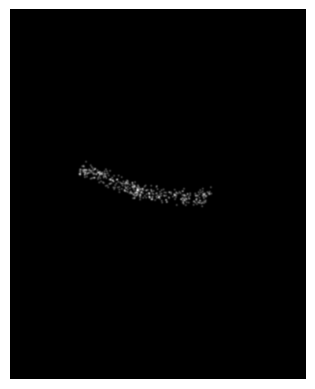

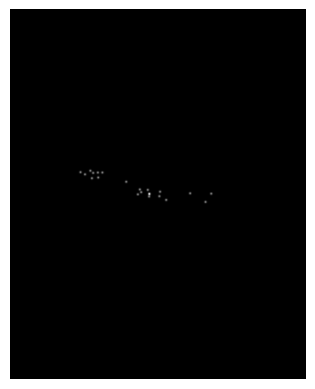

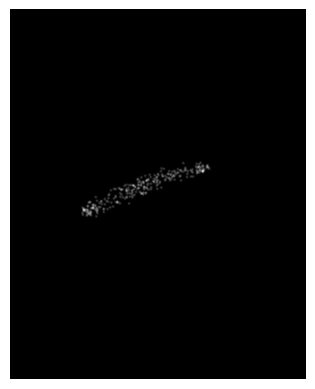

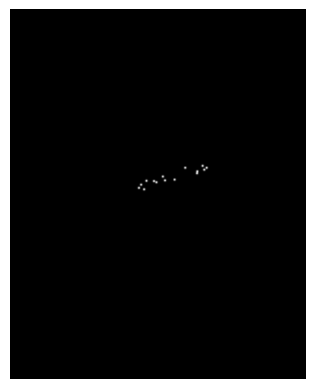

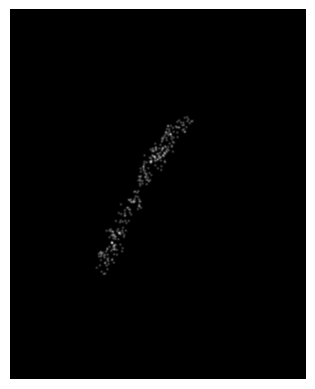

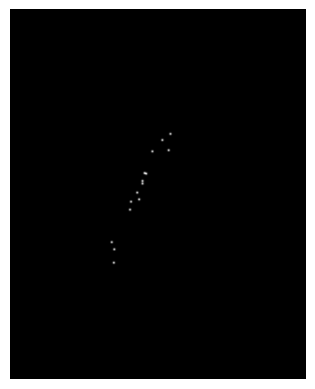

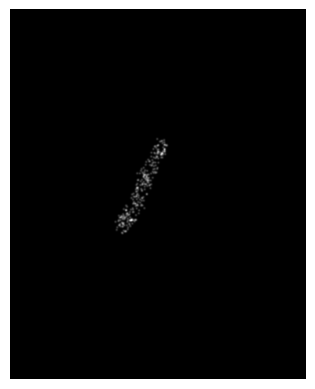

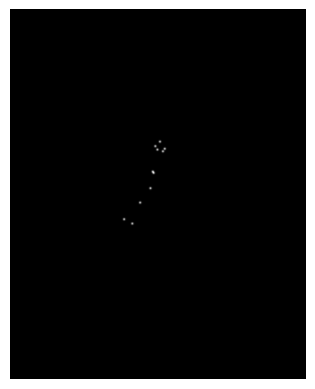

In [13]:
## Test

# Directories for input and output
input_directory = "/home/deev/t-simcne/CAP-CNN/test_flic_flix_3"  # Directory containing the cell CSV files
output_rasterized_directory = "test_flic_flix_3_images"  # Directory to save rasterized images
os.makedirs(output_rasterized_directory, exist_ok=True)

# Process all cells
process_all_cells(input_directory, output_rasterized_directory)

0 of 271
270 of 271
0 of 15
14 of 15
0 of 259
258 of 259
0 of 15
14 of 15
0 of 300
299 of 300
0 of 23
22 of 23
0 of 256
255 of 256
0 of 17
16 of 17
0 of 283
282 of 283
0 of 10
9 of 10
0 of 288
287 of 288
0 of 21
20 of 21
0 of 286
285 of 286
0 of 16
15 of 16
0 of 269
268 of 269
0 of 21
20 of 21
0 of 282
281 of 282
0 of 15
14 of 15
0 of 495
494 of 495
0 of 16
15 of 16


/tmp/ipykernel_1694672/1244452474.py:103: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  if draw: fig,ax = plt.subplots()


0 of 292
291 of 292
0 of 20
19 of 20
0 of 291
290 of 291
0 of 17
16 of 17
0 of 276
275 of 276
0 of 27
26 of 27
0 of 504
503 of 504
0 of 33
32 of 33
0 of 321
320 of 321
0 of 20
19 of 20
0 of 259
258 of 259
0 of 19
18 of 19
0 of 261
260 of 261
0 of 20
19 of 20
0 of 257
256 of 257
0 of 20
19 of 20
0 of 295
294 of 295
0 of 18
17 of 18
0 of 338
337 of 338
0 of 28
27 of 28
0 of 263
262 of 263
0 of 17
16 of 17
0 of 263
262 of 263
0 of 16
15 of 16
0 of 314
313 of 314
0 of 19
18 of 19
0 of 298
297 of 298
0 of 13
12 of 13
0 of 280
279 of 280
0 of 20
19 of 20
0 of 295
294 of 295
0 of 8
7 of 8
0 of 329
328 of 329
0 of 24
23 of 24
0 of 310
309 of 310
0 of 27
26 of 27
0 of 338
337 of 338
0 of 14
13 of 14
0 of 379
378 of 379
0 of 37
36 of 37
0 of 292
291 of 292
0 of 10
9 of 10
0 of 277
276 of 277
0 of 20
19 of 20
0 of 282
281 of 282
0 of 8
7 of 8
0 of 365
364 of 365
0 of 32
31 of 32
0 of 266
265 of 266
0 of 19
18 of 19
0 of 253
252 of 253
0 of 15
14 of 15
0 of 329
328 of 329
0 of 10
9 of 10
0 of 258


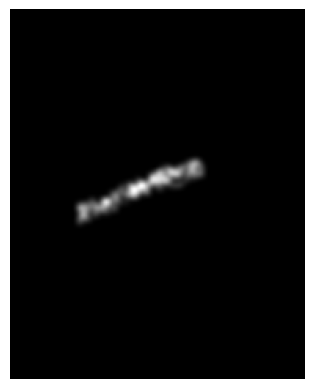

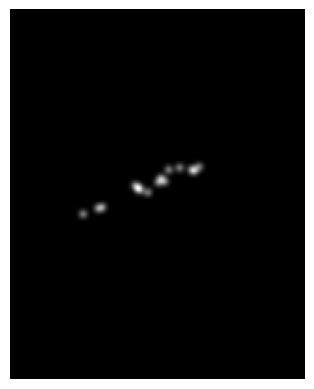

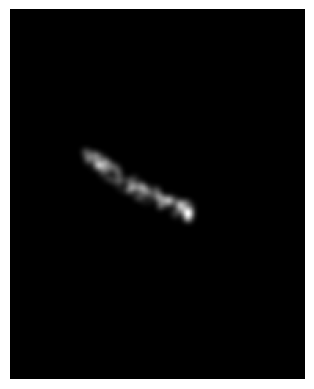

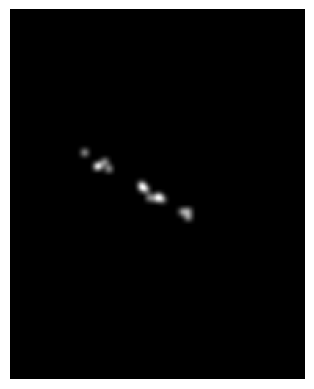

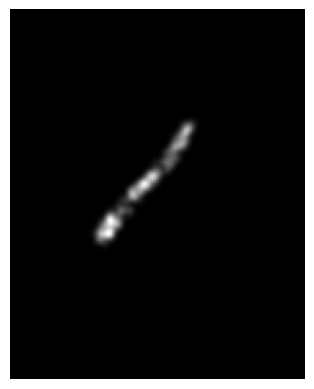

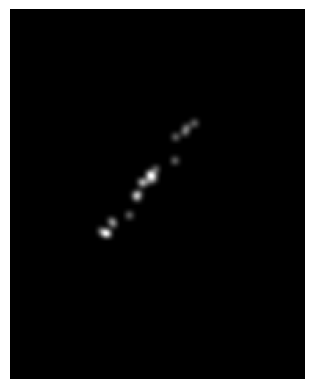

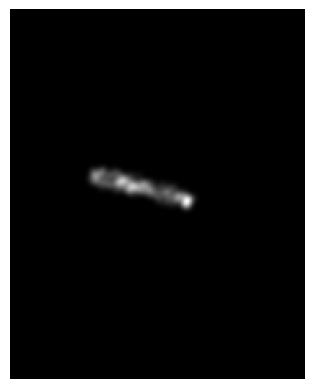

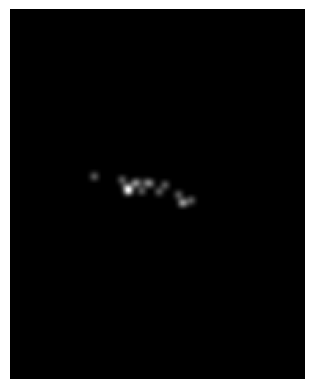

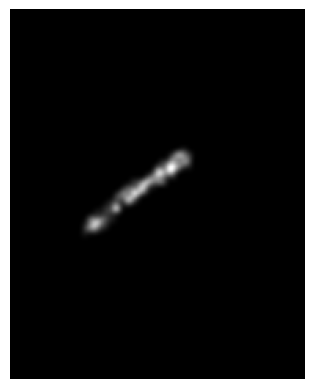

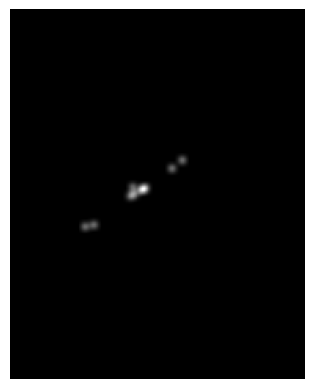

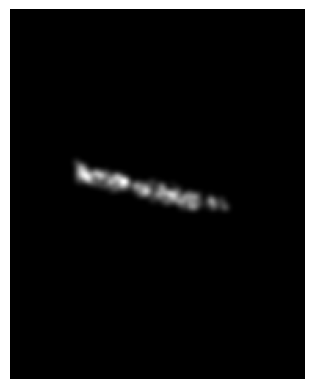

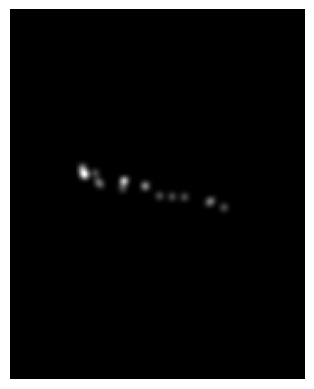

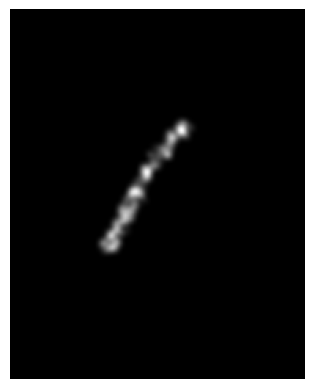

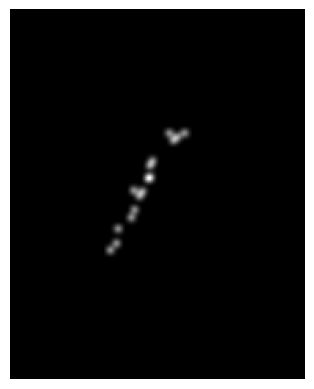

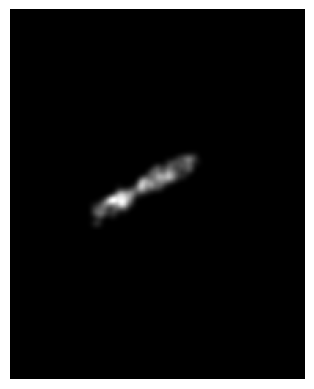

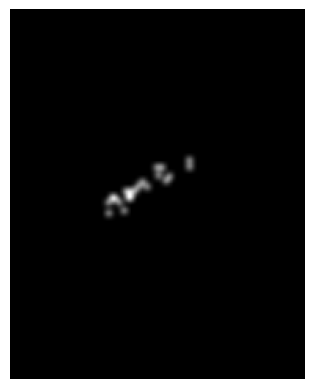

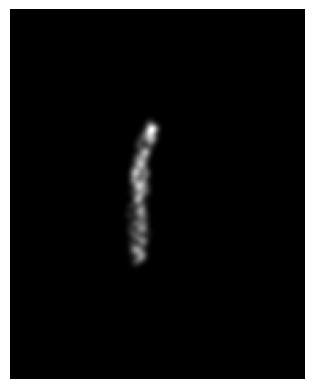

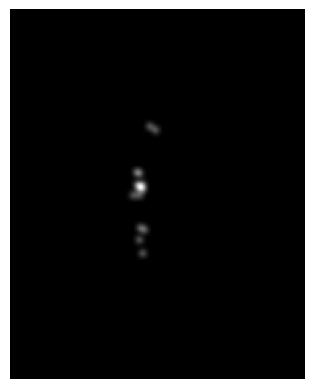

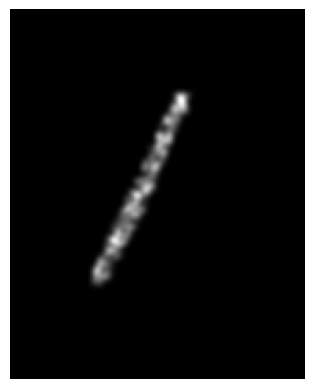

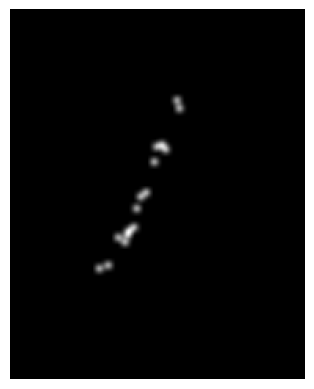

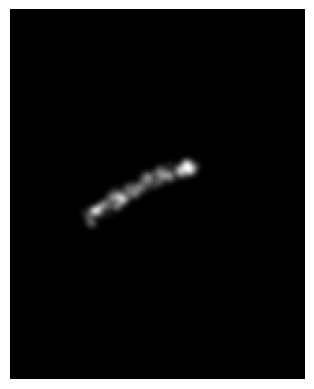

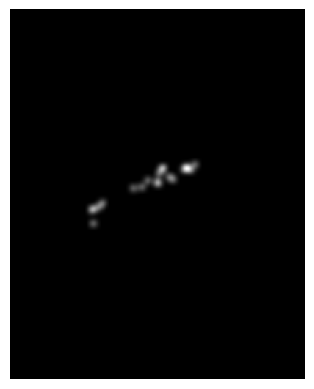

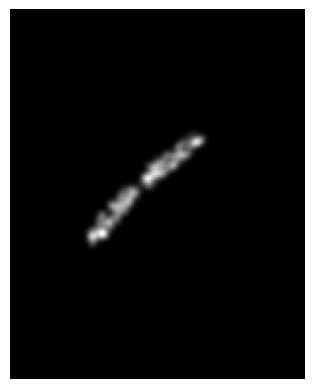

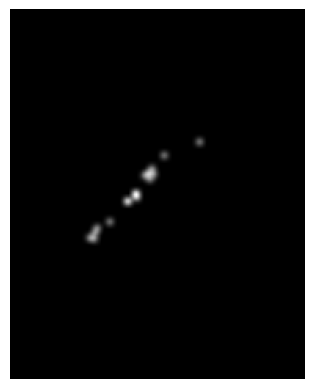

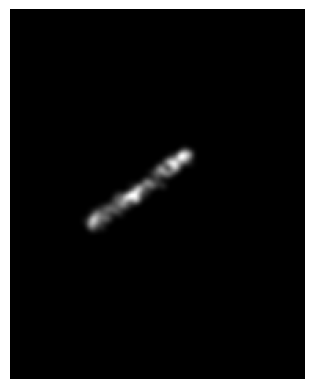

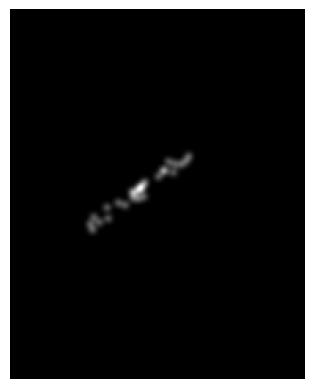

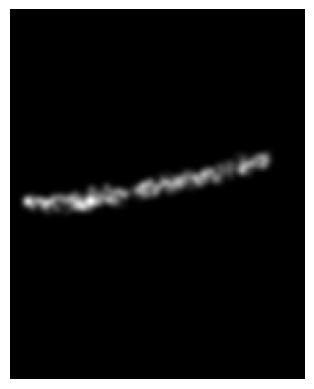

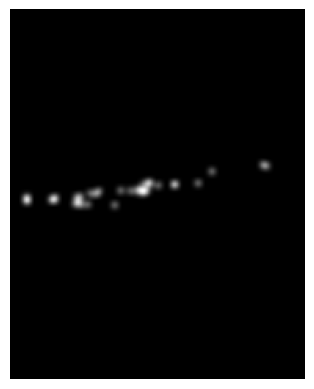

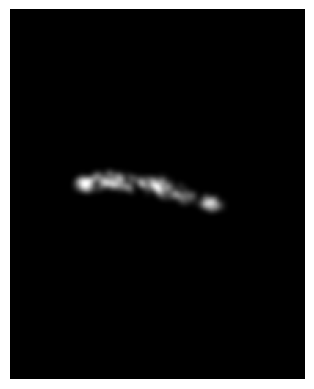

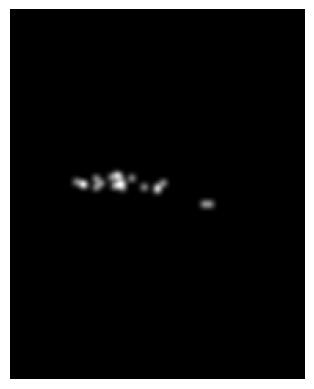

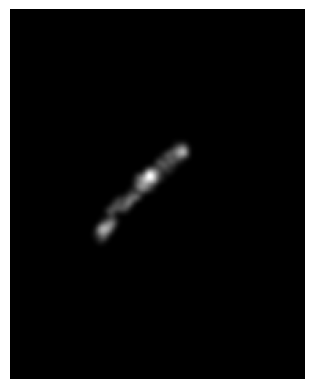

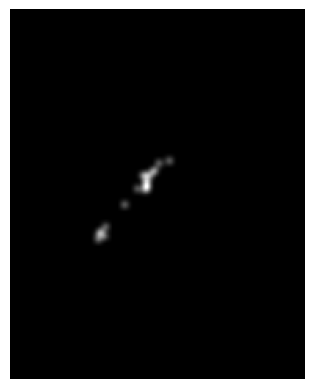

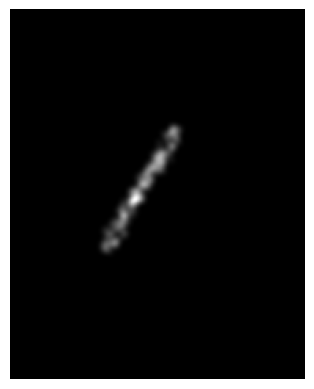

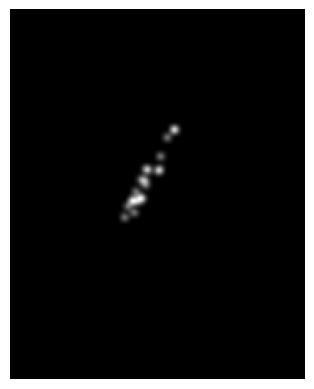

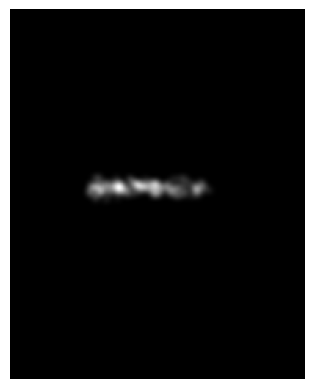

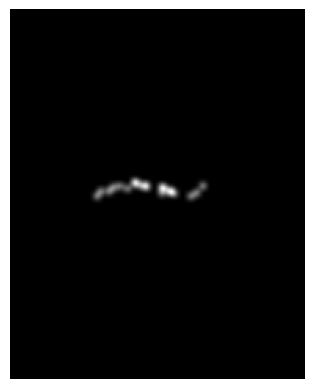

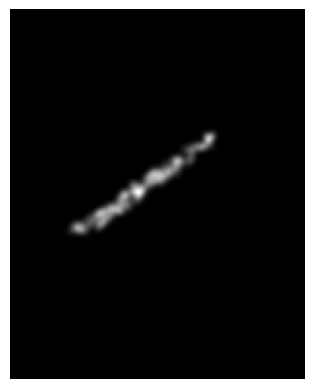

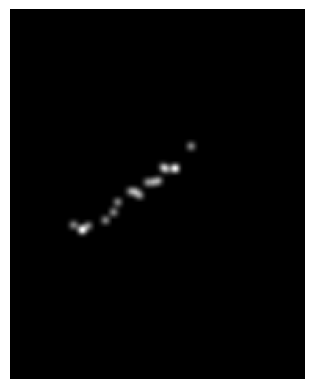

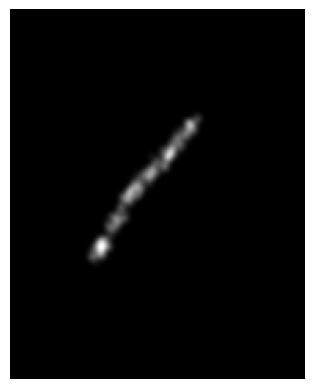

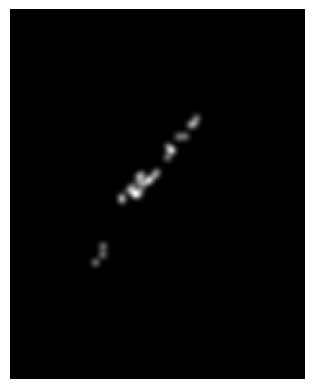

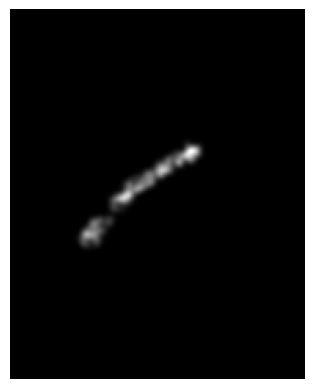

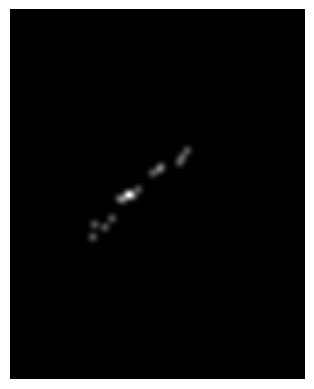

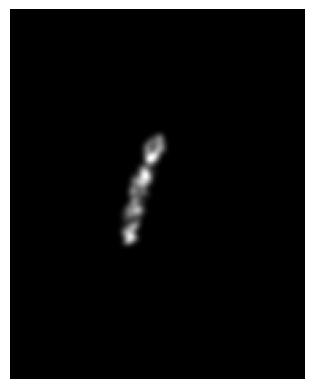

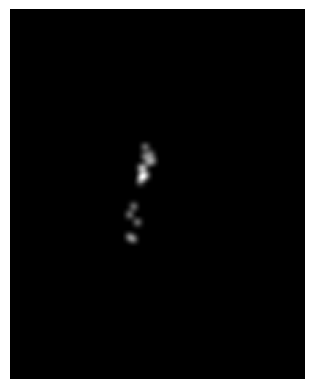

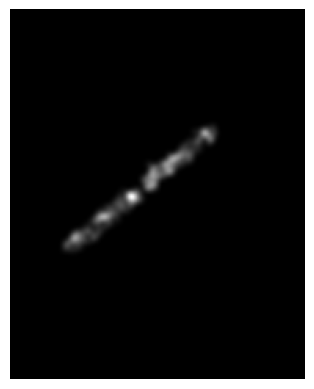

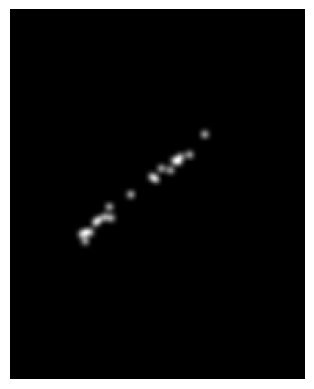

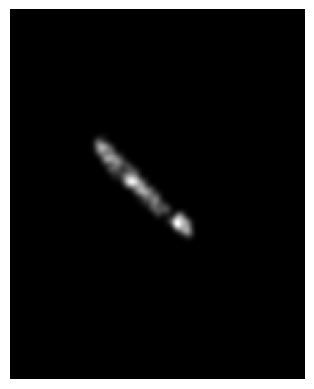

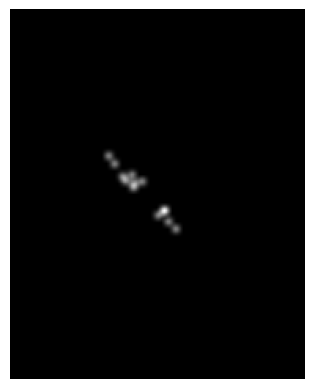

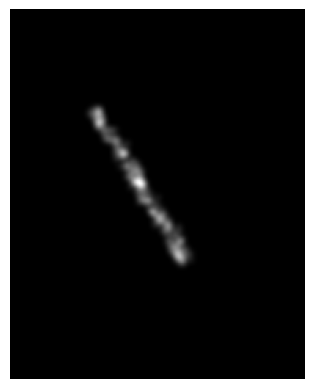

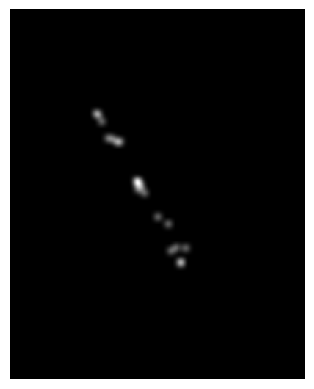

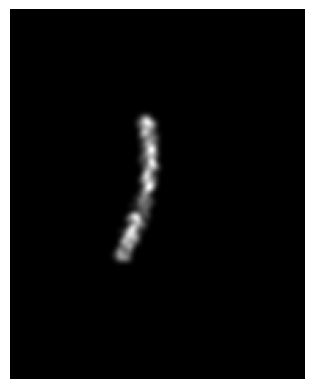

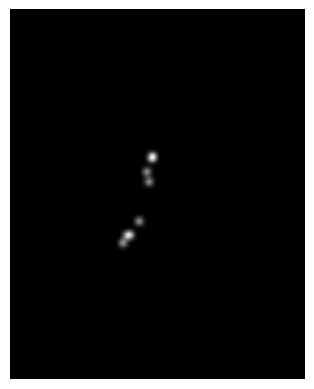

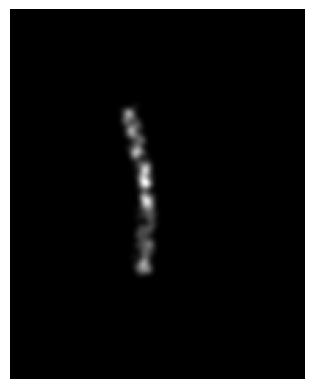

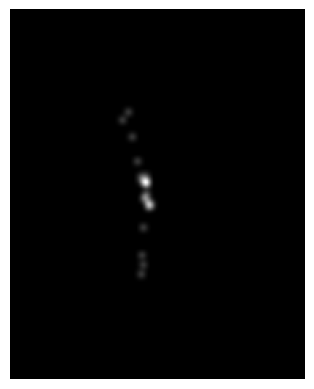

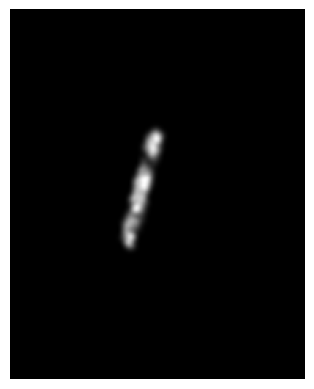

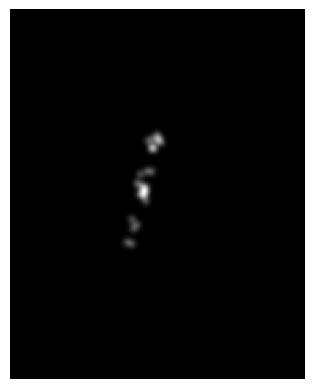

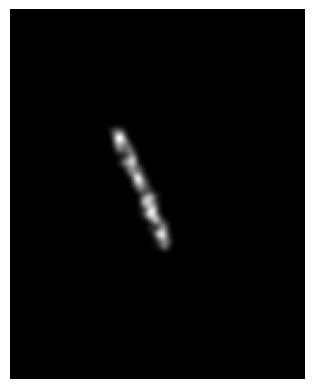

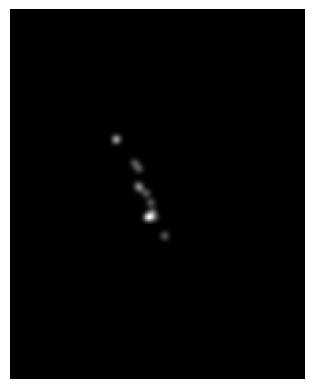

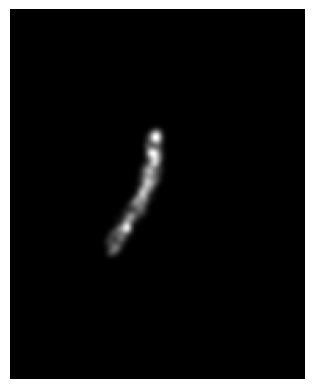

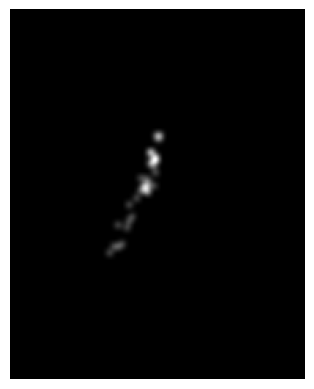

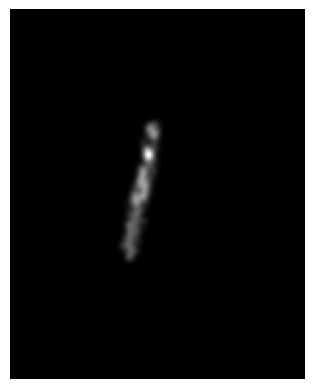

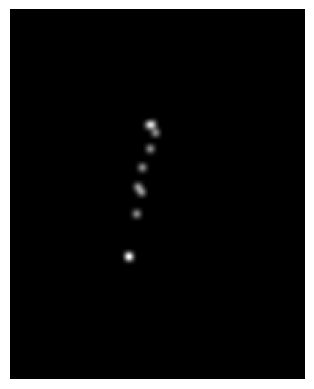

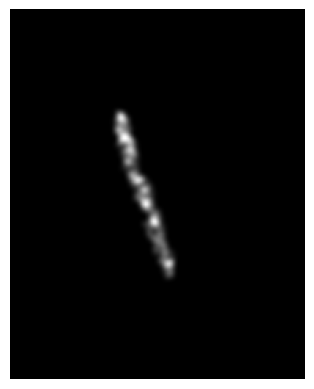

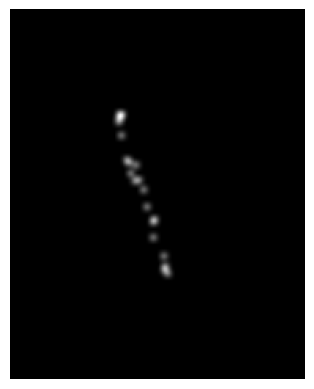

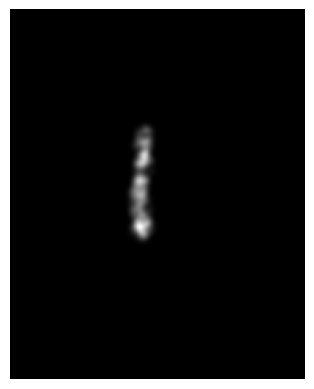

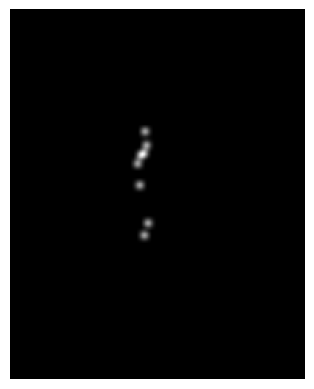

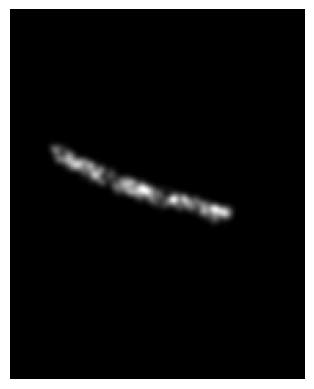

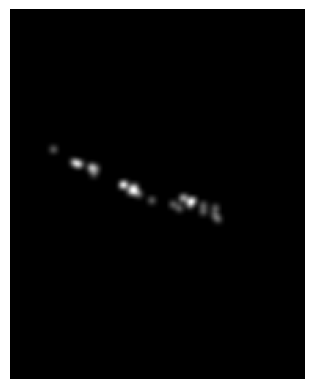

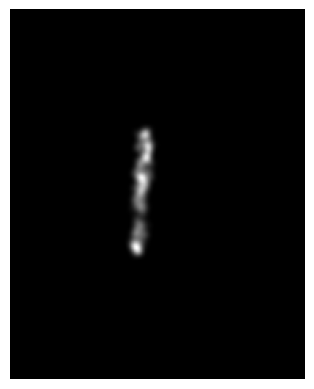

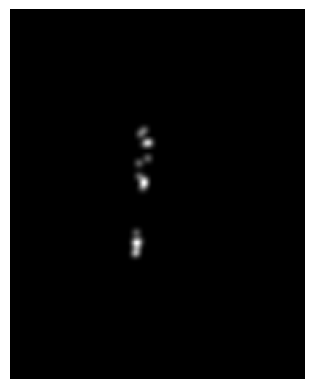

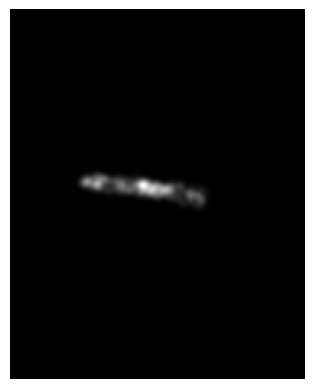

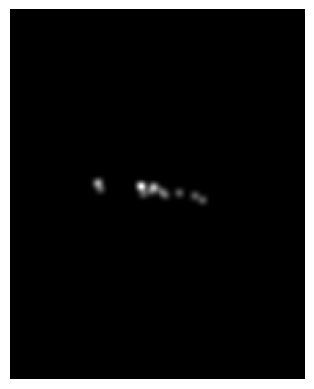

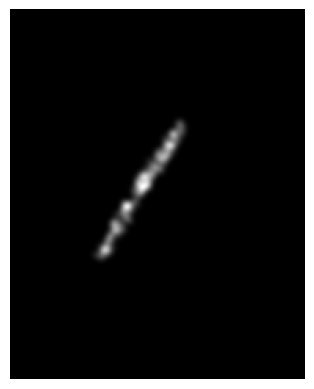

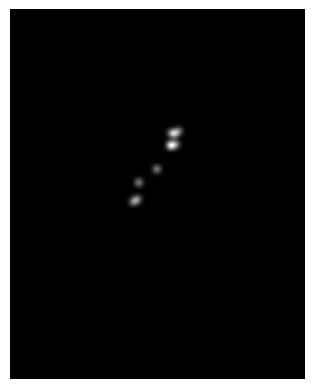

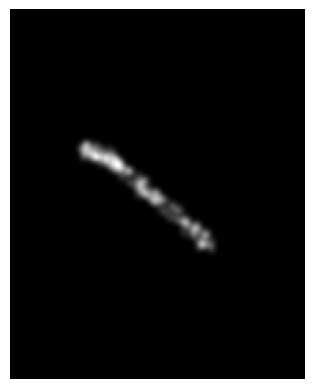

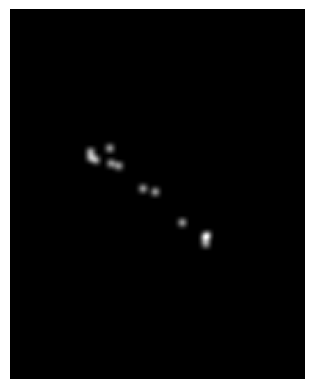

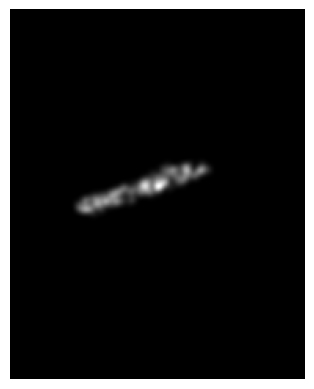

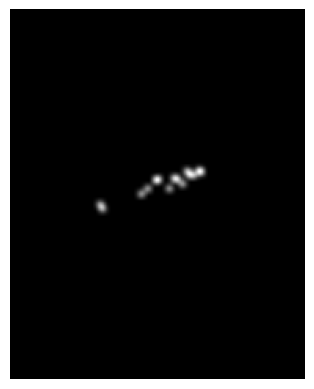

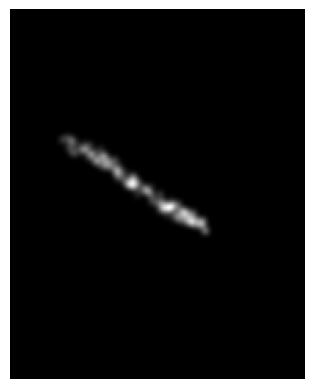

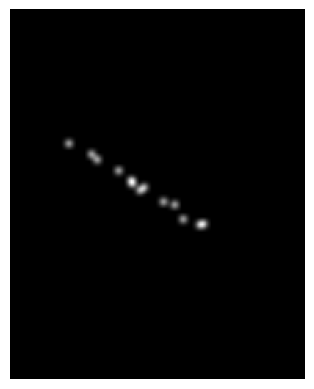

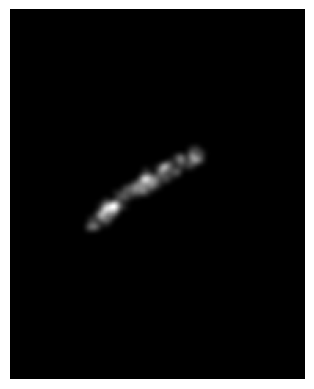

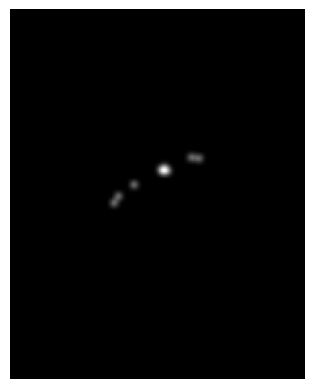

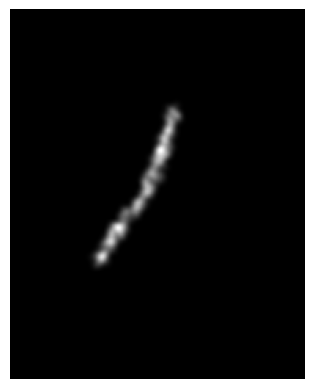

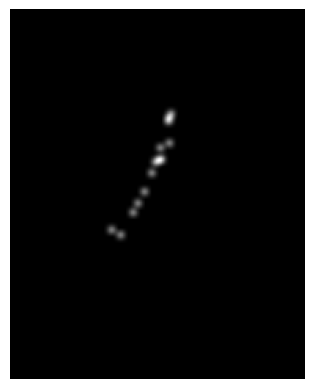

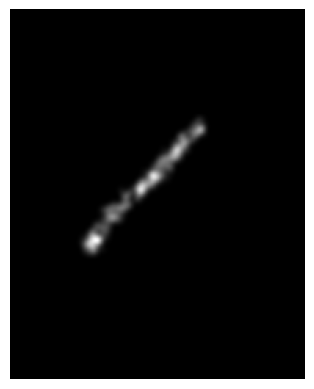

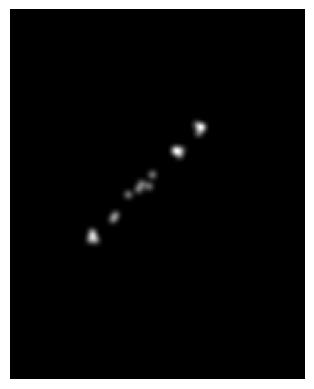

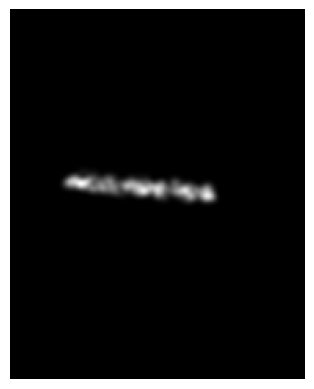

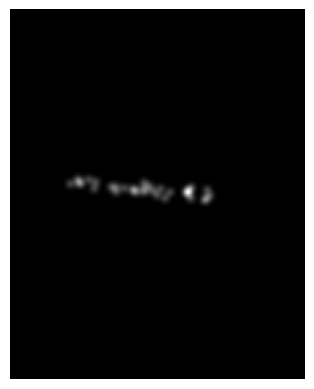

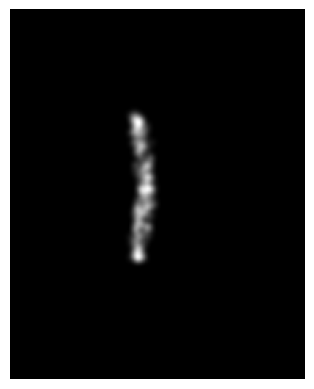

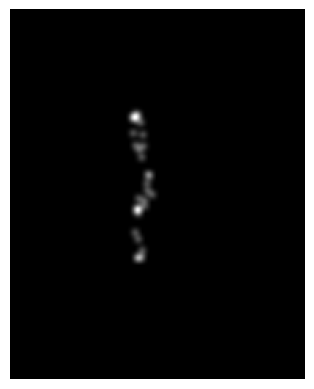

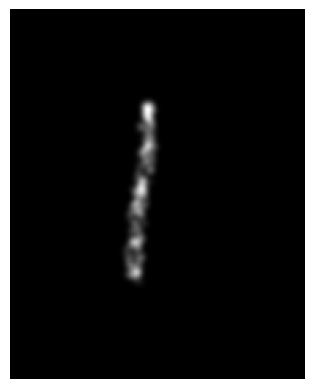

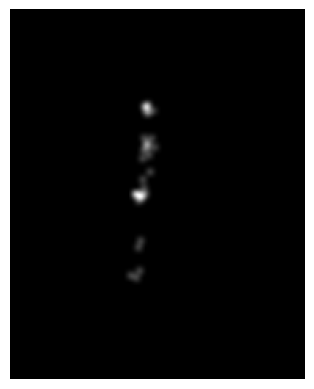

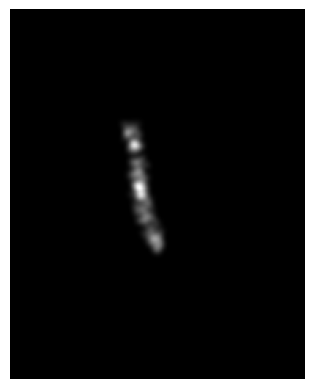

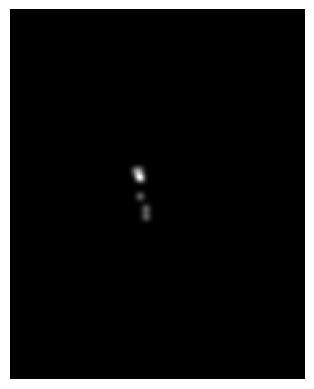

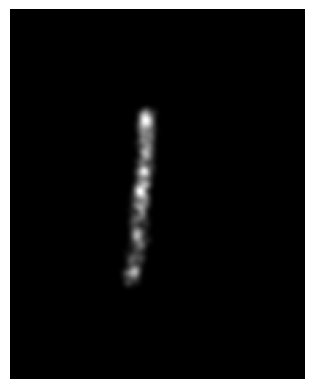

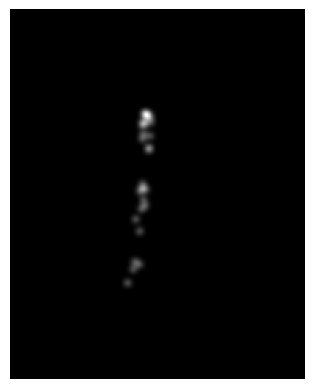

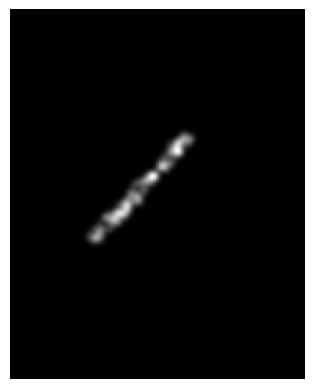

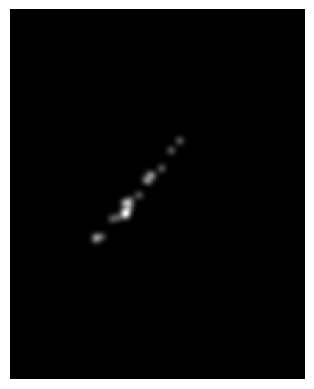

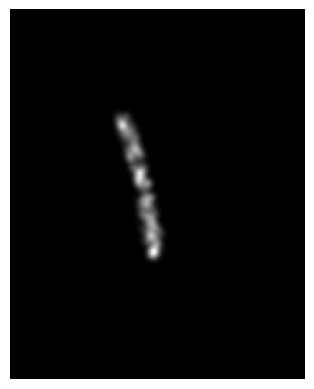

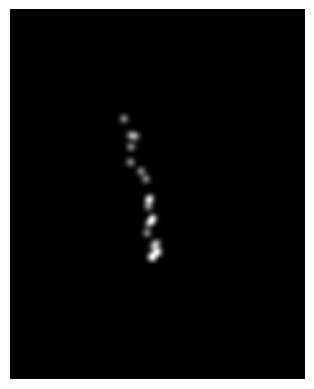

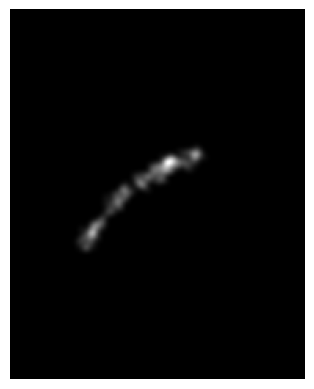

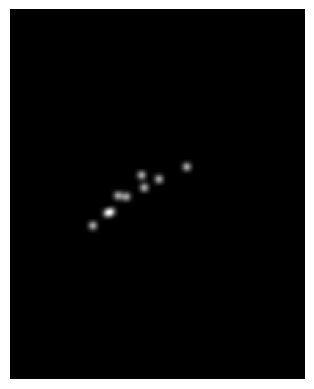

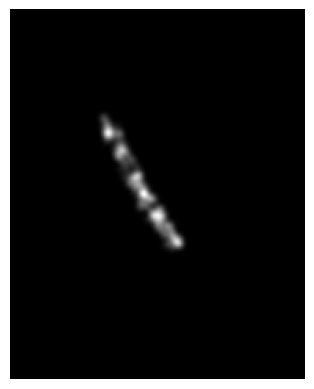

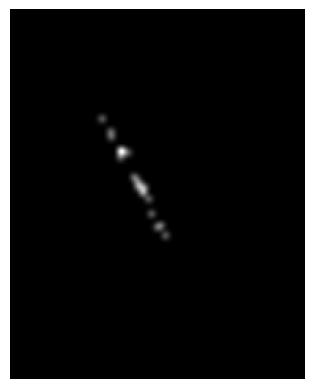

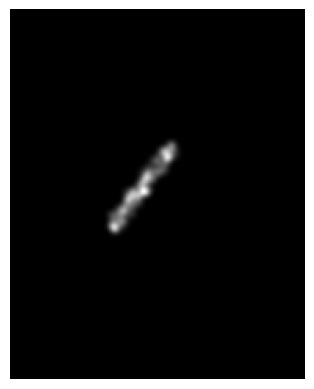

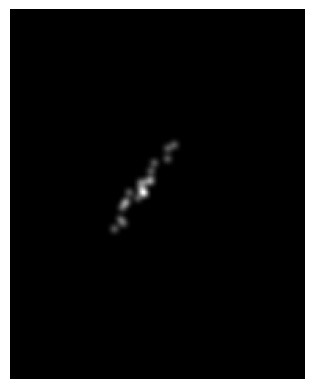

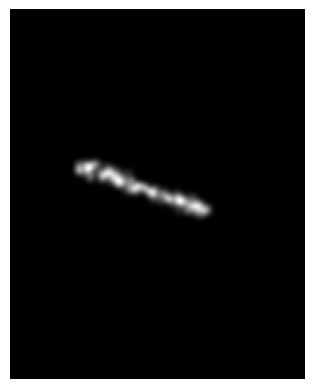

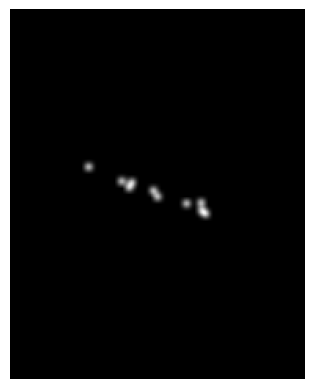

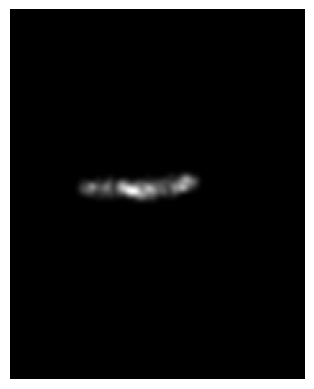

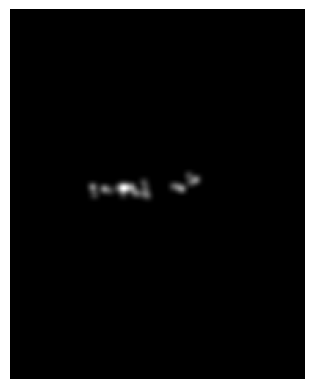

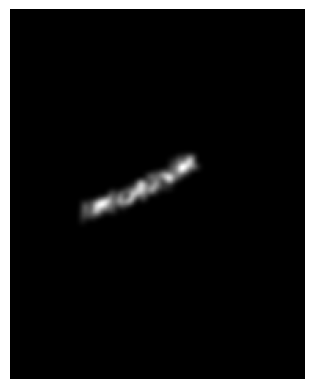

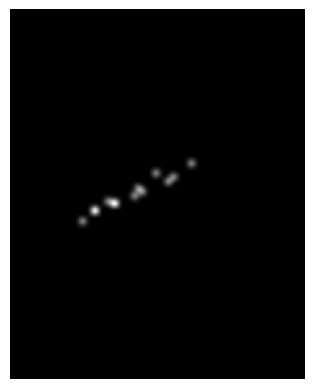

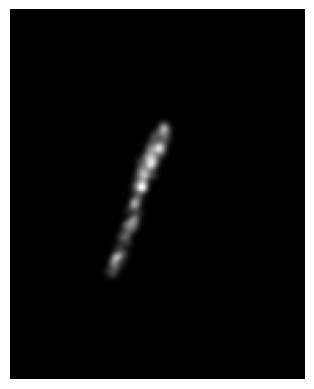

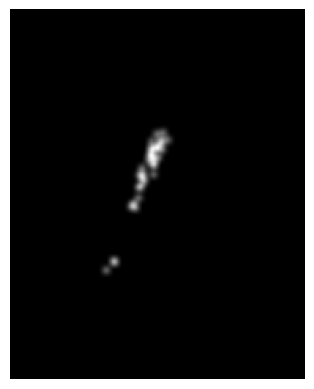

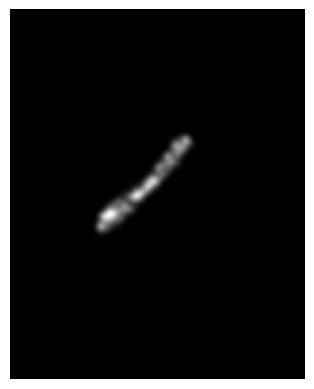

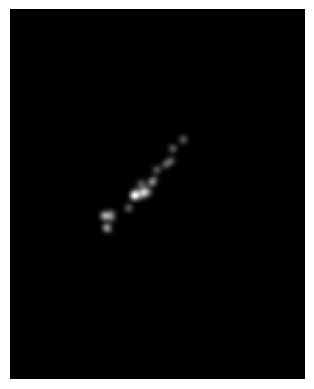

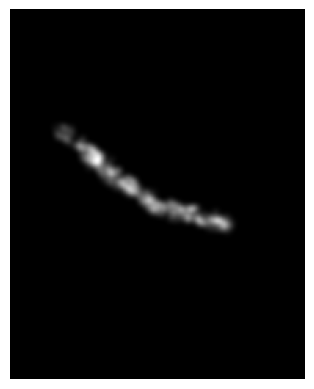

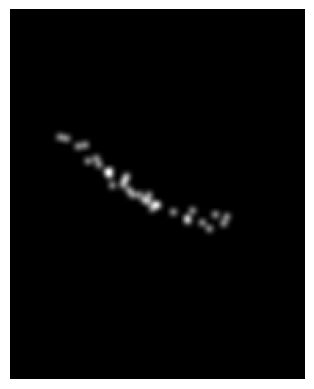

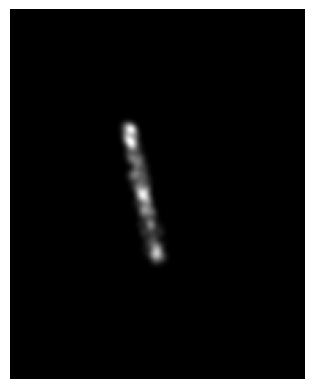

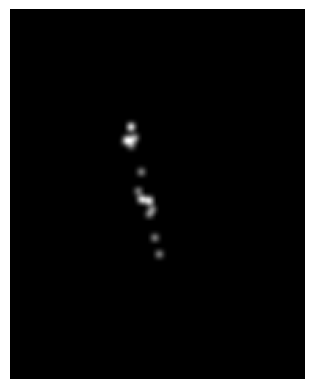

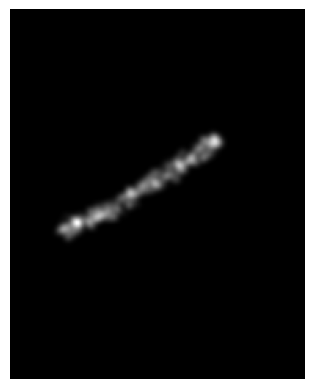

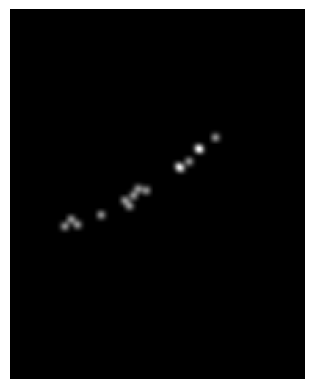

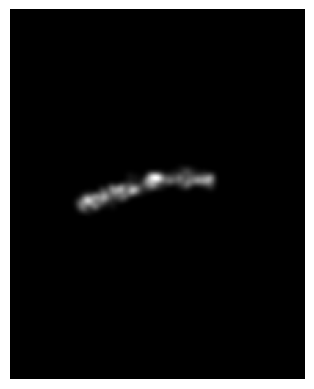

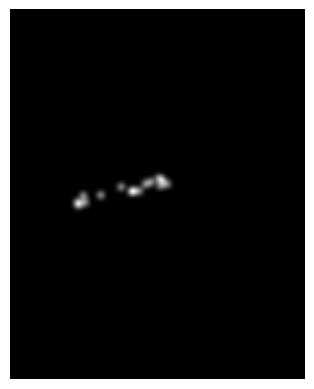

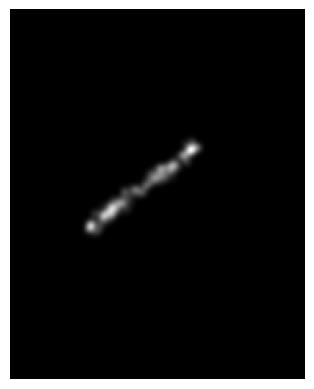

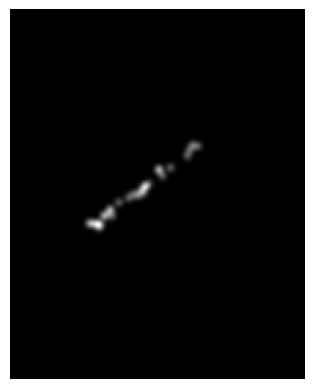

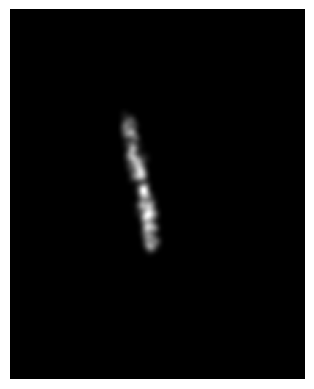

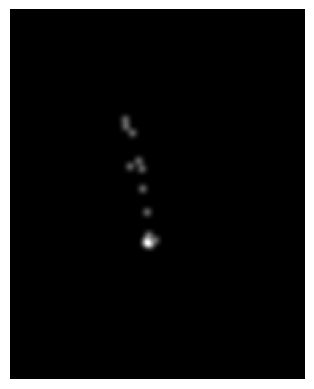

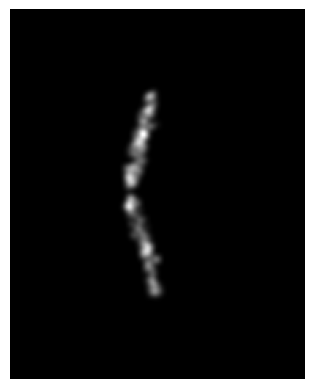

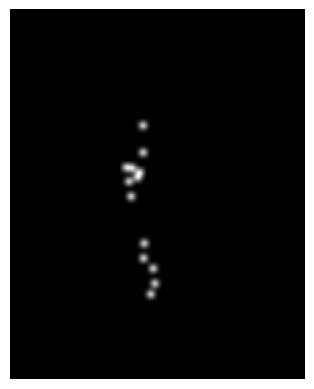

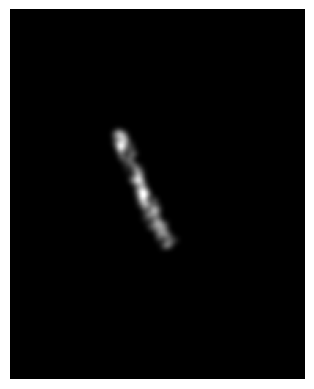

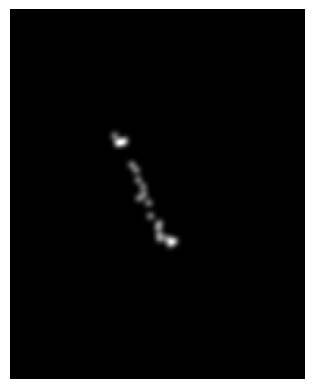

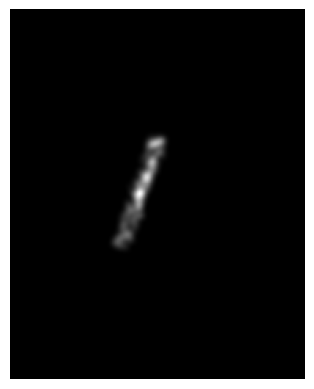

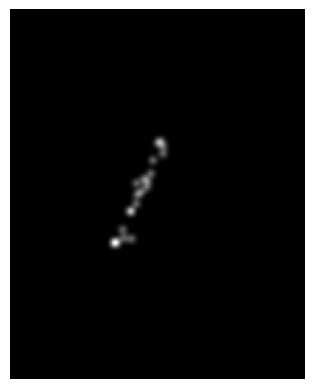

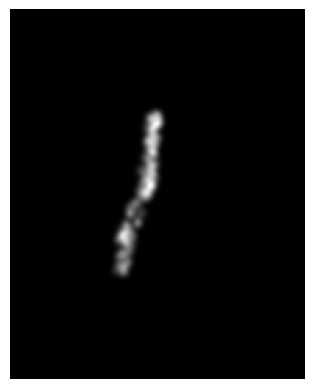

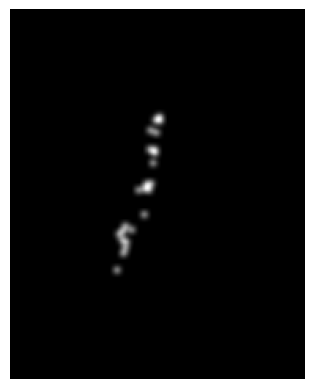

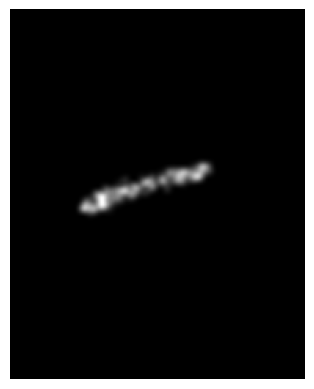

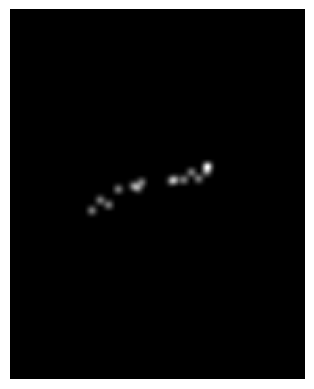

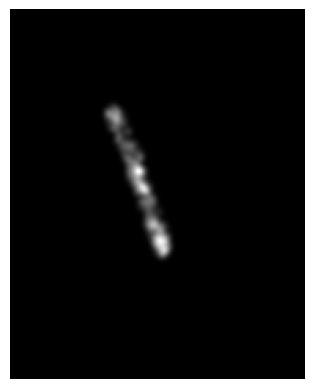

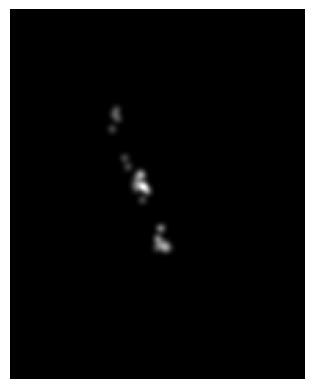

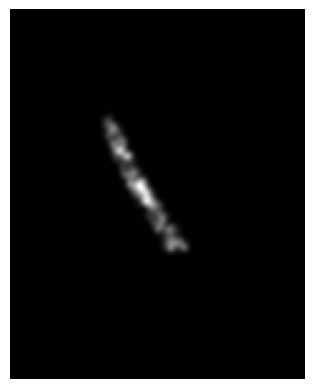

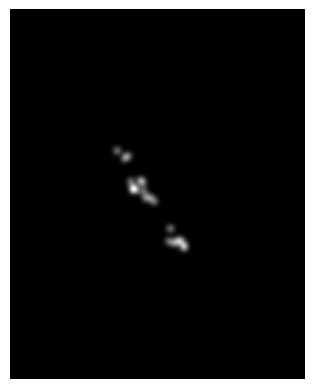

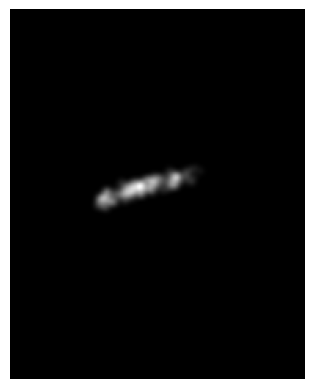

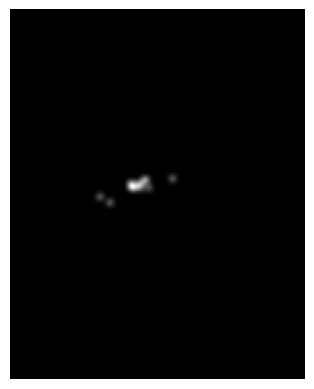

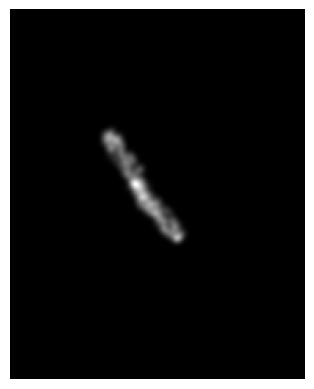

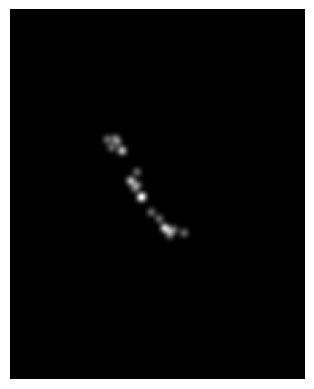

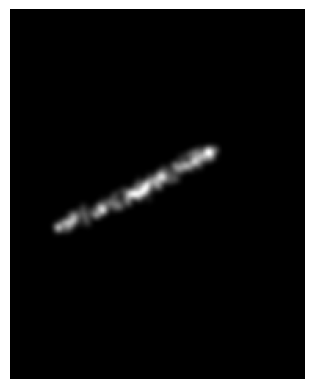

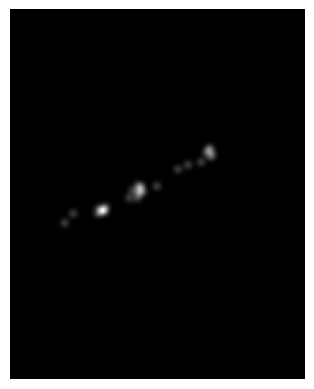

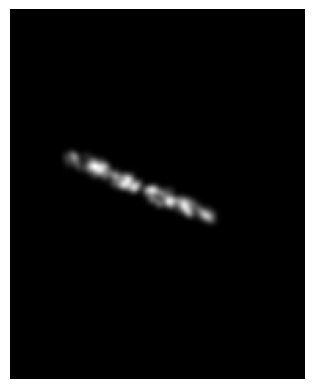

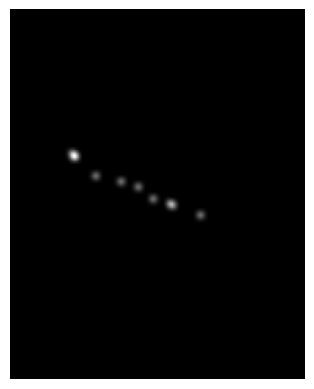

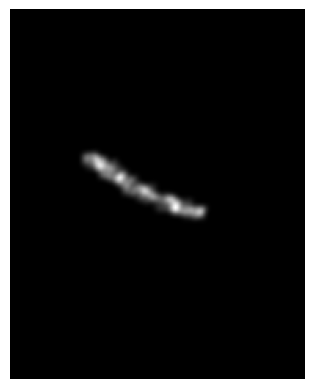

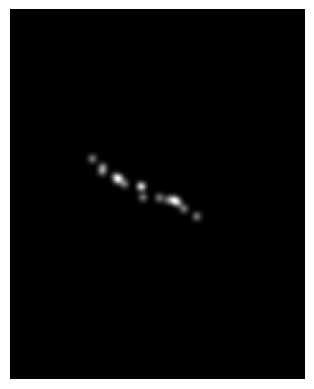

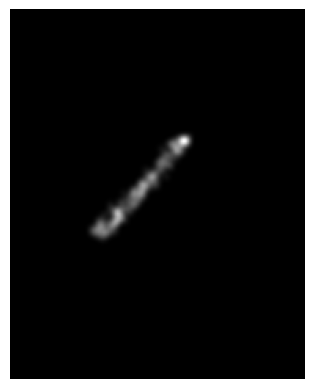

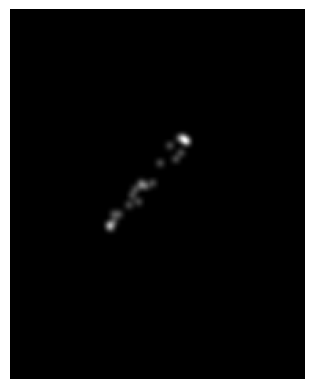

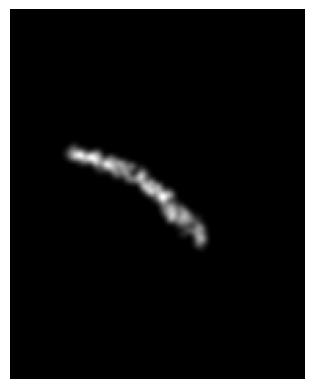

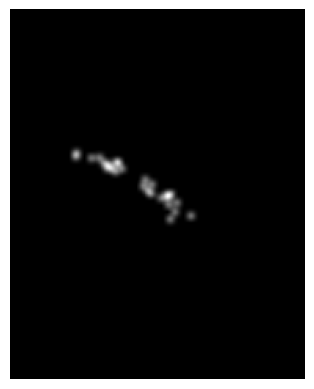

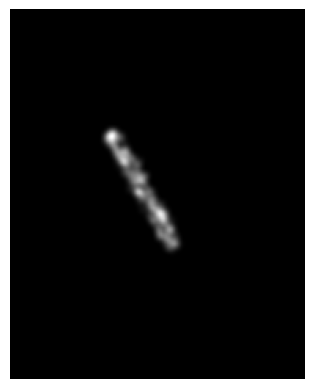

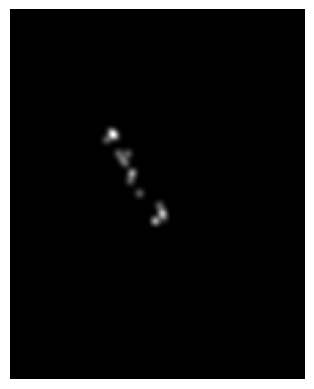

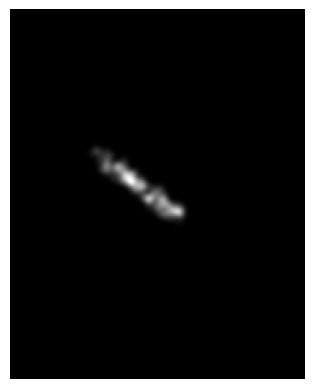

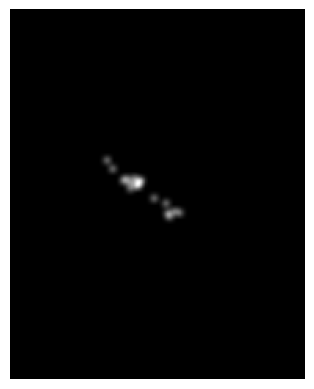

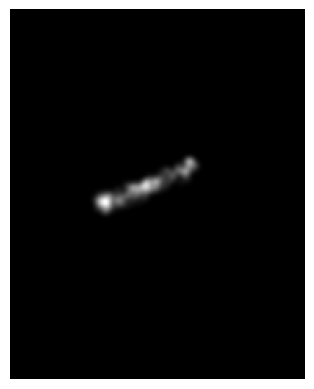

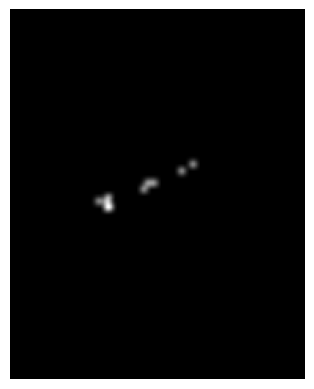

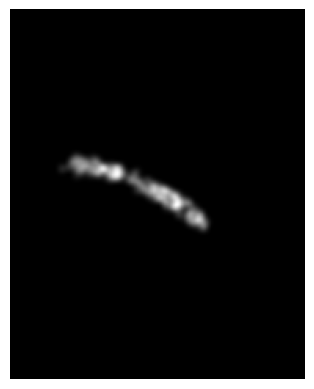

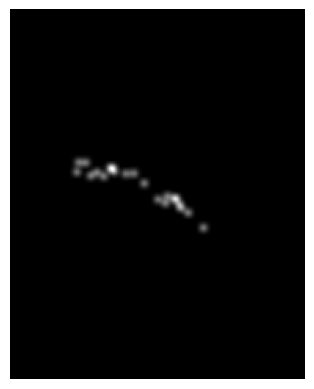

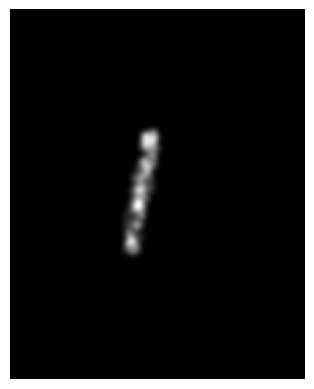

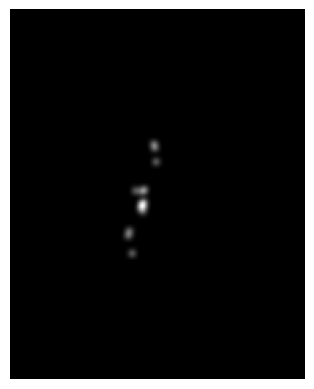

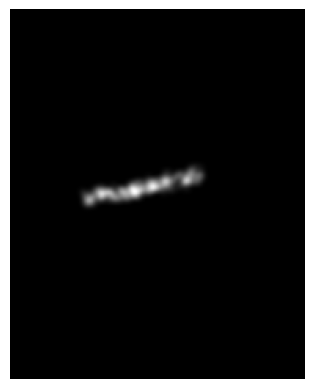

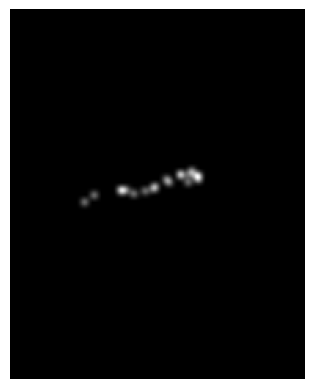

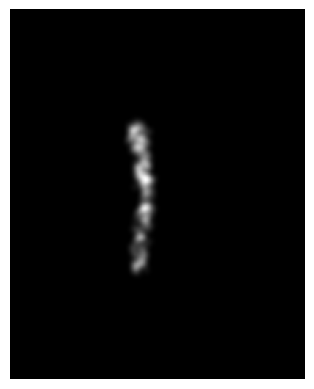

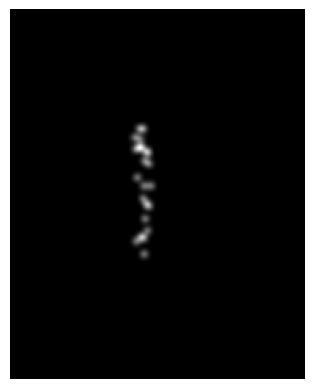

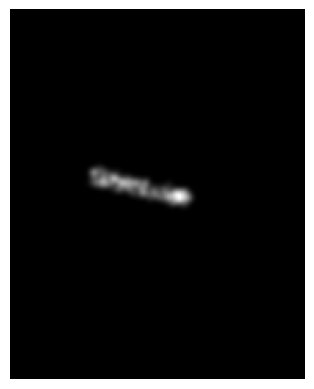

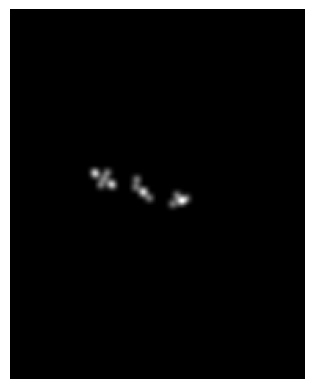

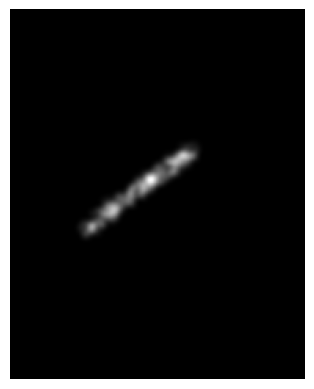

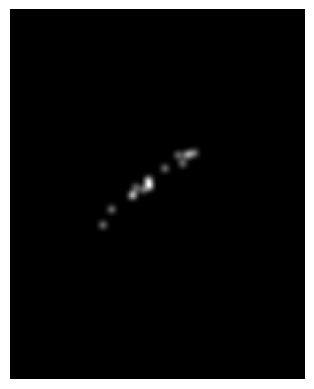

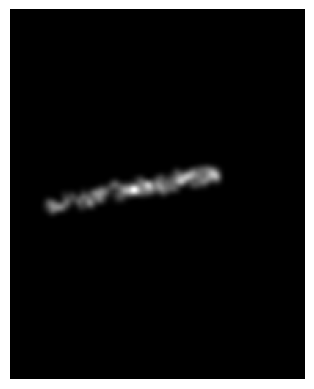

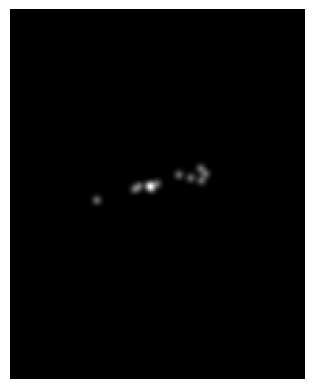

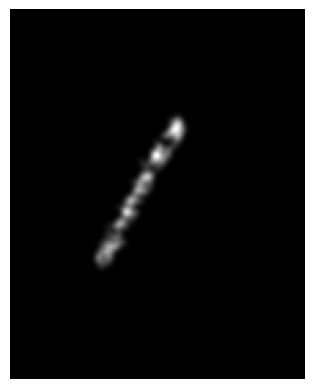

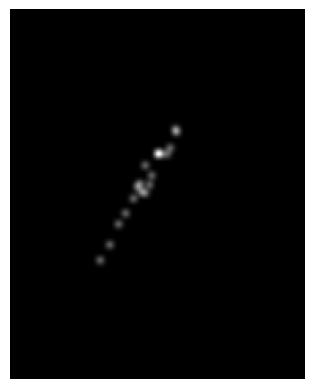

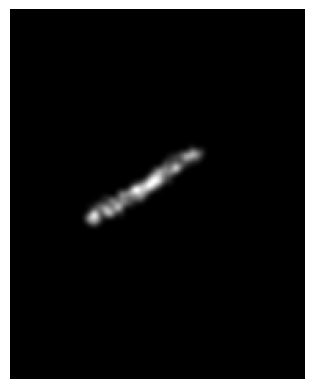

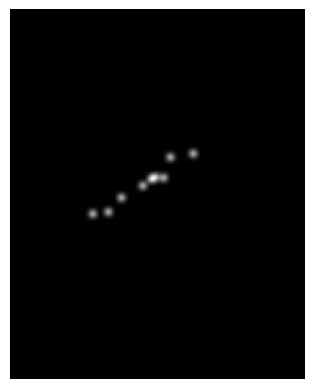

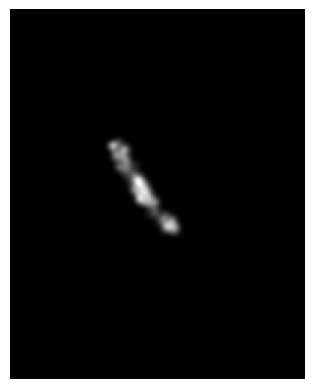

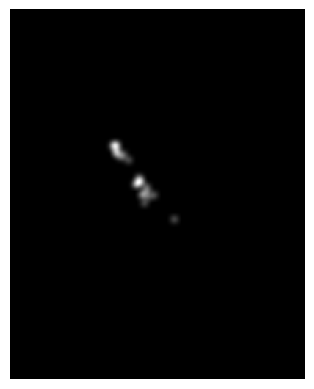

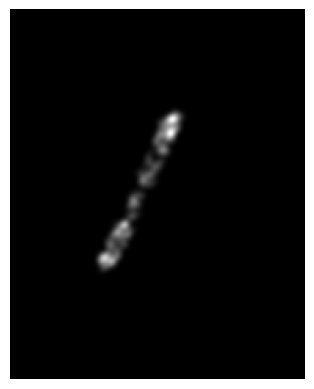

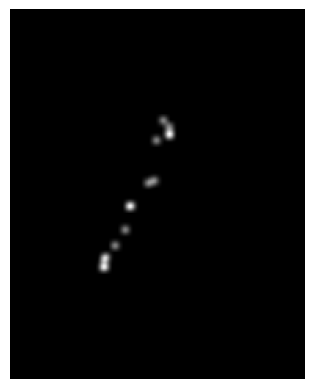

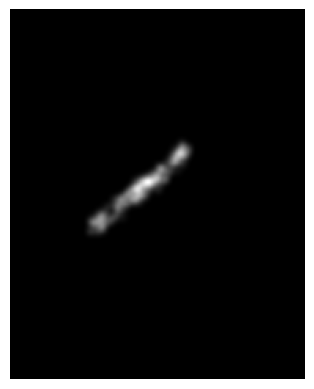

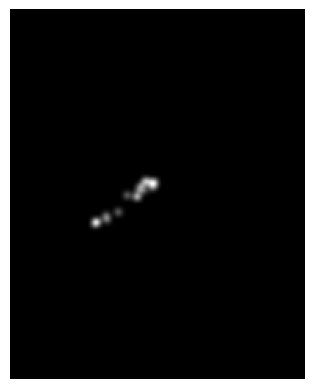

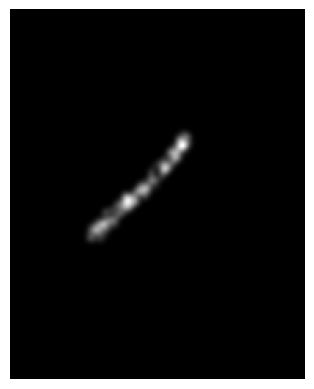

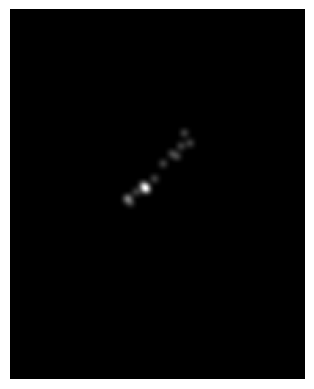

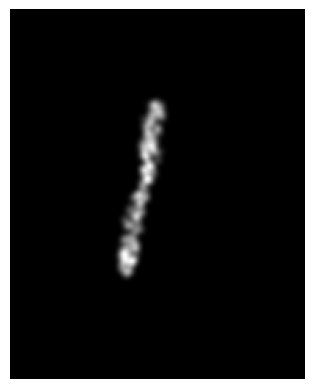

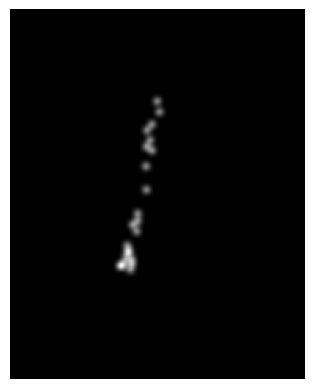

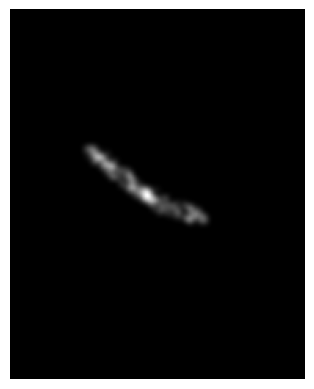

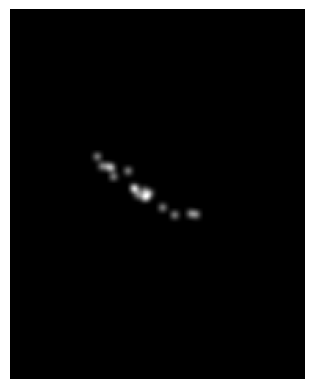

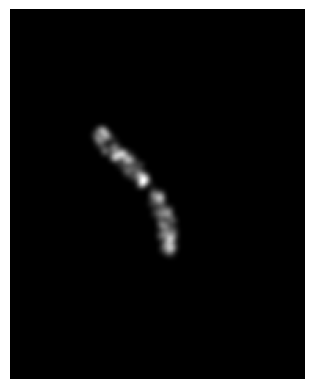

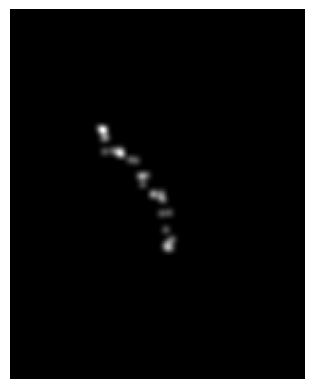

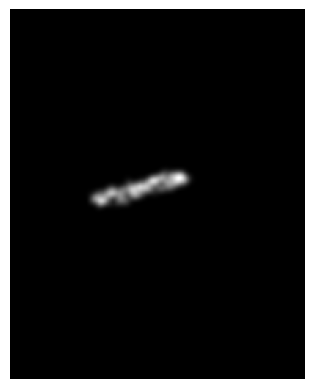

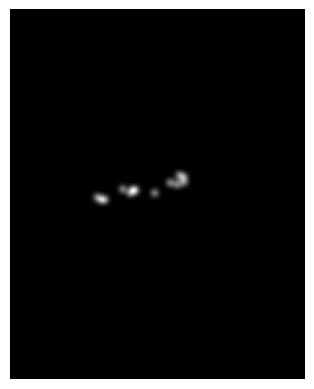

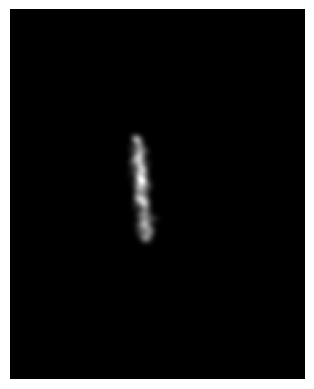

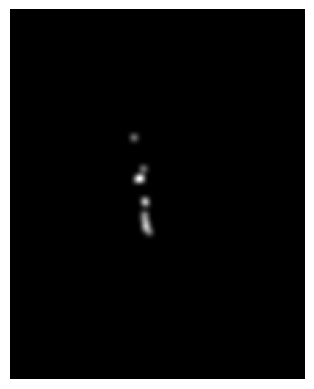

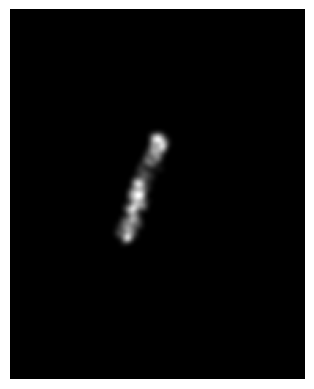

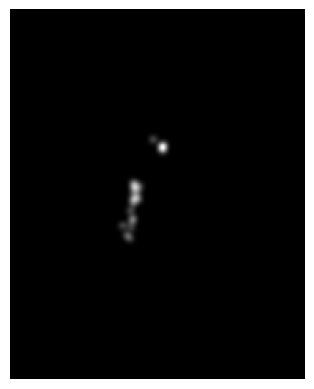

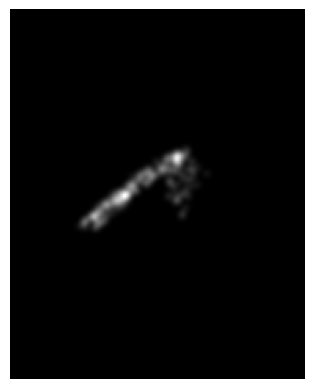

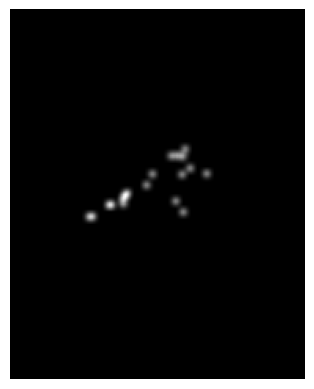

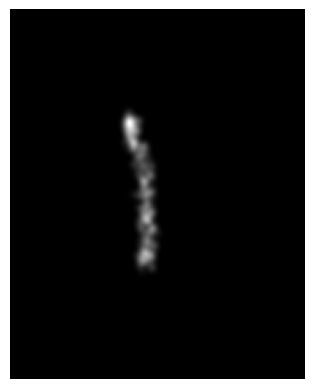

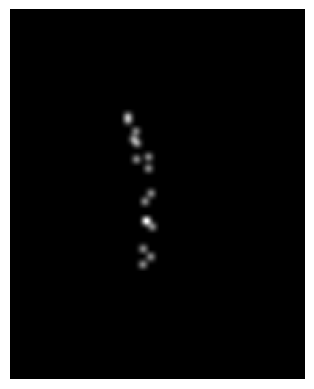

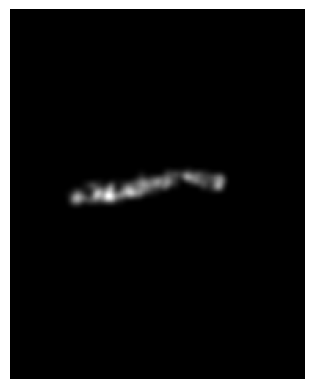

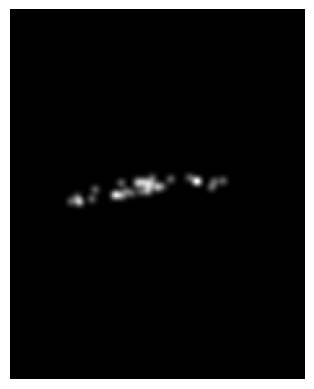

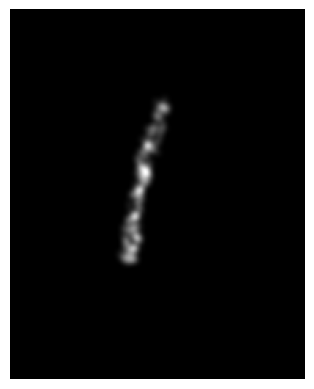

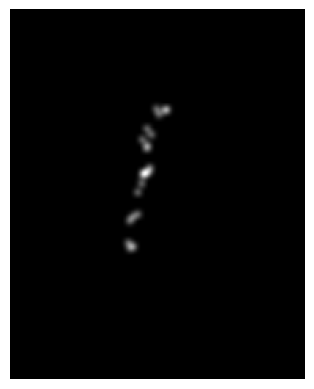

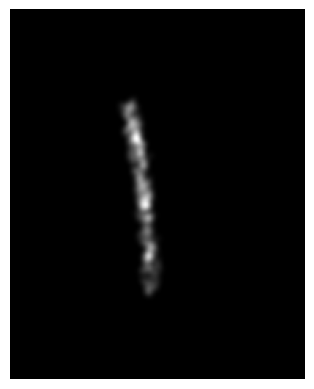

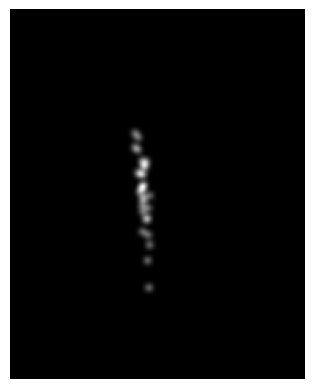

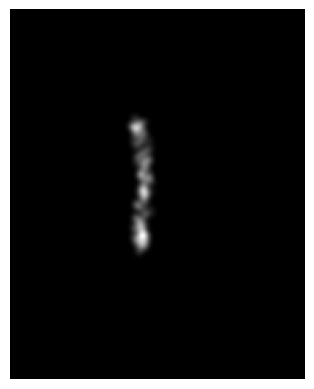

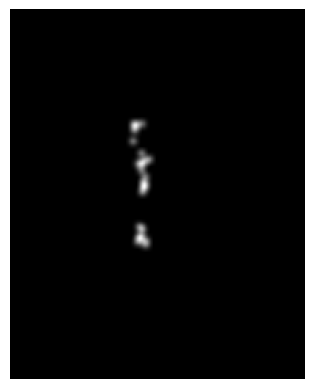

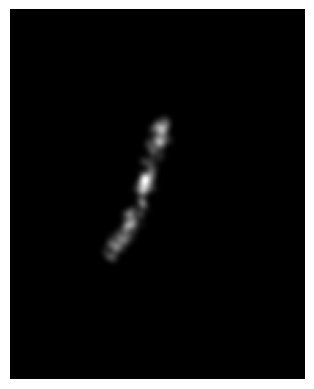

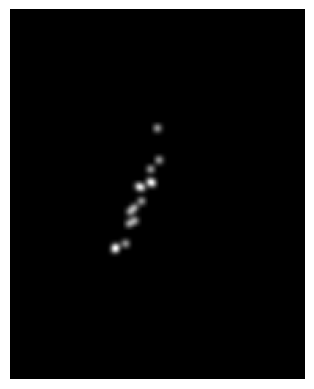

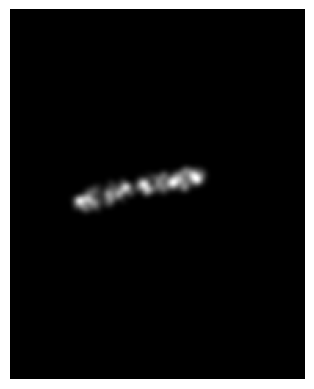

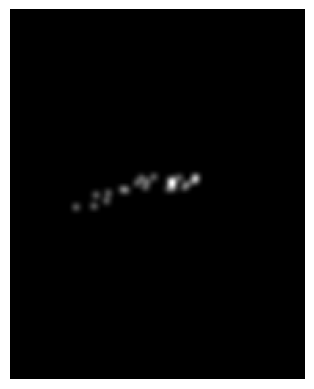

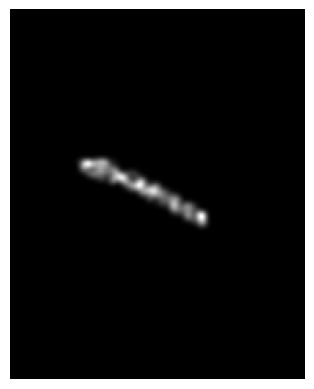

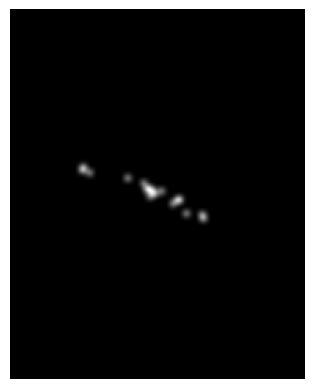

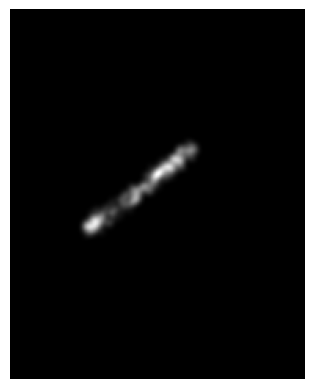

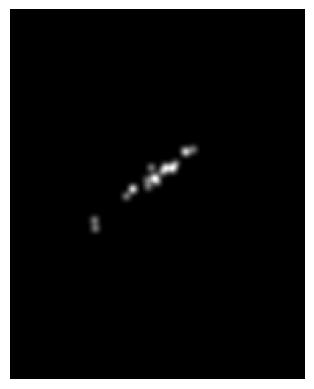

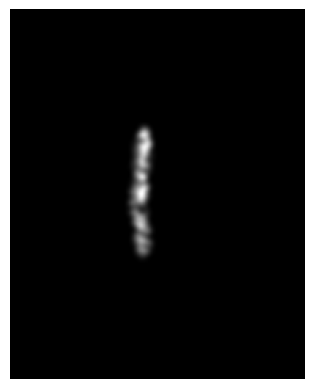

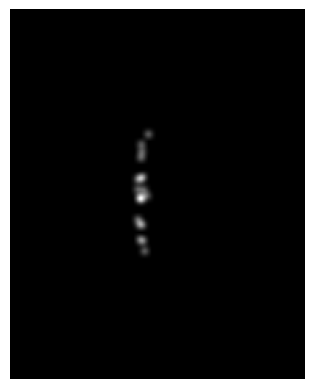

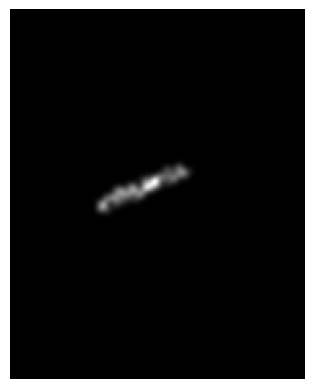

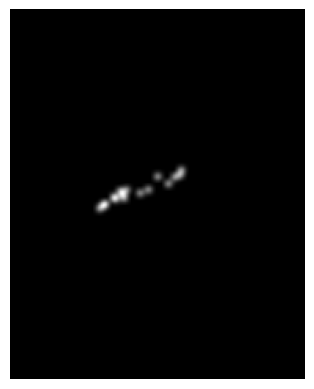

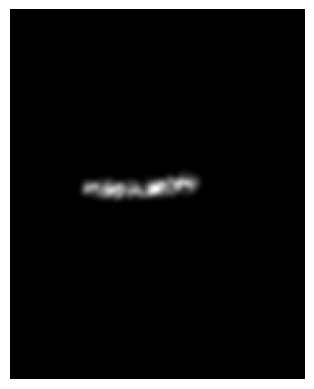

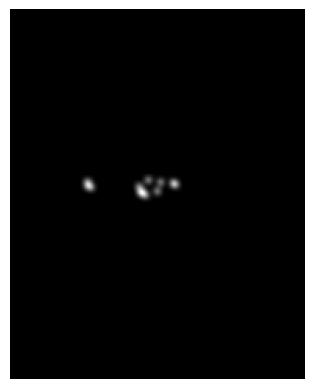

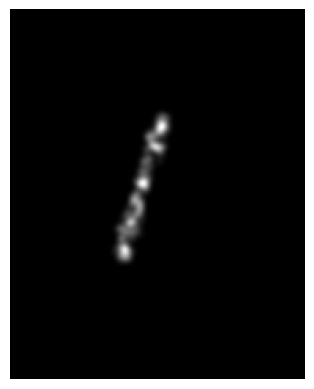

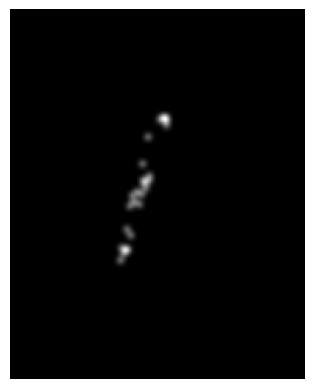

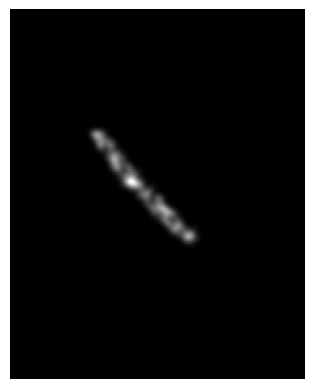

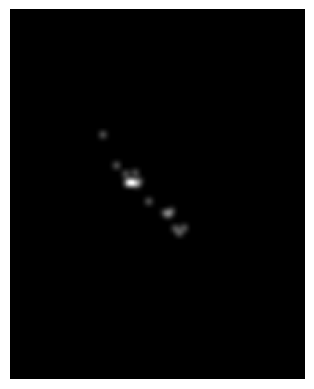

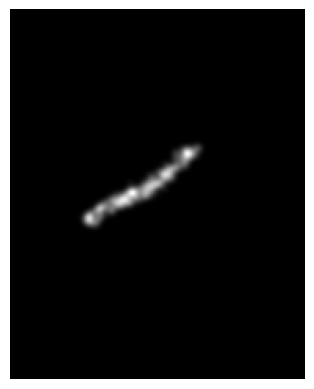

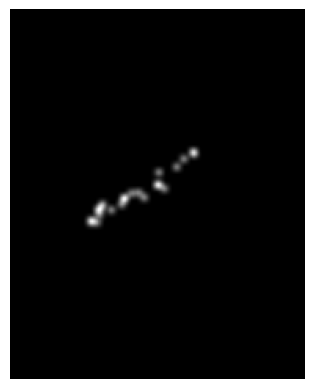

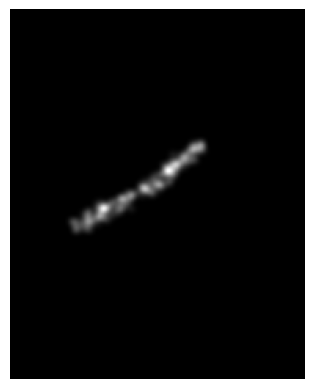

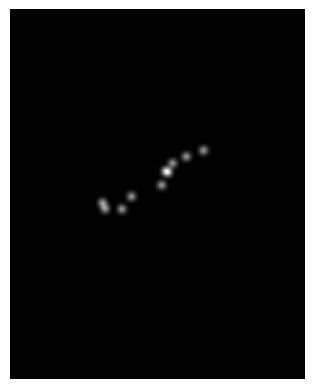

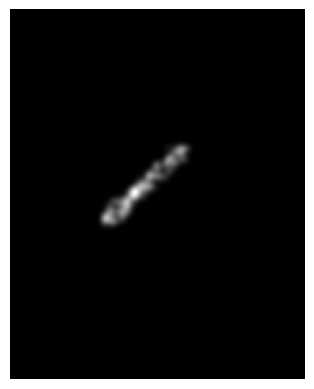

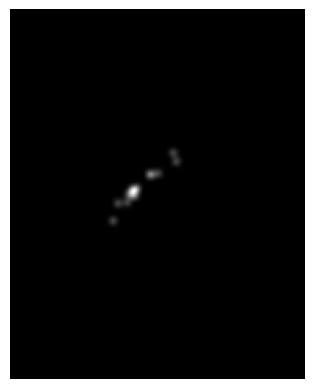

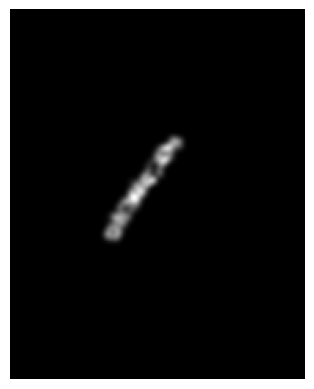

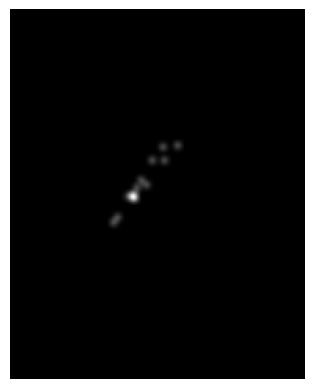

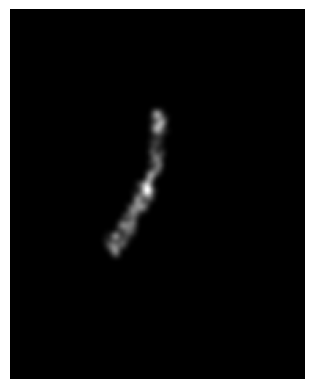

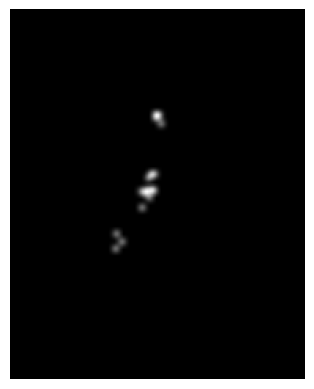

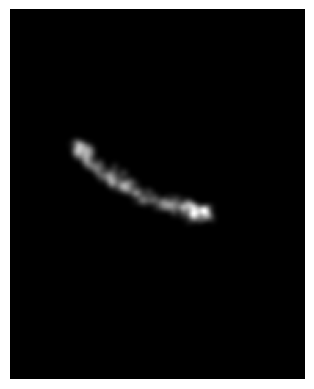

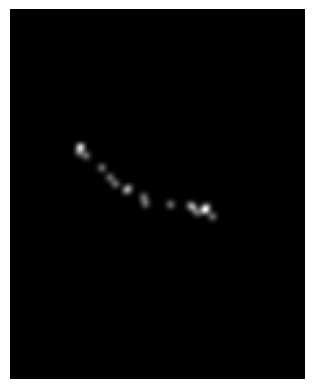

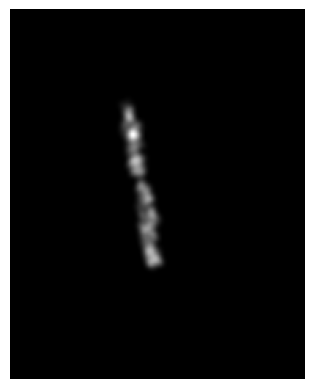

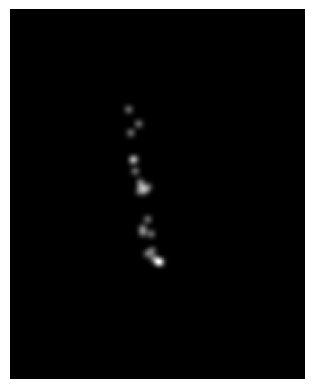

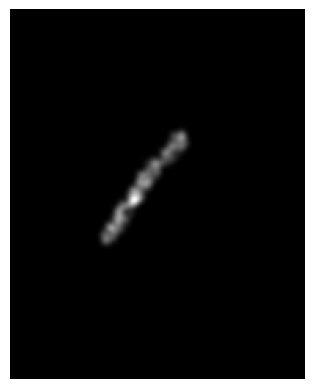

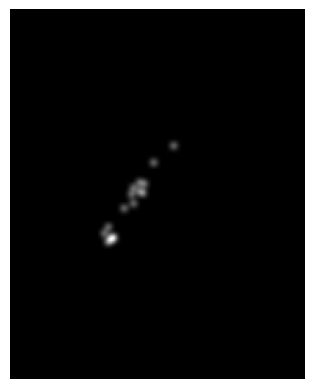

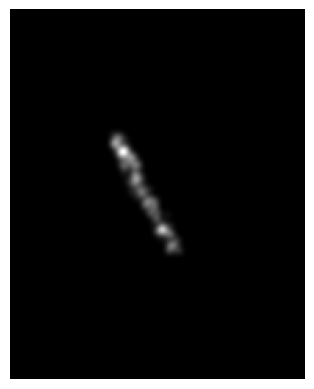

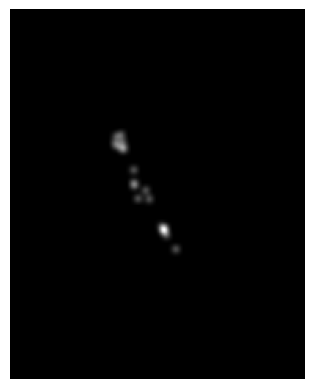

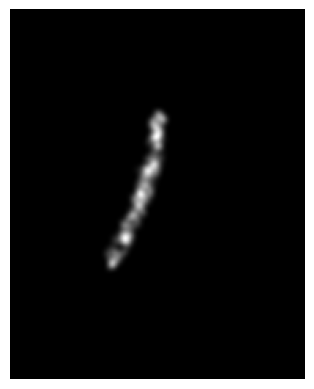

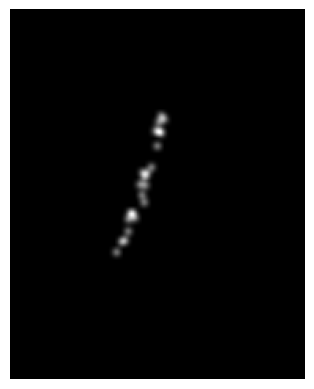

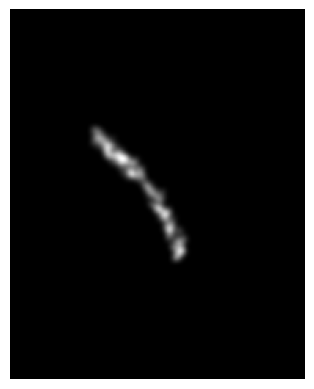

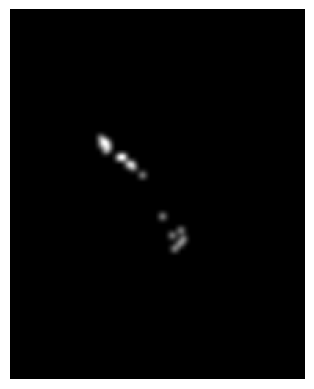

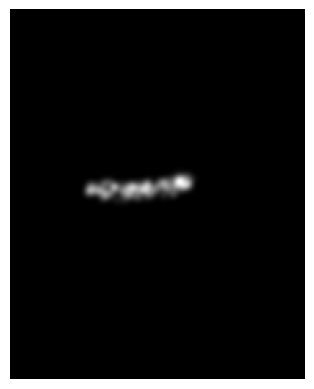

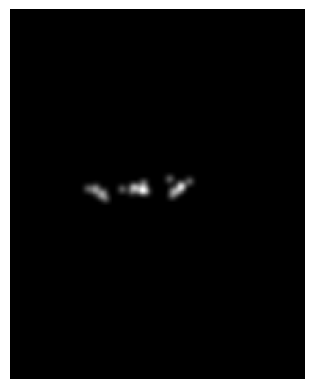

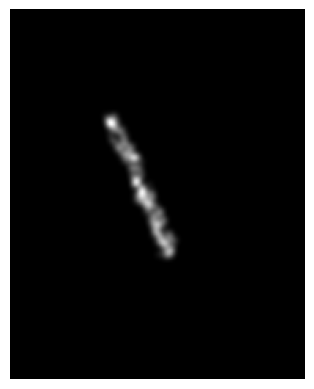

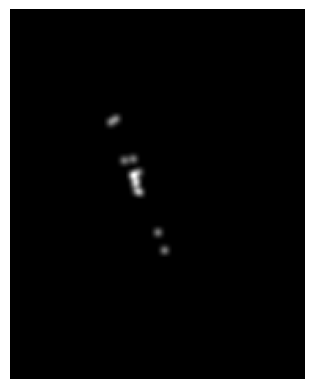

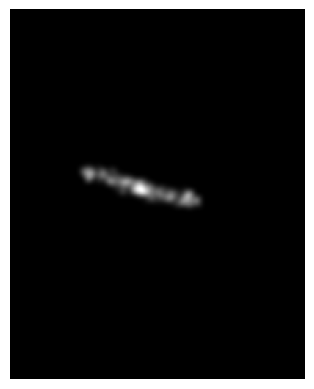

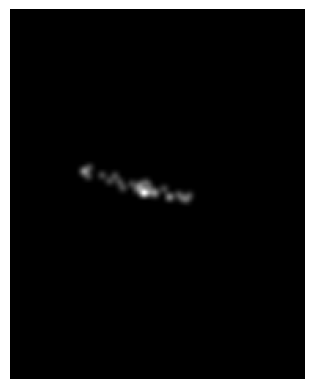

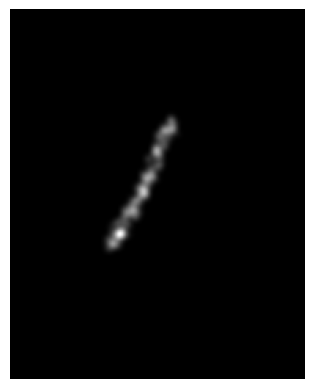

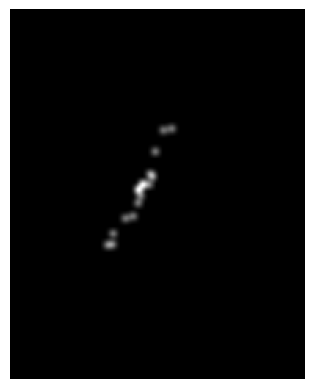

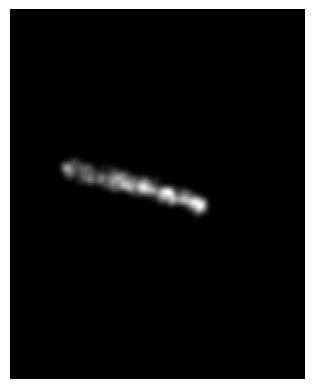

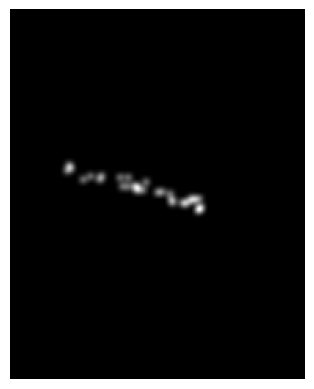

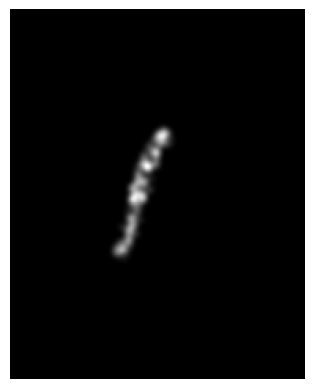

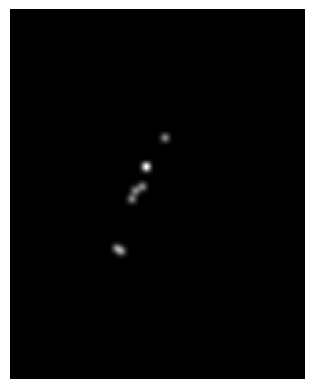

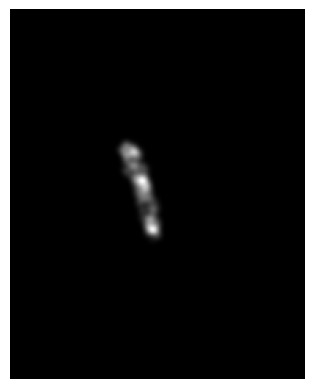

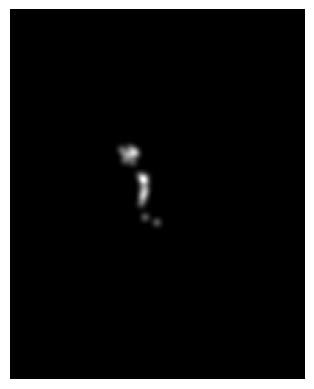

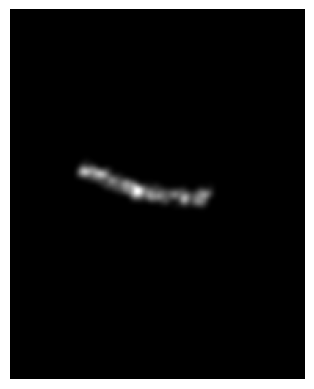

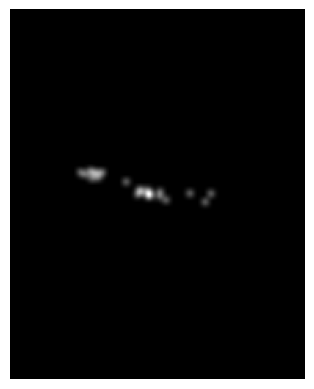

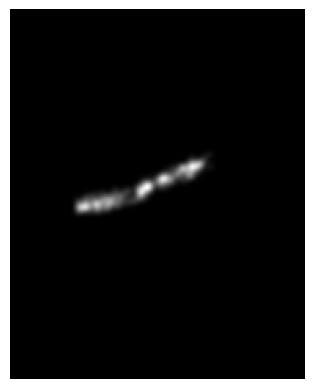

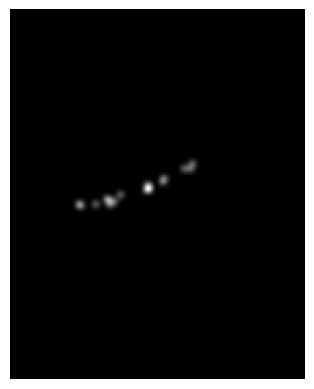

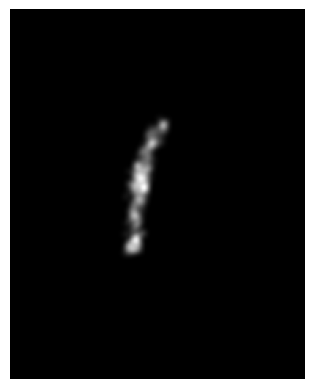

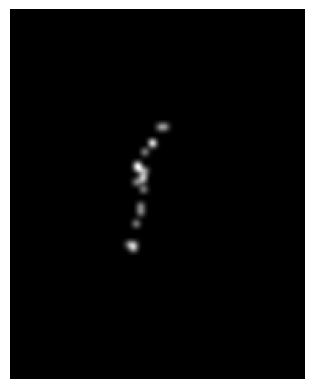

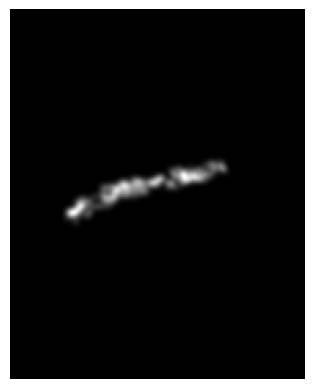

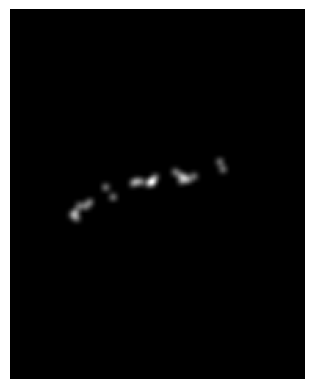

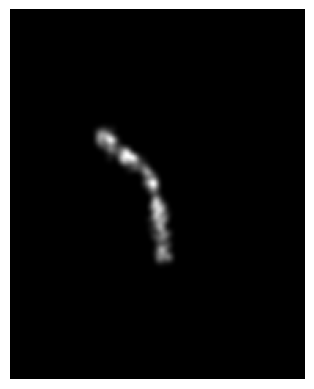

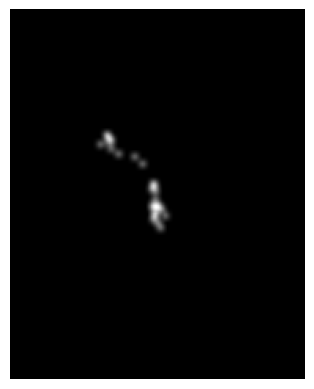

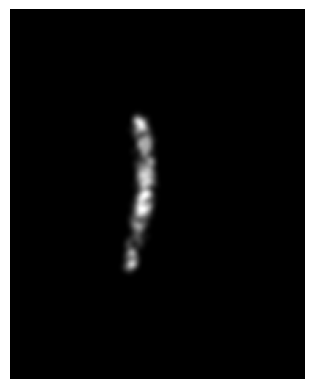

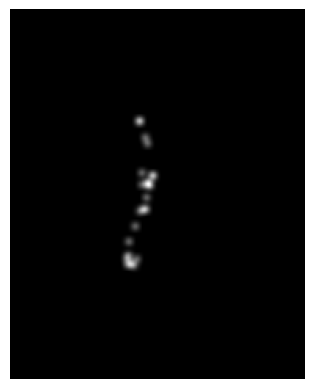

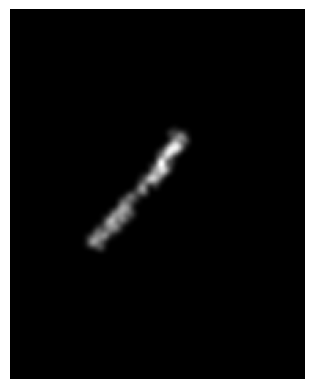

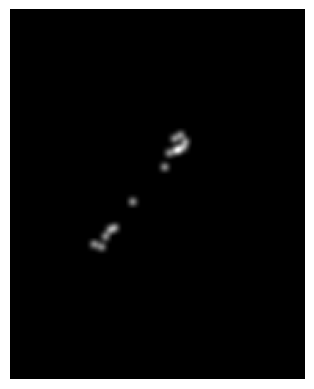

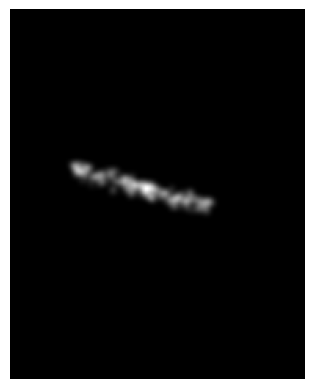

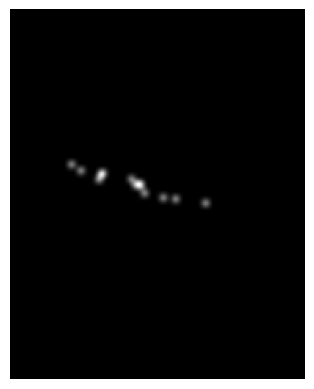

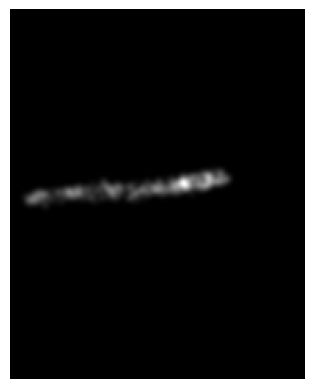

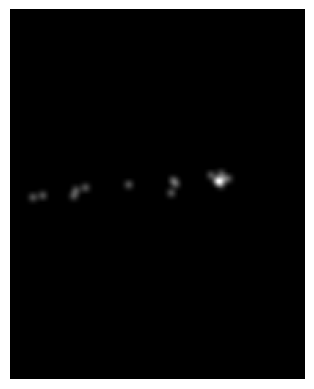

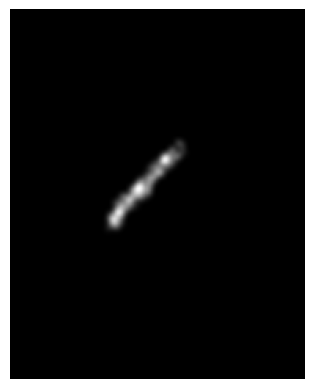

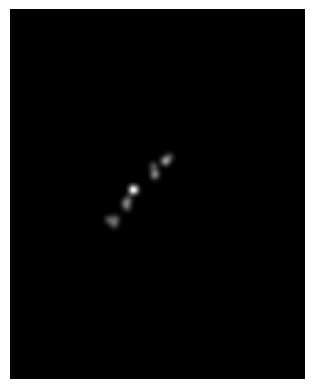

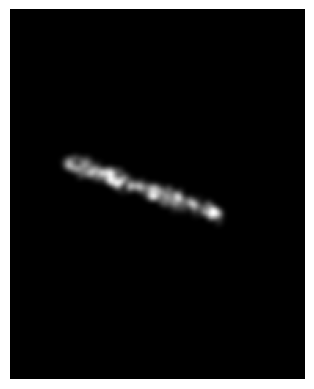

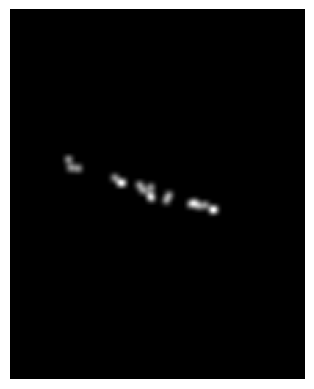

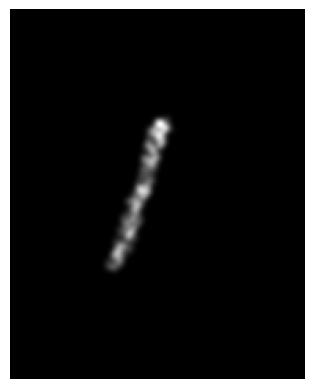

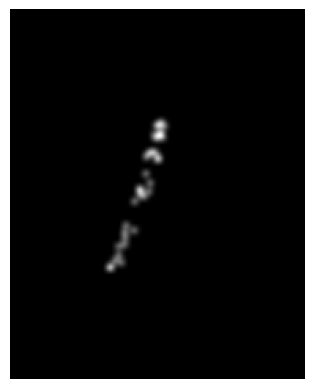

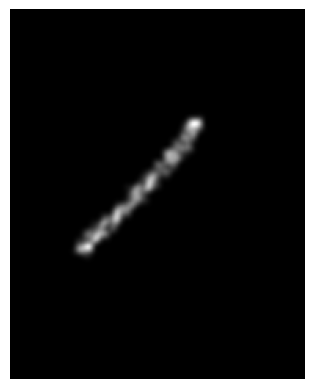

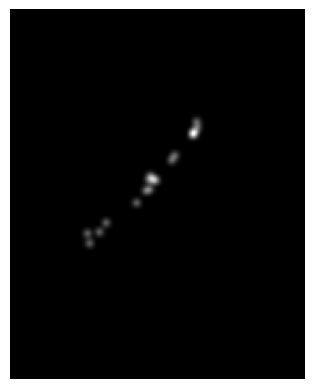

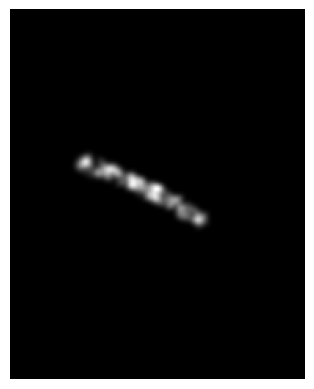

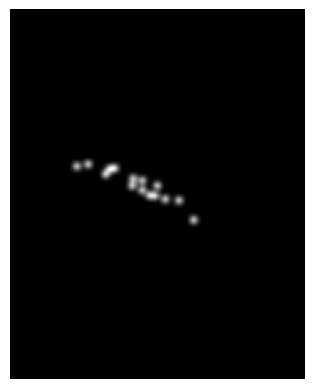

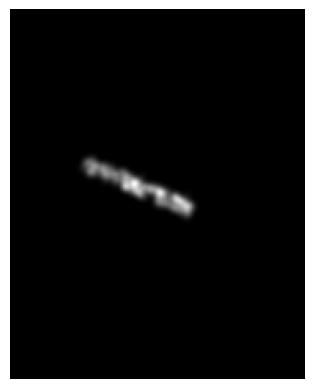

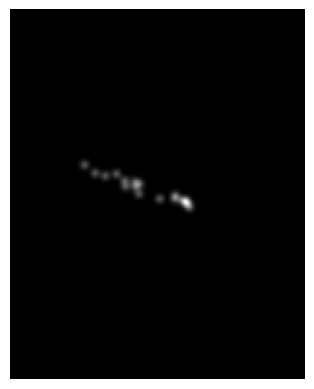

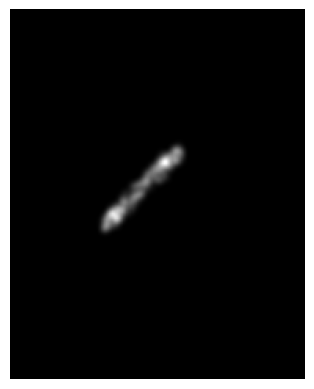

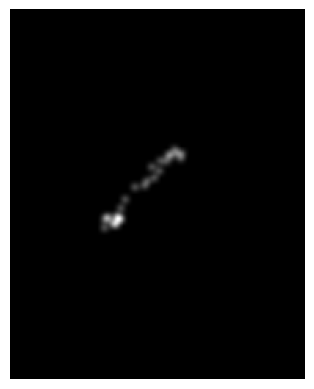

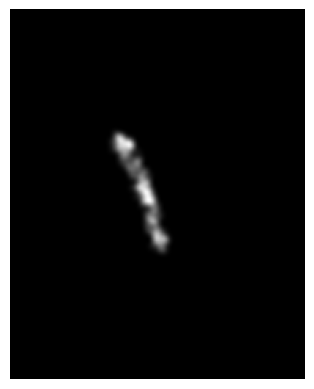

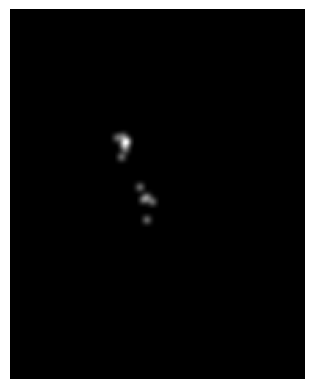

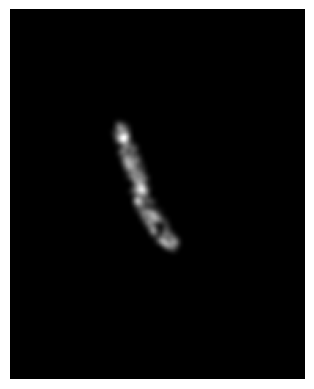

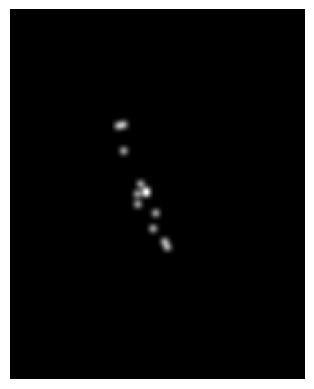

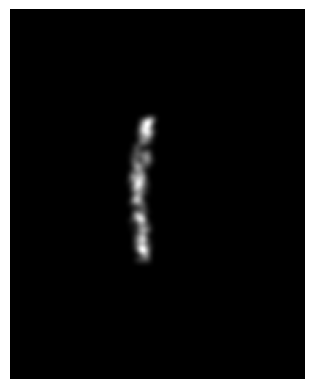

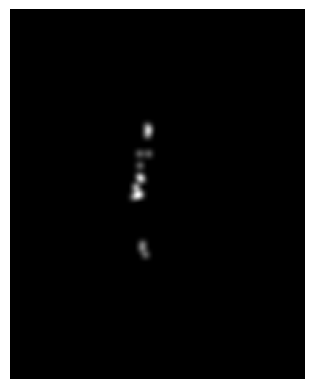

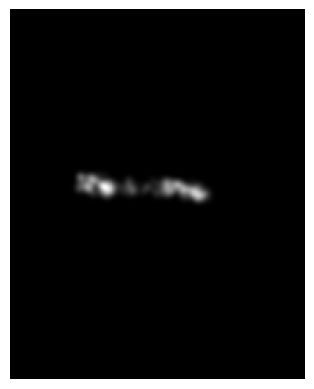

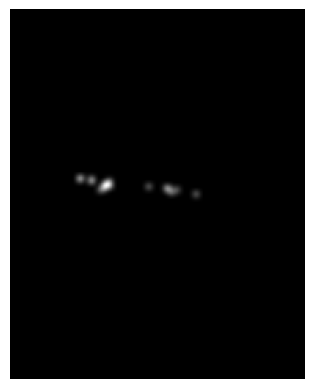

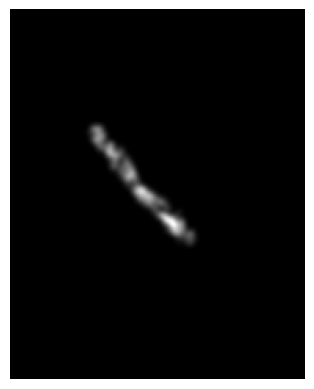

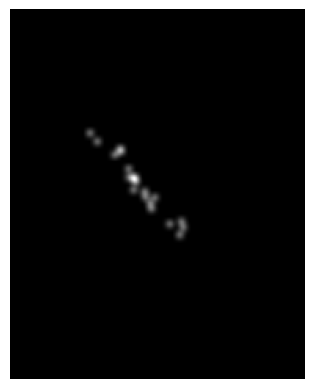

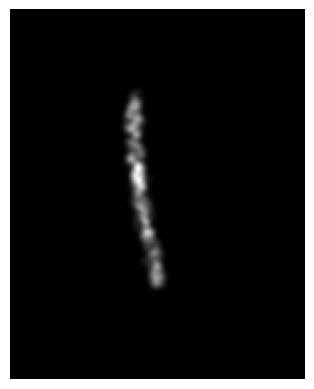

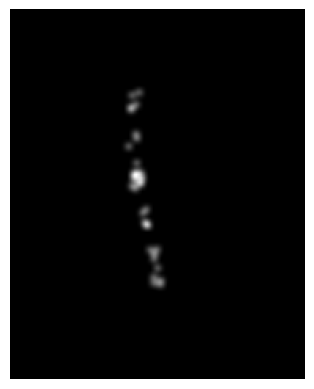

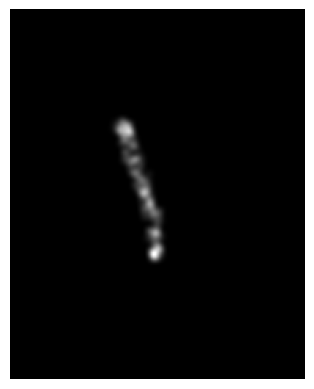

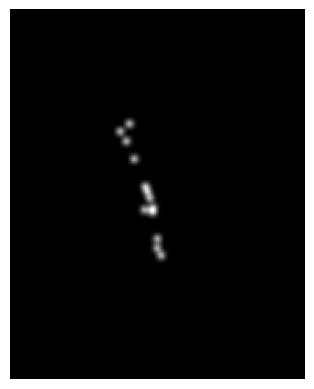

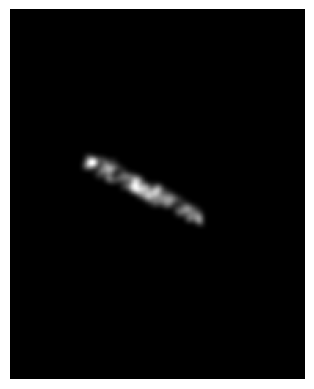

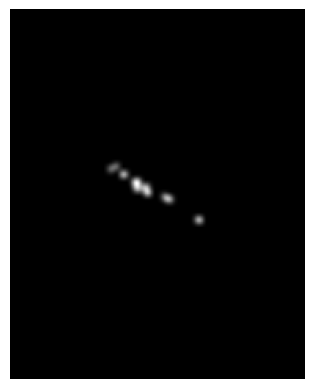

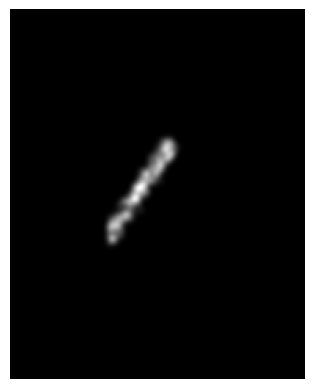

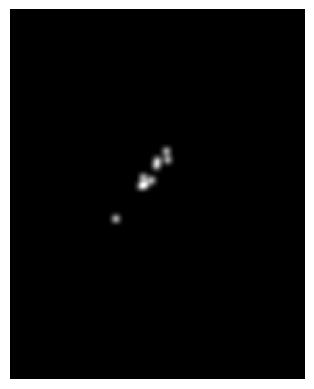

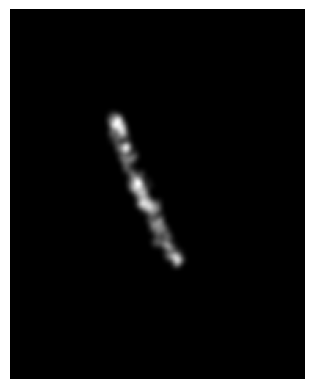

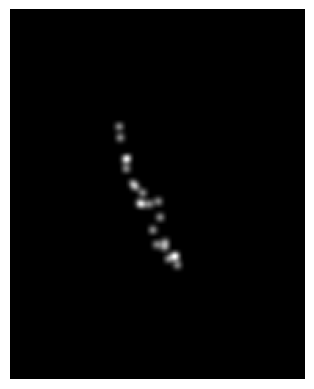

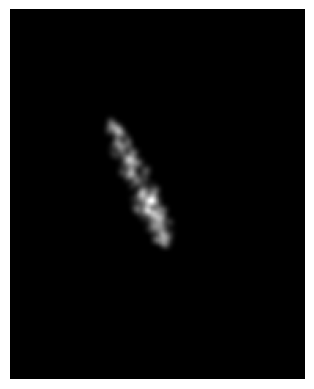

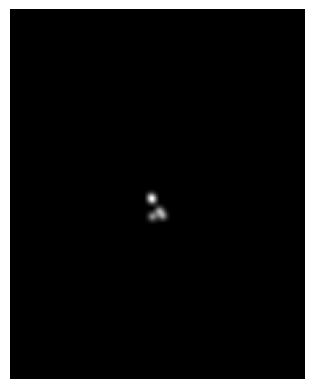

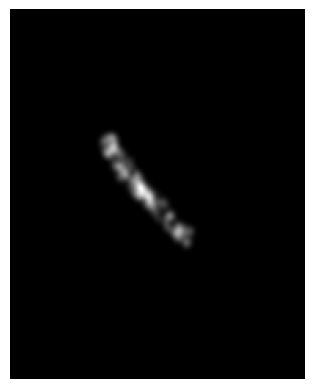

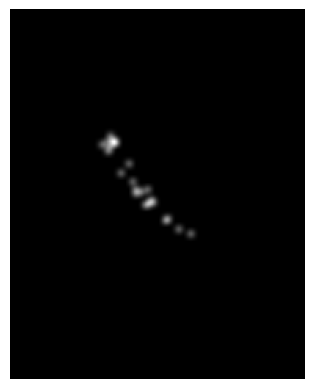

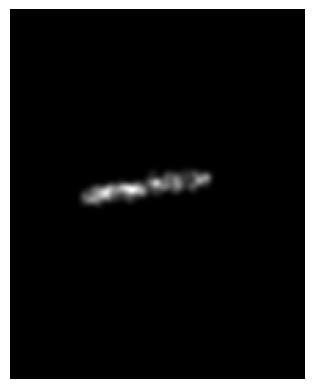

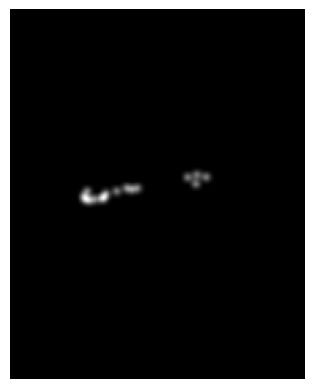

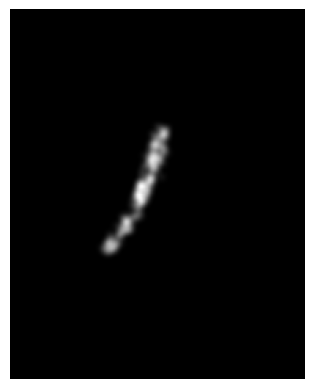

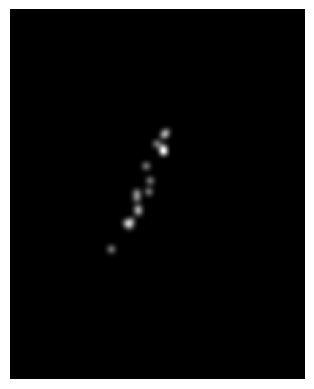

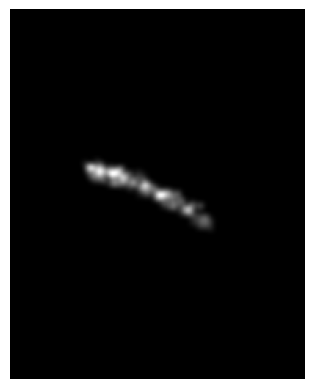

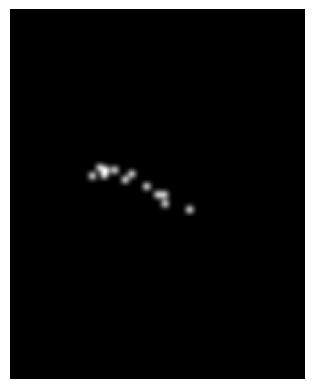

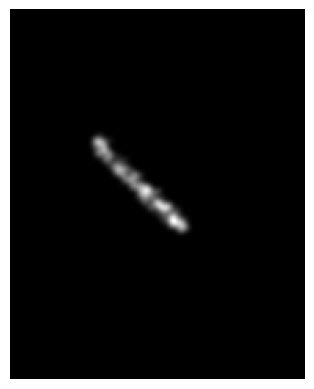

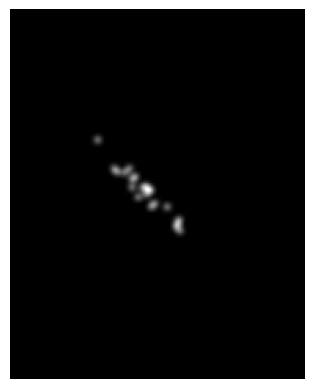

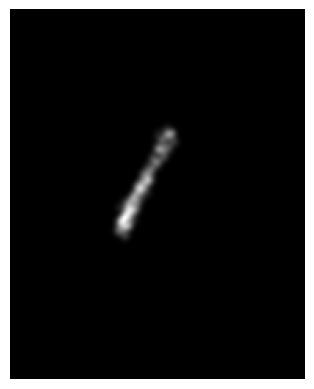

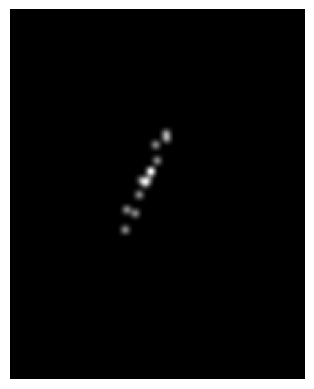

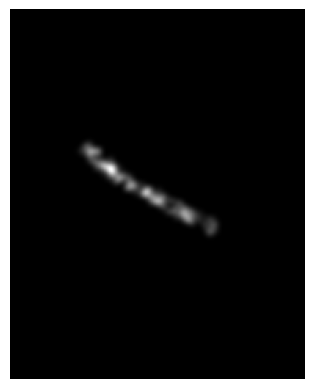

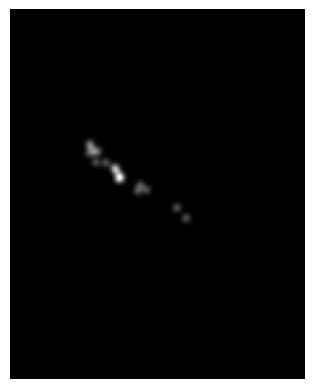

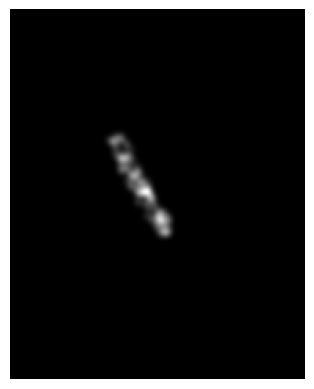

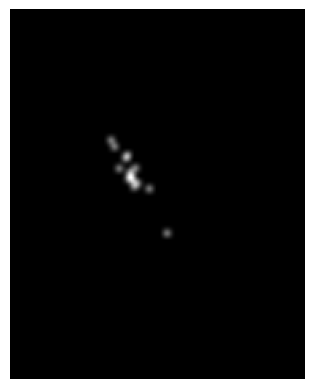

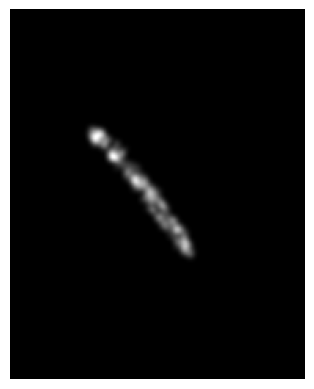

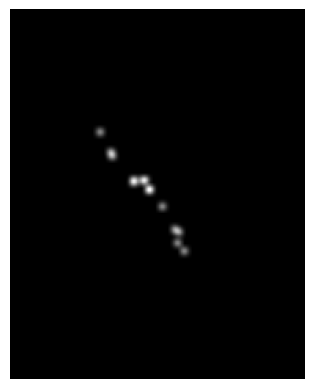

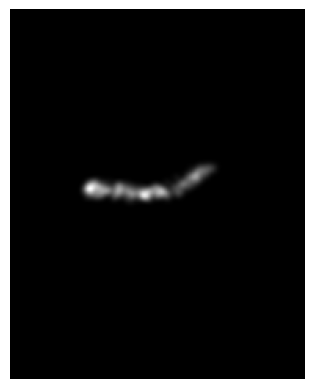

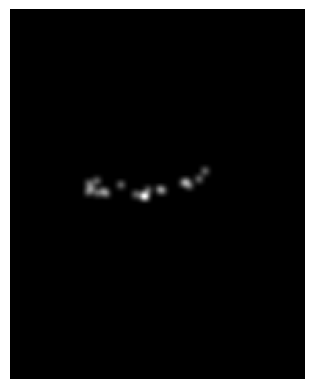

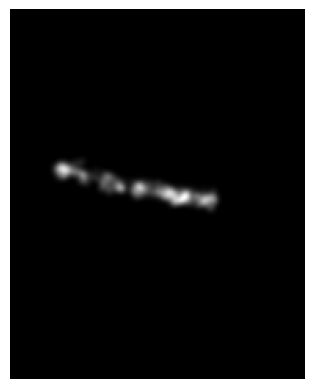

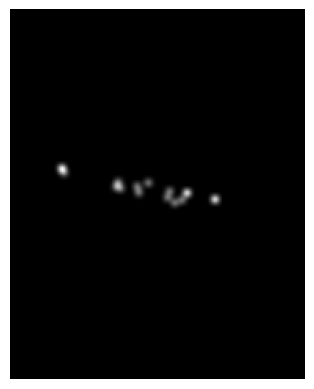

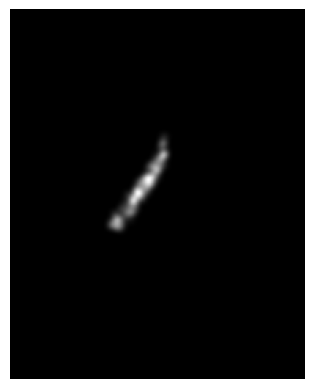

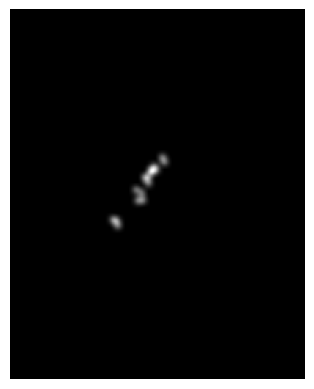

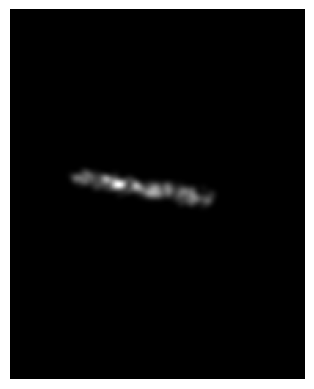

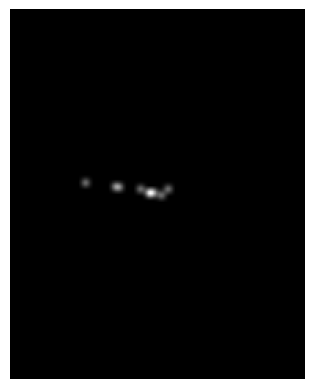

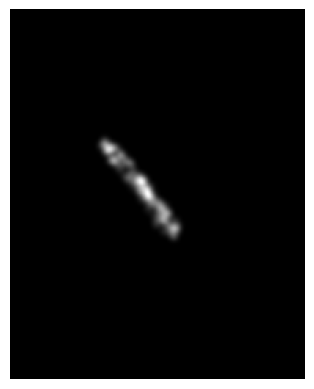

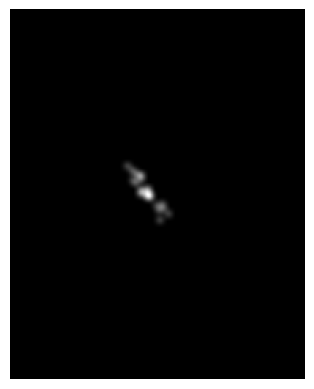

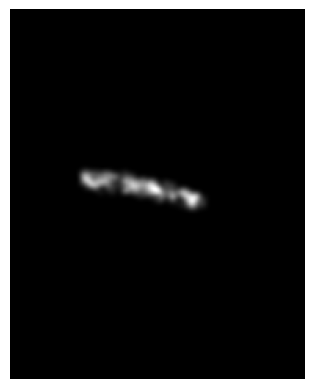

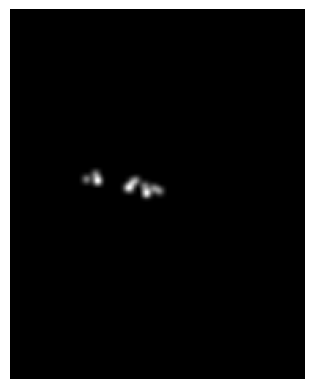

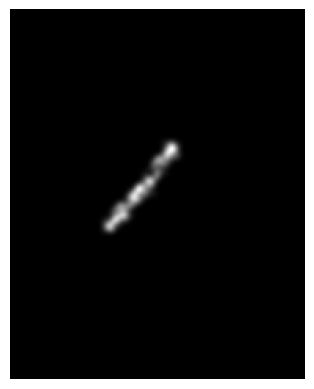

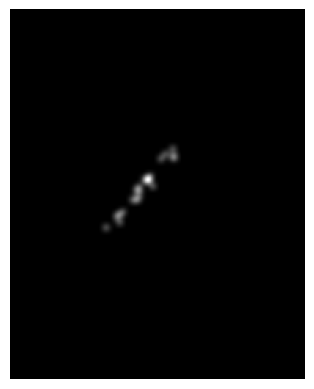

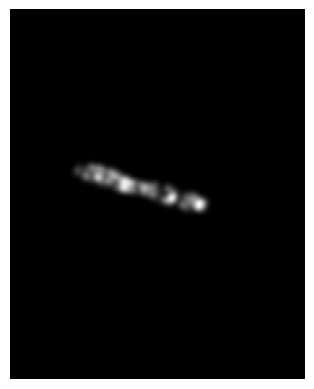

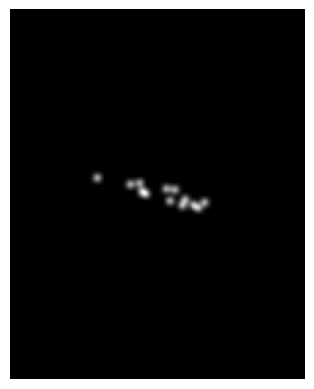

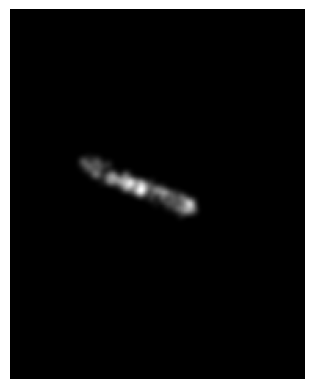

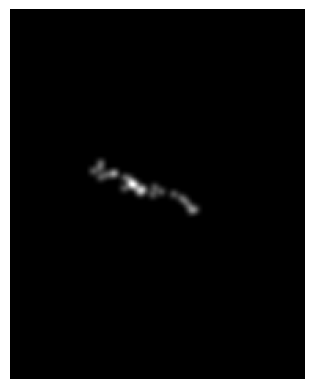

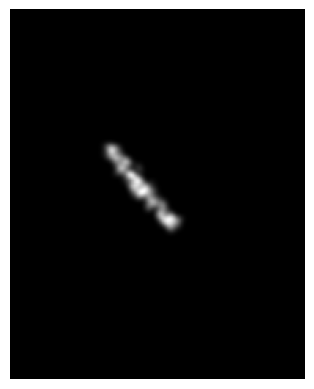

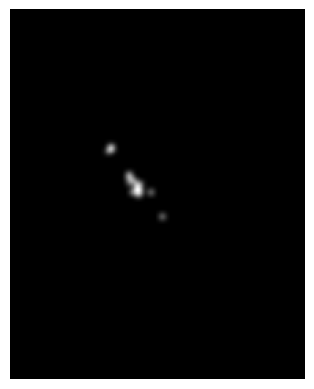

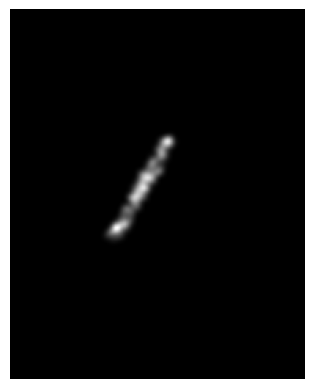

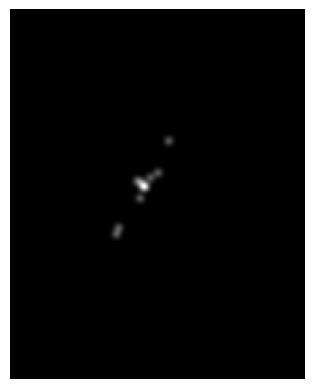

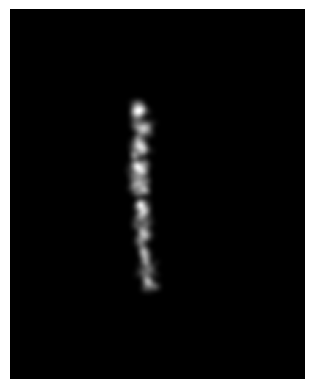

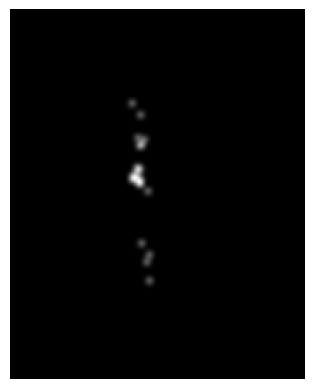

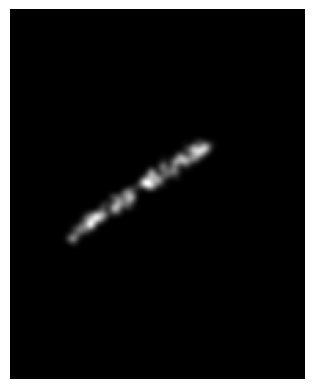

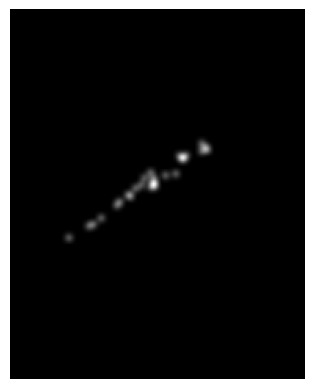

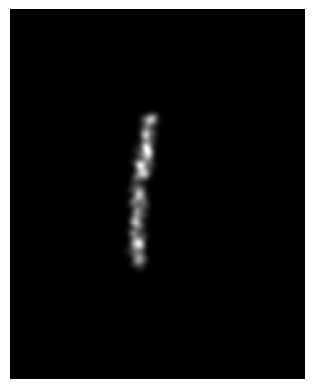

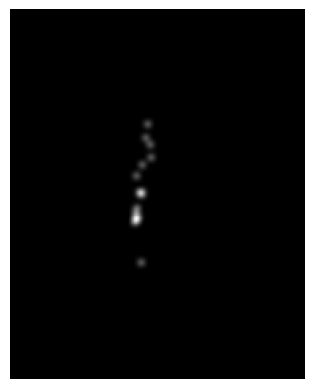

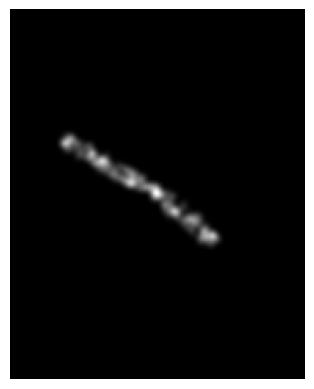

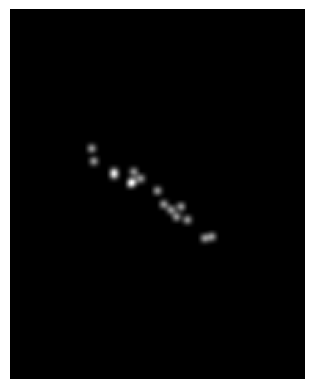

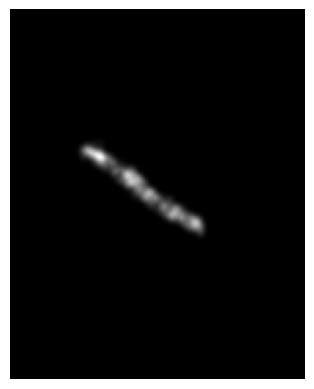

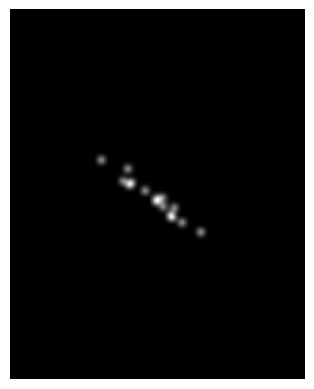

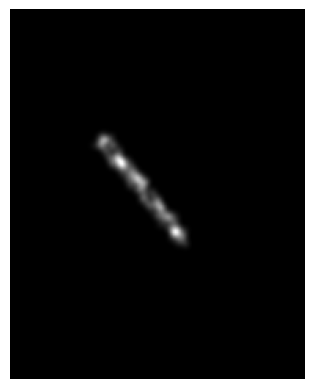

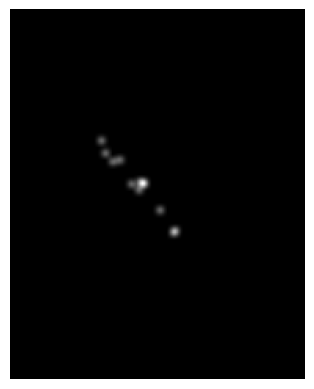

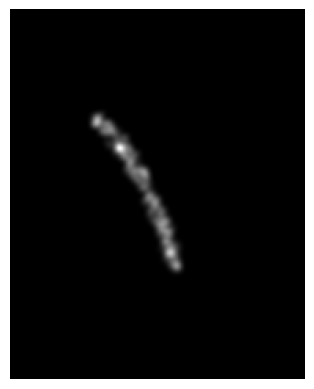

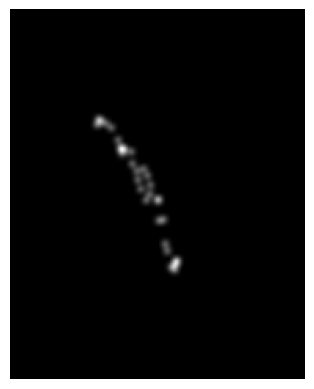

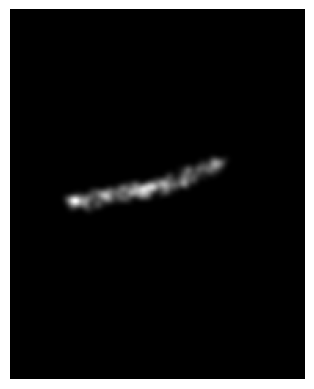

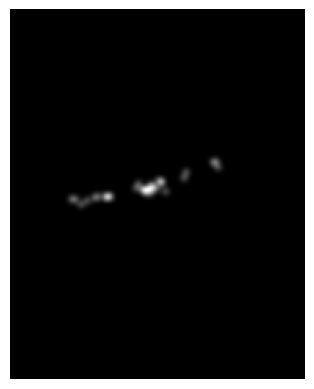

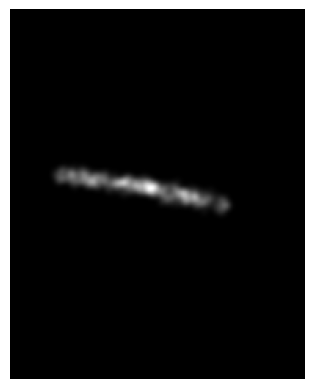

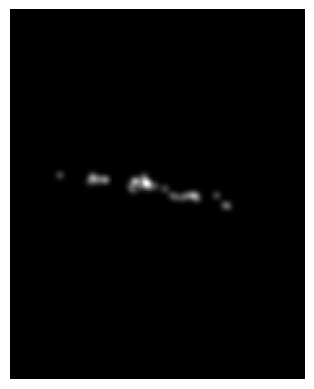

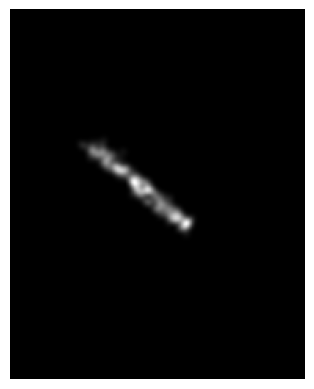

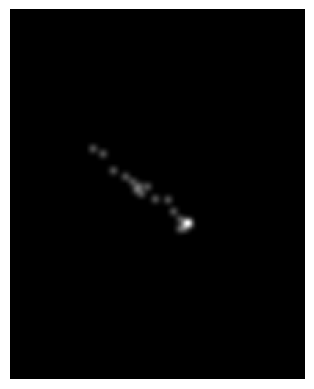

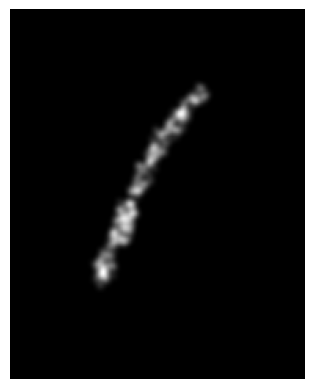

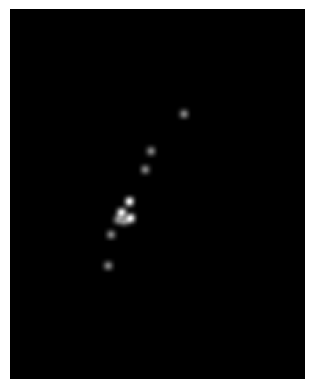

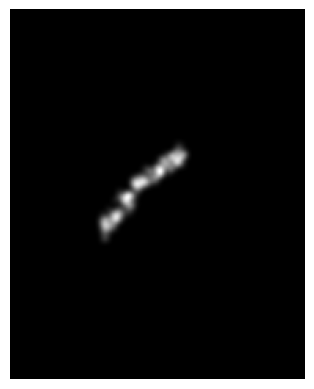

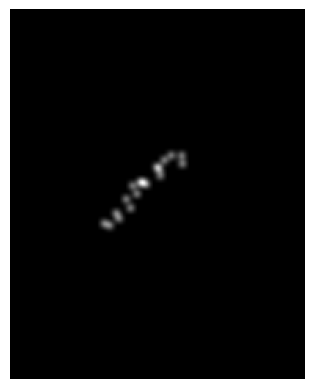

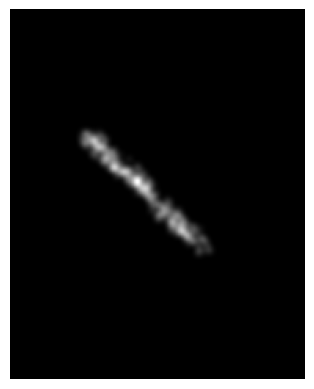

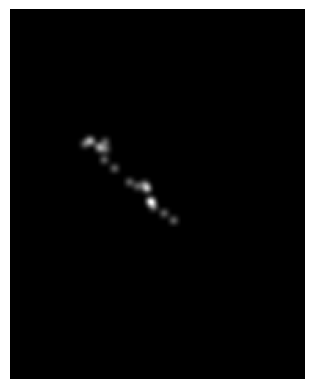

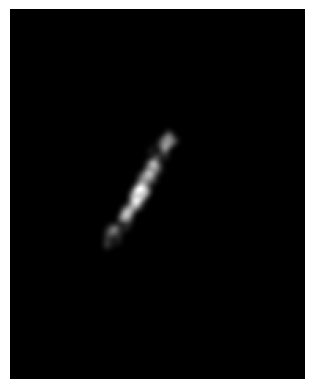

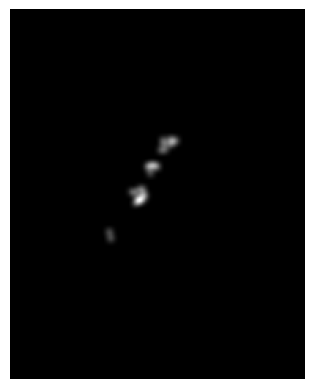

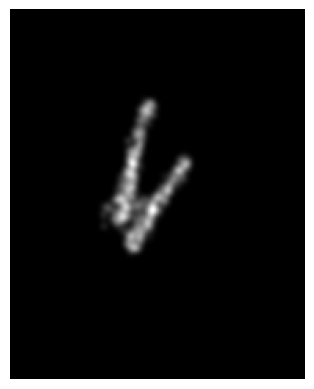

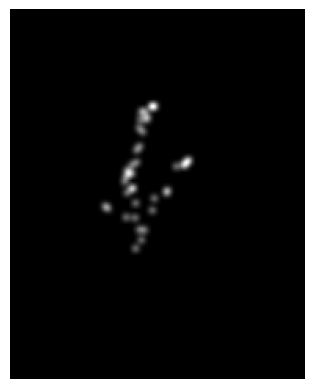

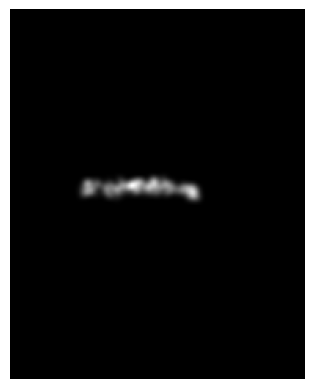

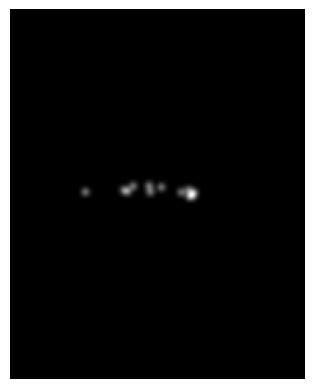

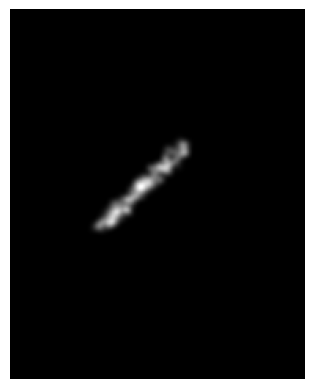

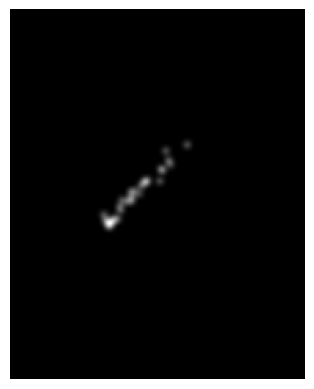

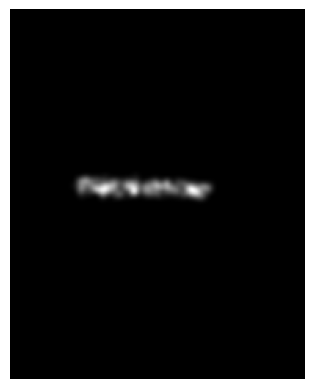

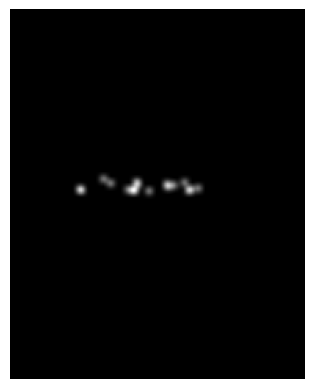

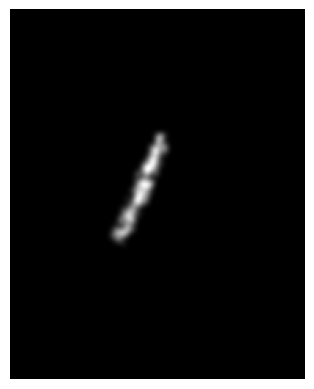

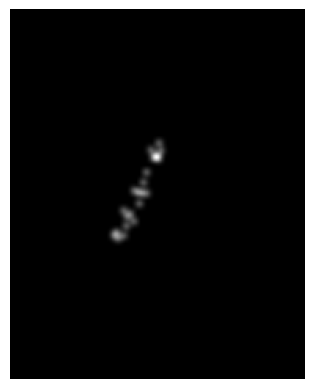

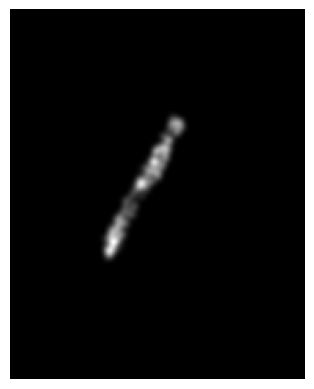

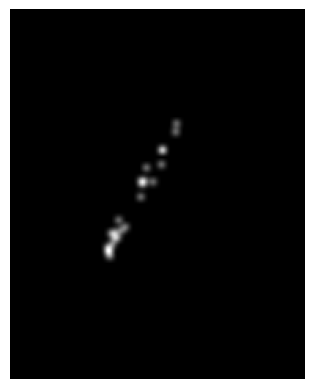

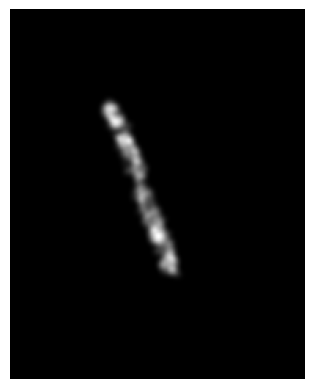

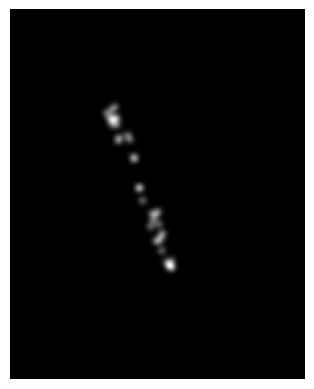

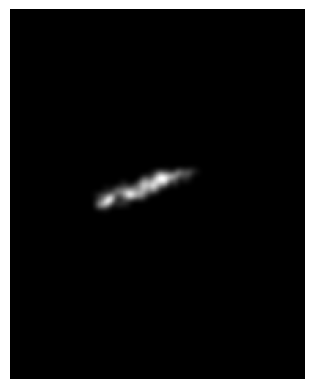

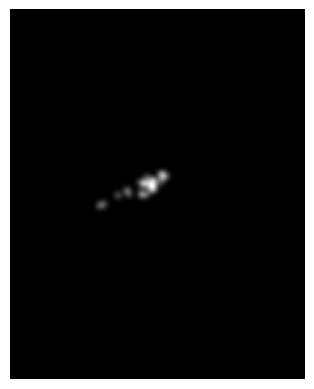

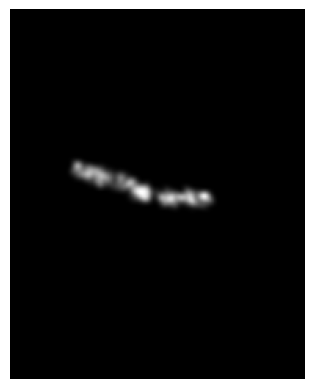

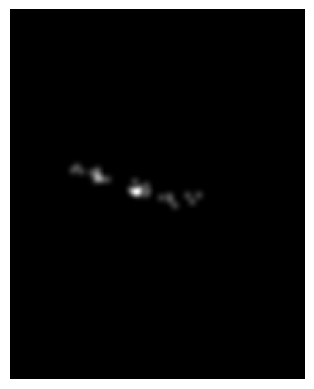

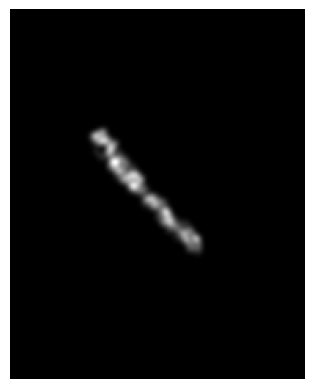

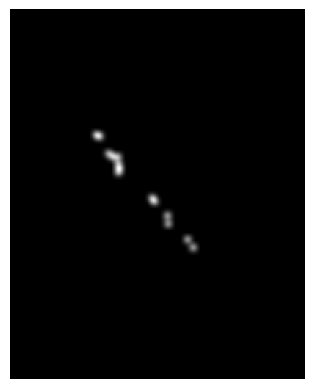

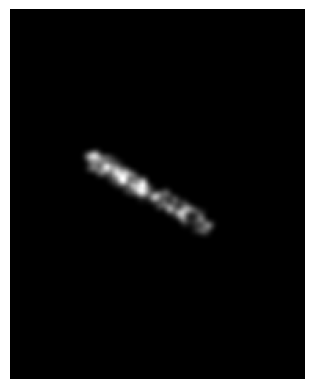

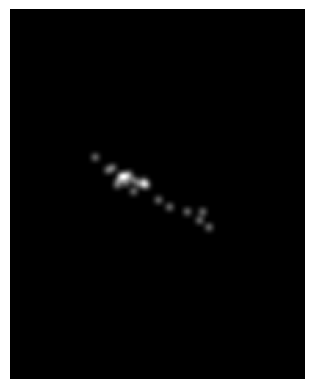

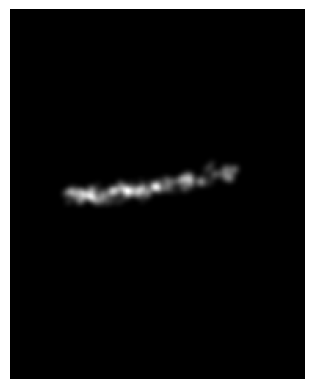

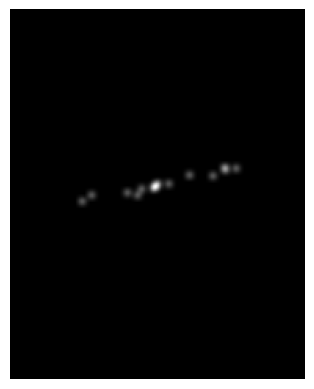

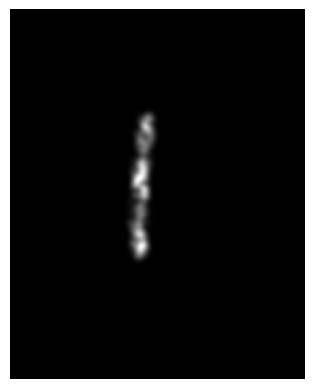

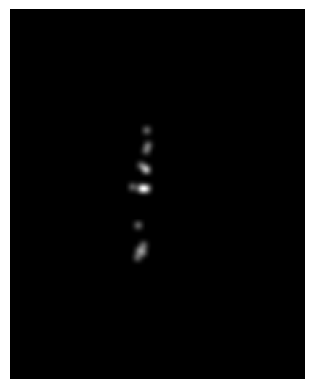

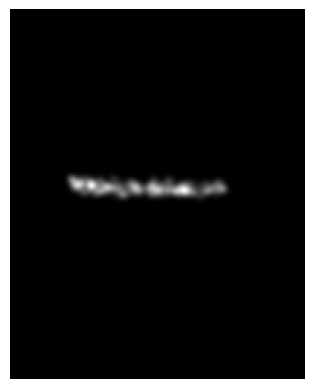

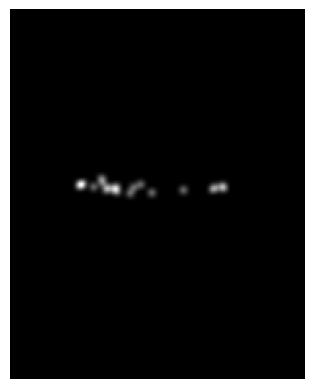

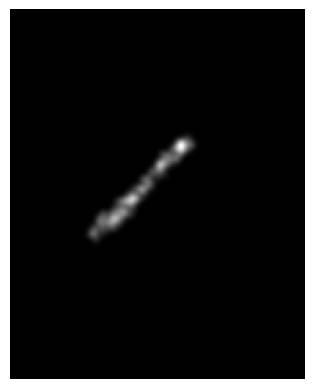

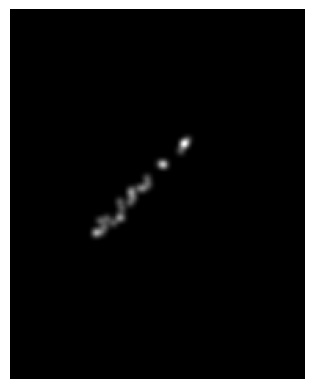

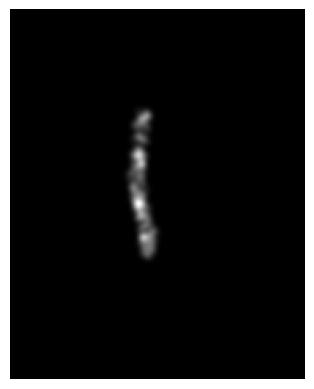

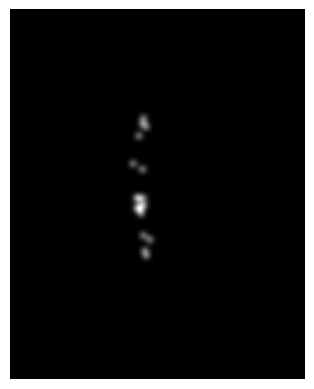

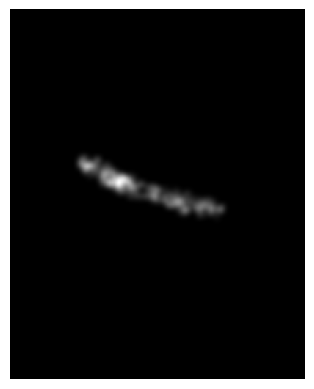

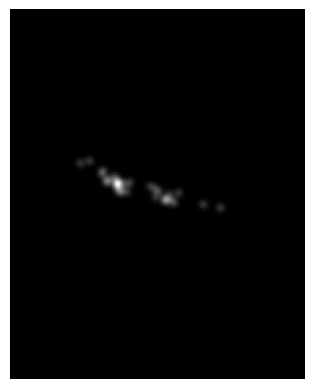

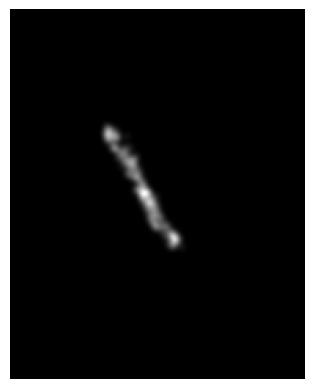

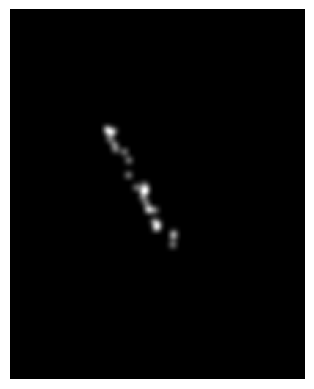

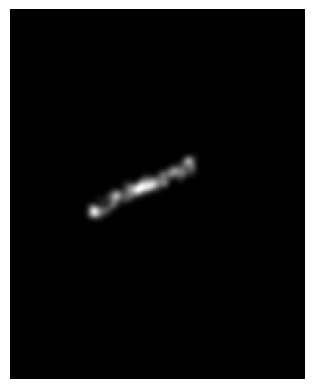

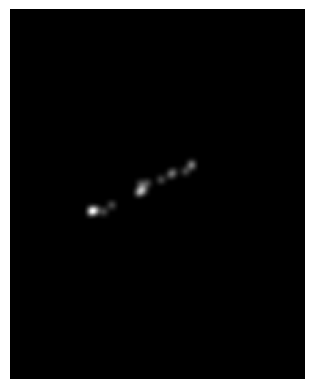

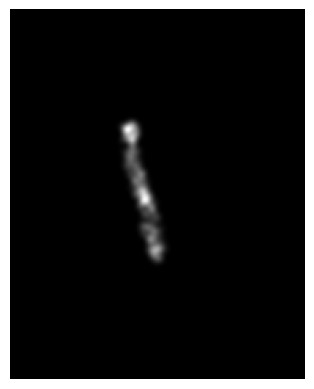

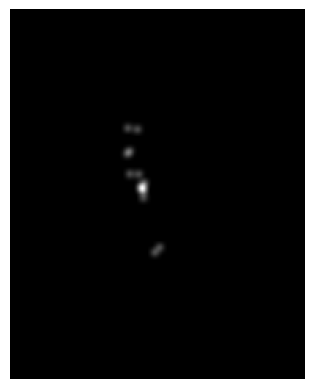

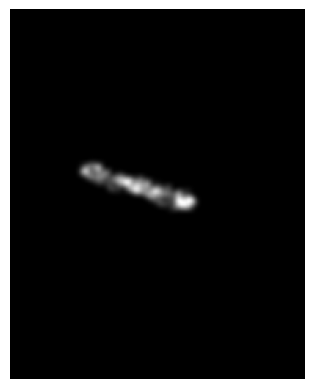

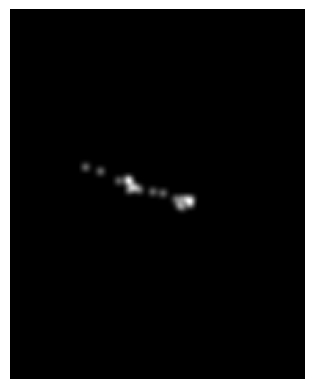

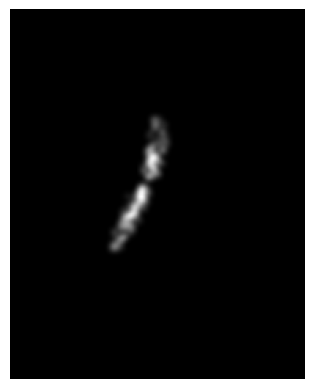

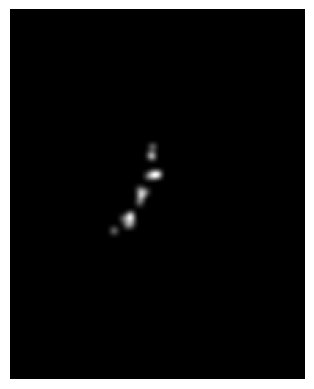

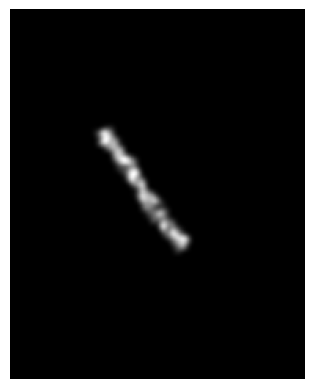

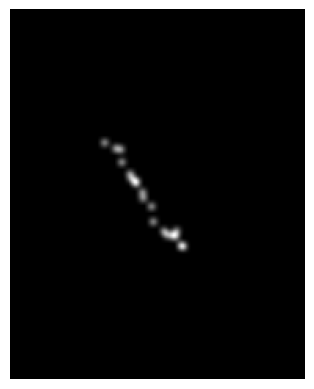

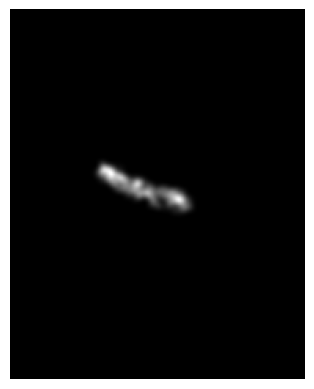

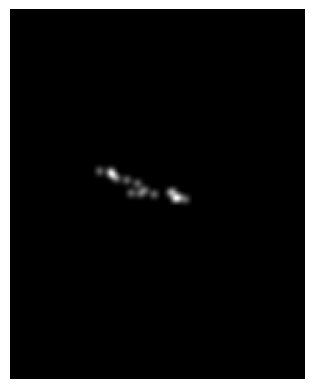

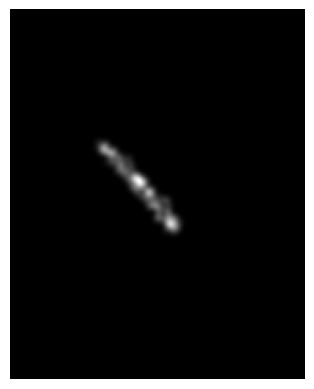

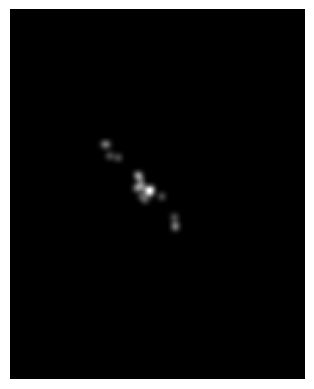

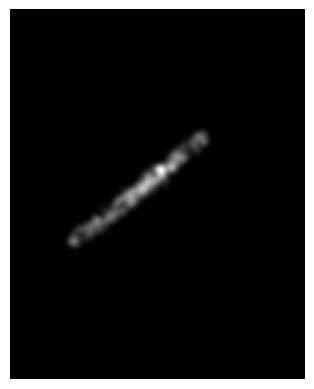

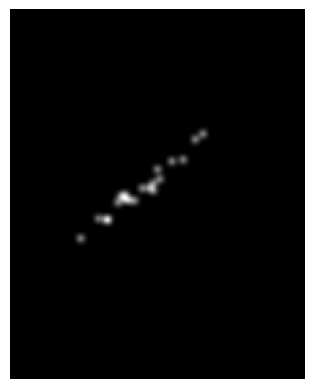

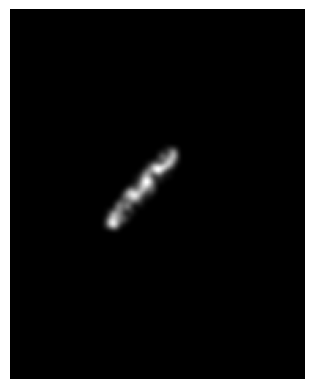

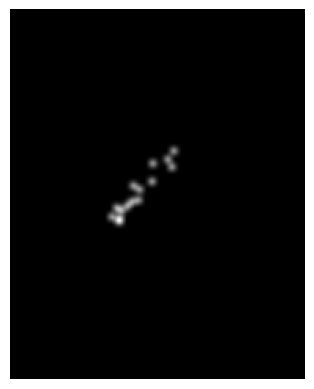

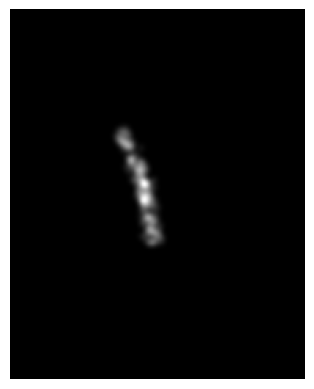

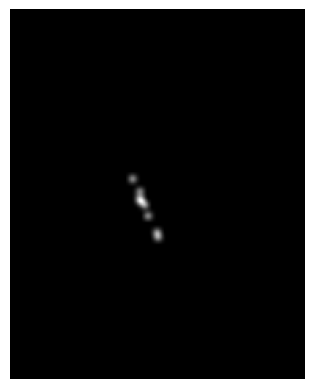

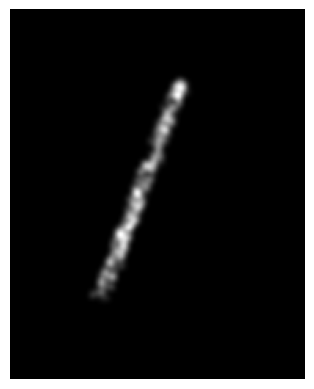

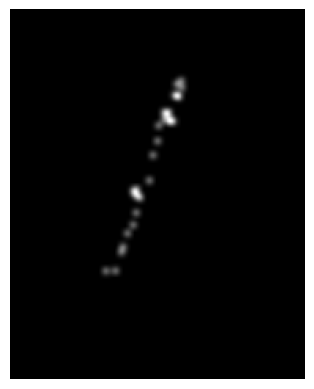

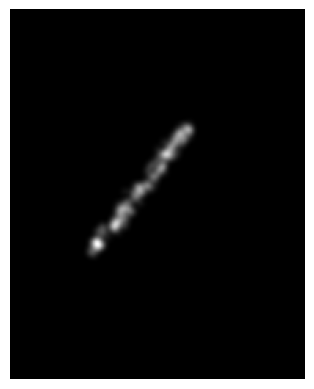

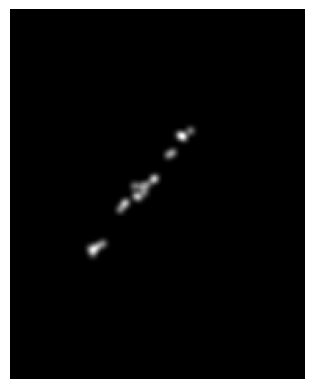

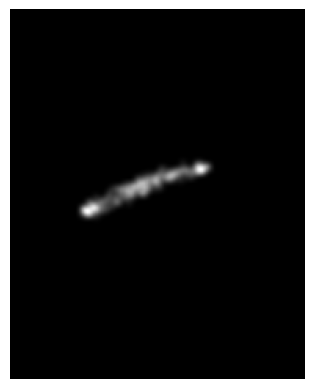

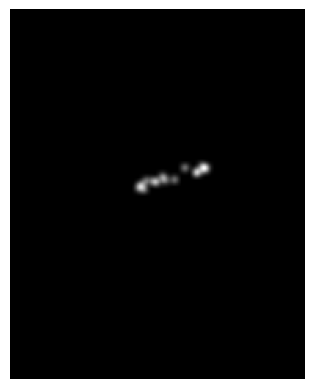

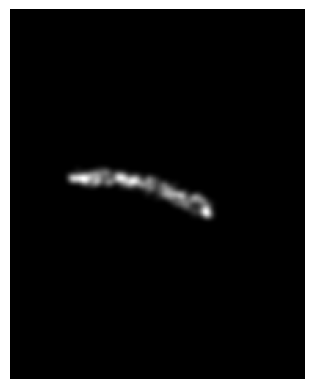

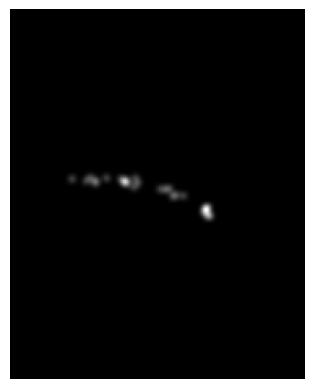

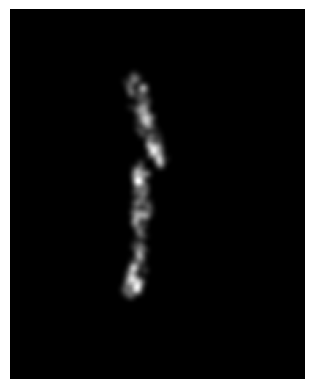

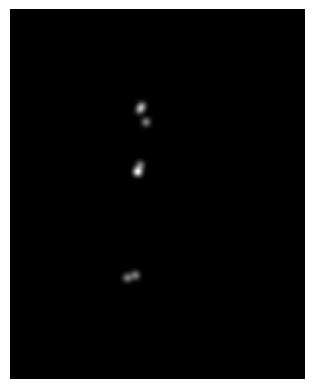

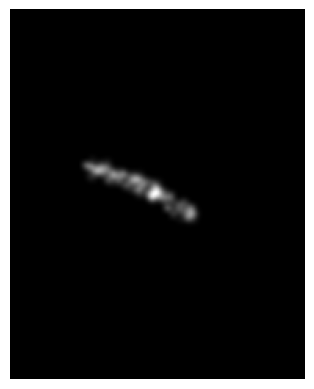

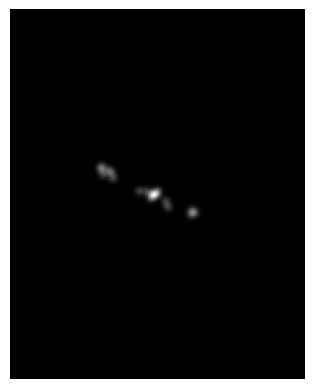

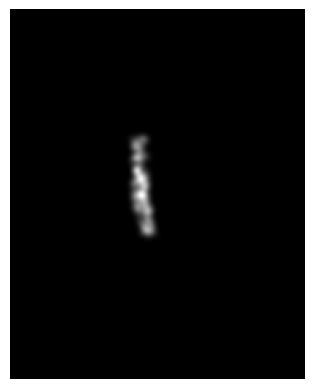

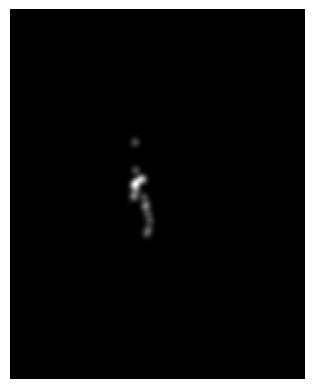

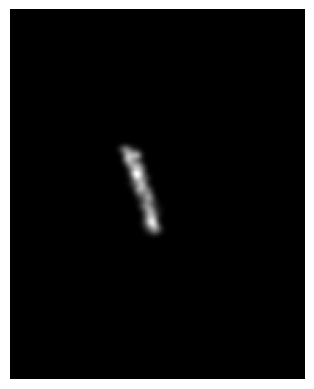

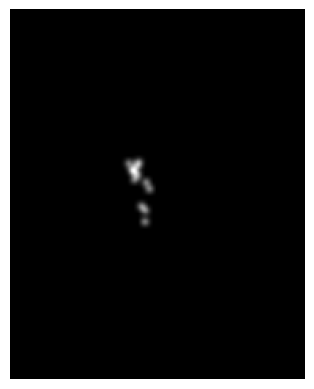

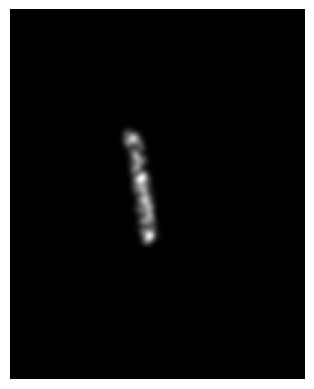

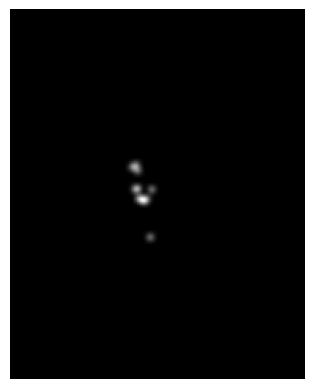

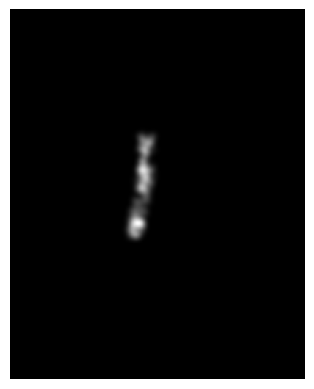

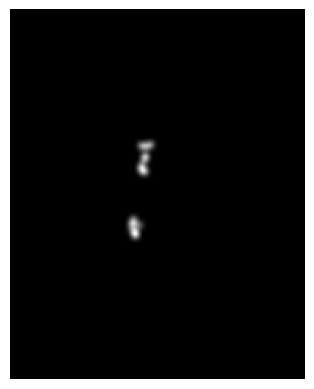

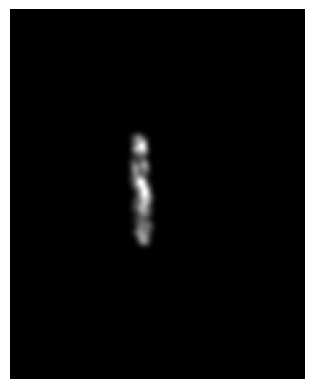

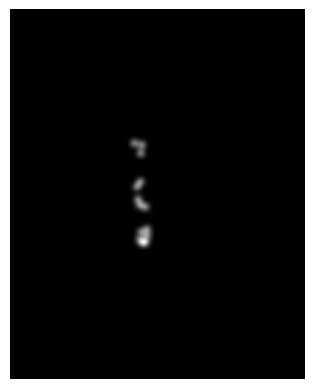

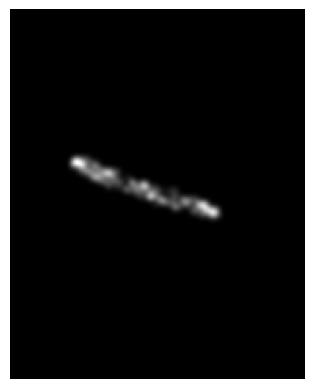

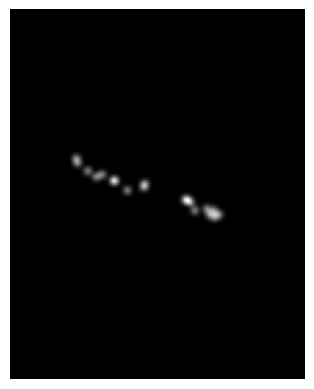

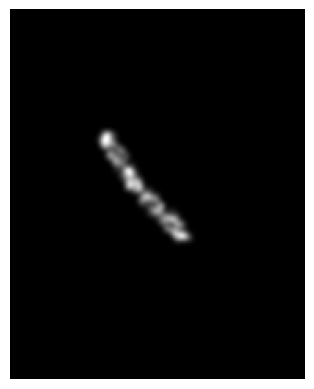

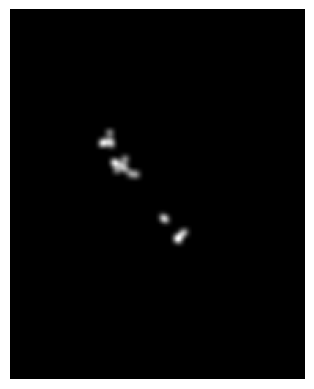

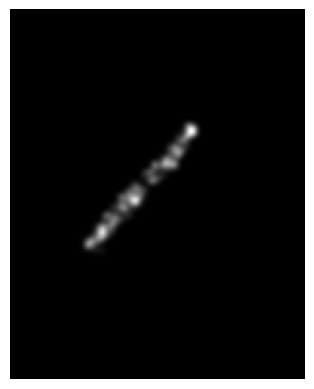

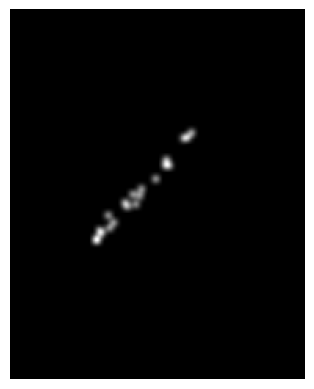

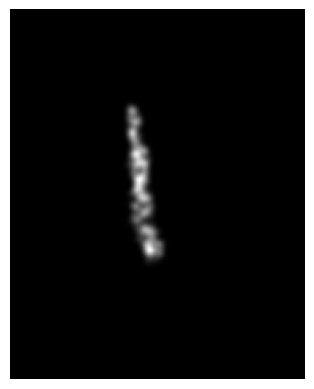

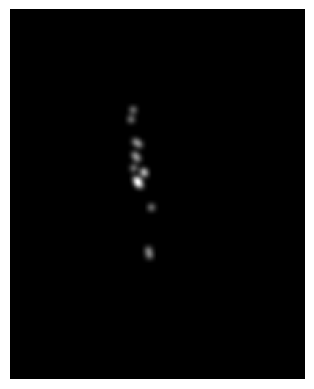

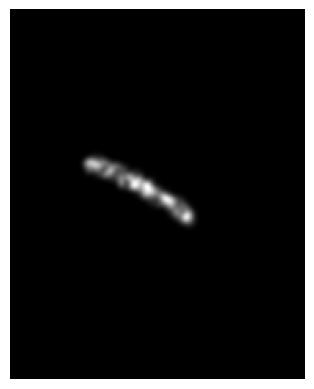

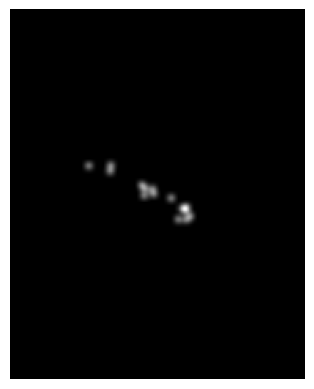

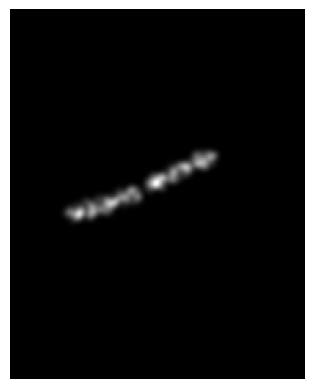

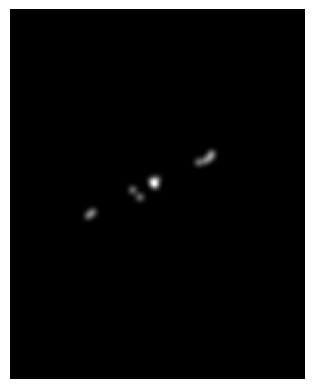

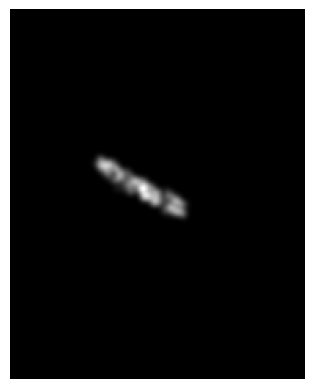

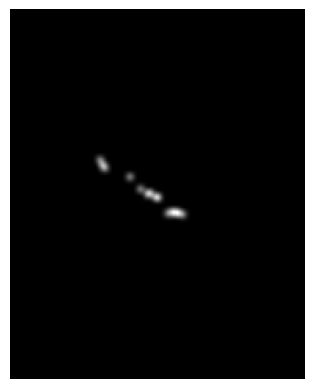

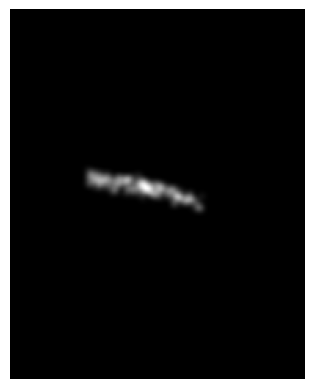

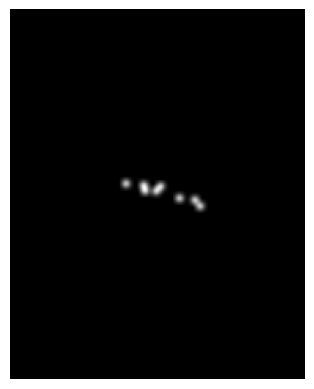

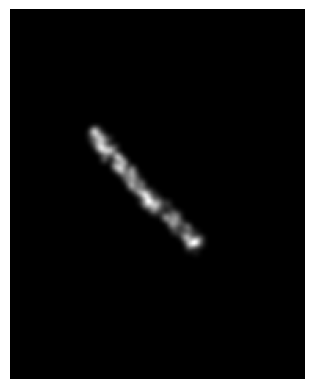

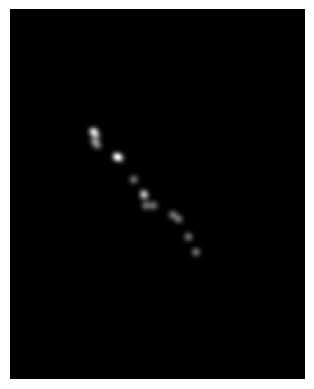

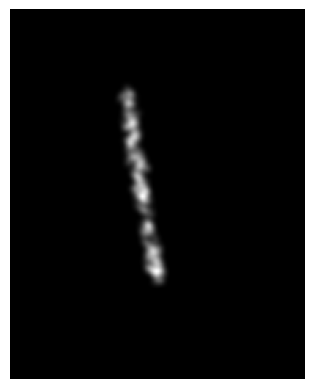

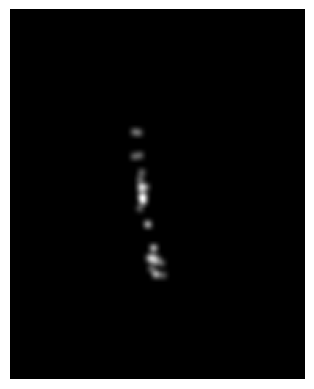

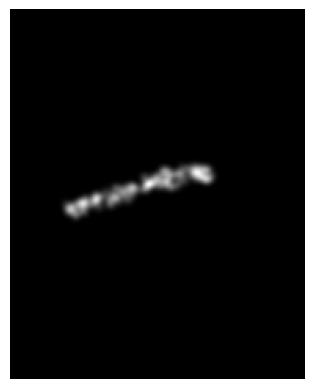

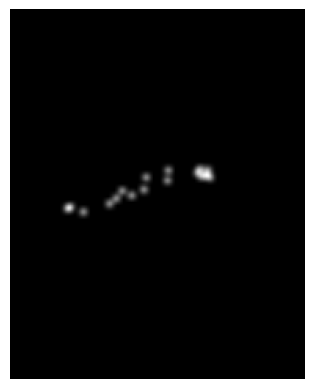

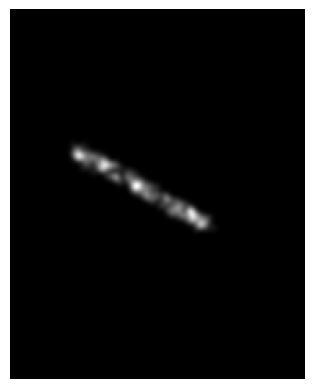

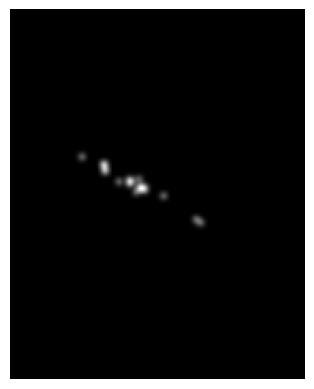

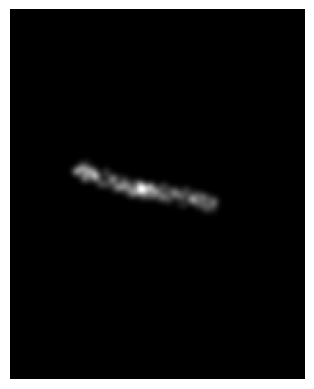

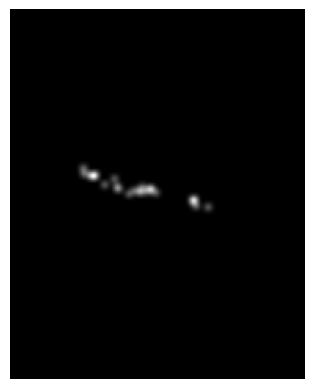

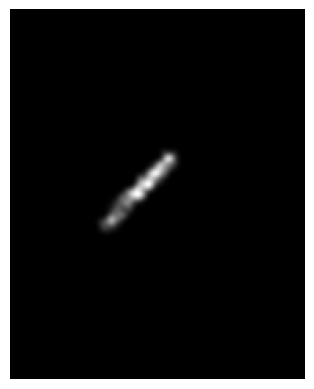

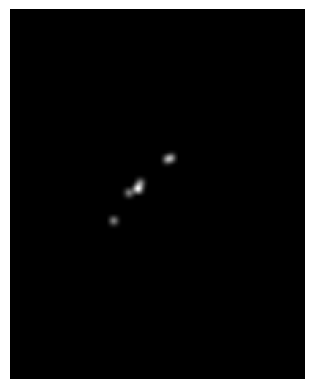

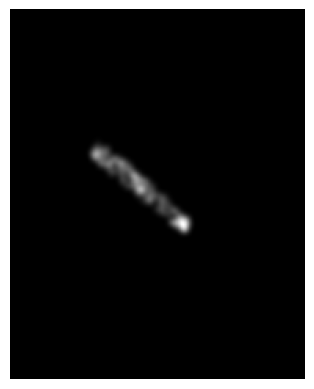

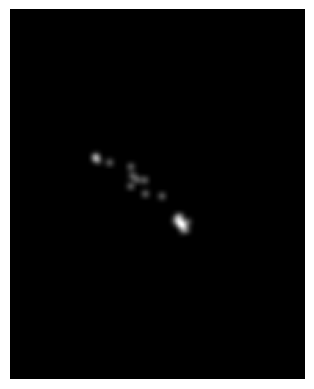

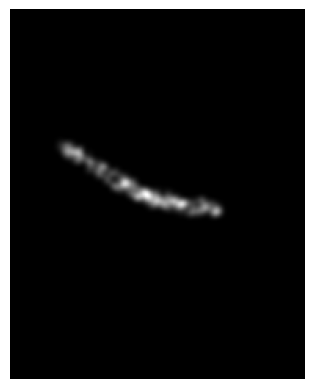

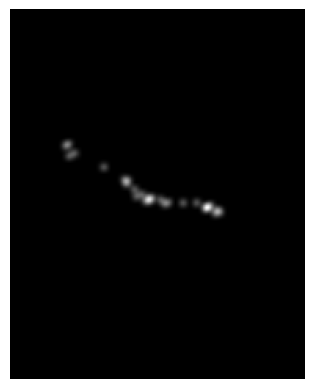

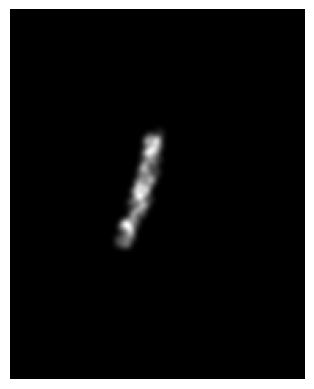

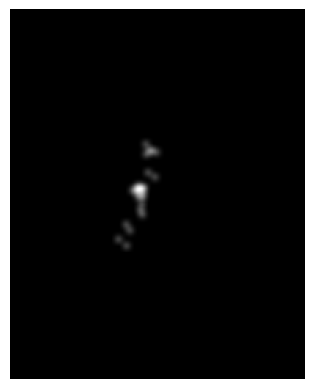

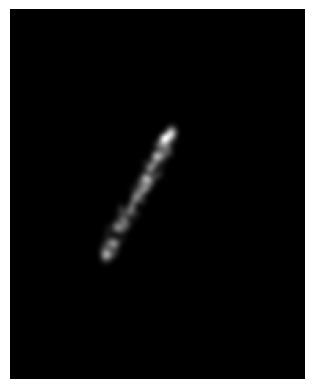

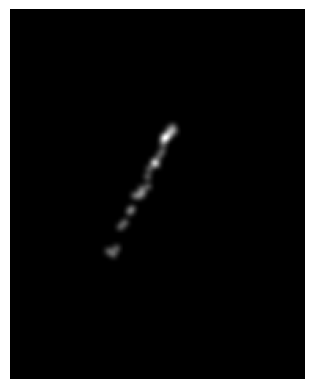

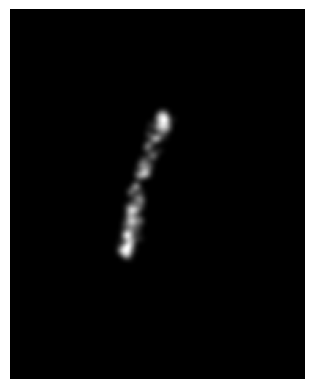

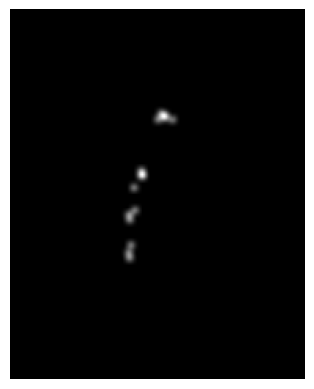

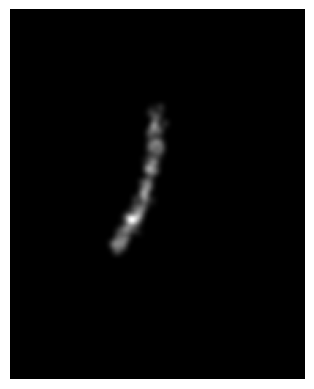

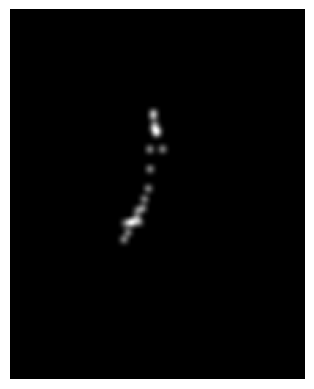

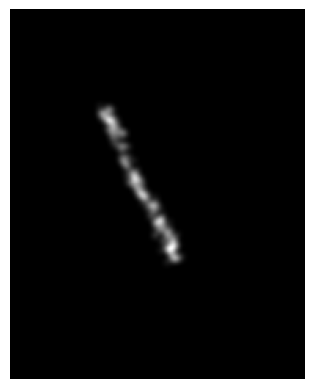

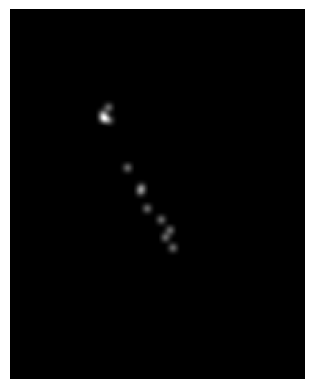

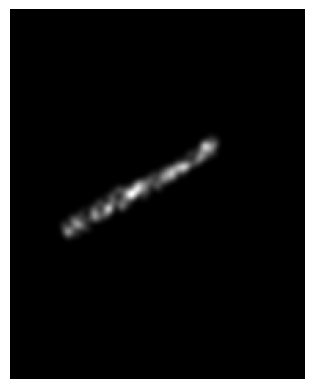

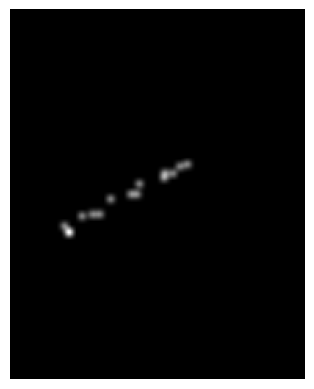

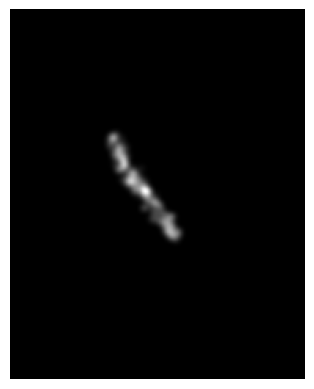

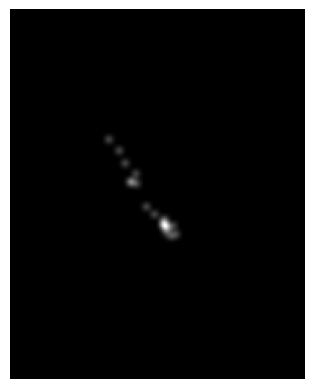

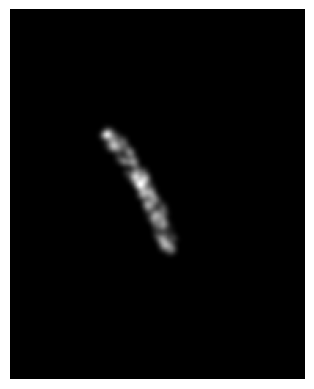

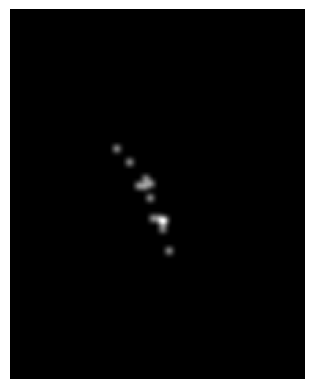

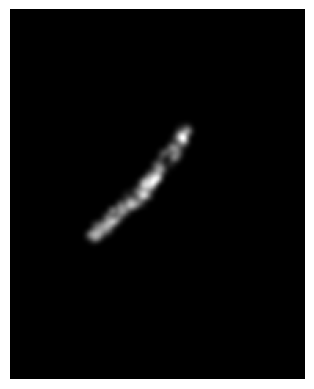

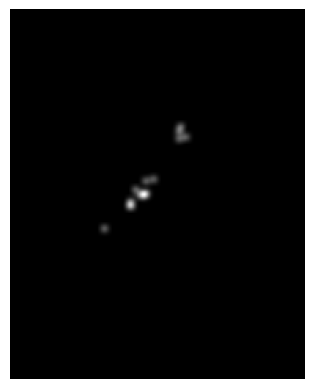

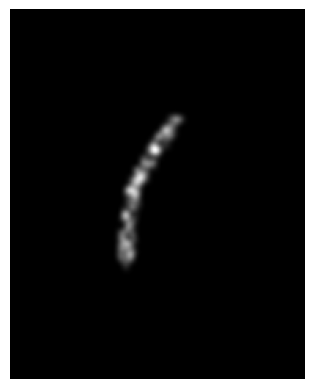

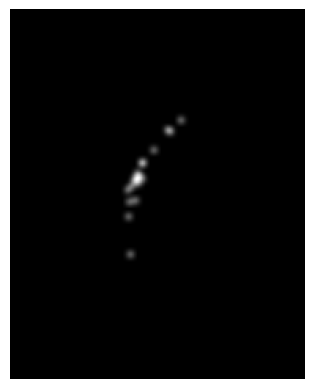

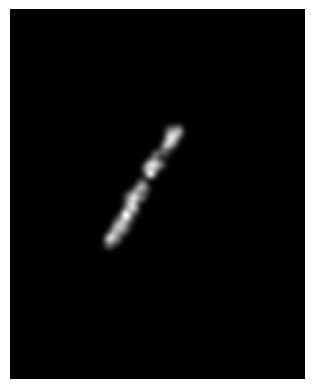

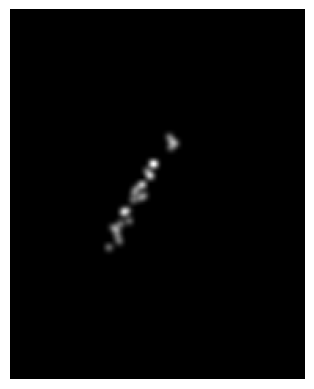

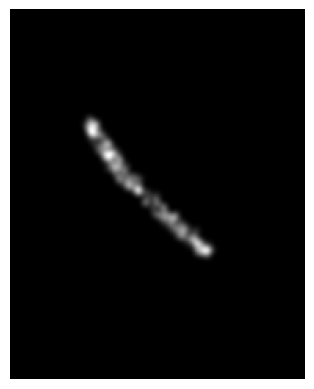

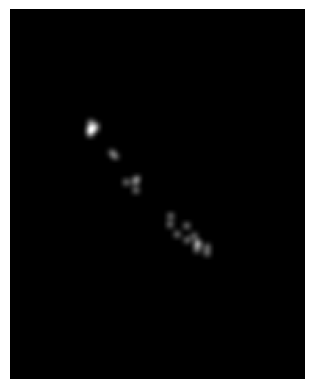

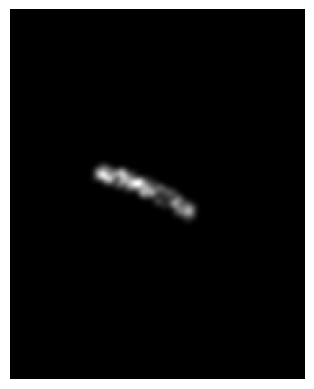

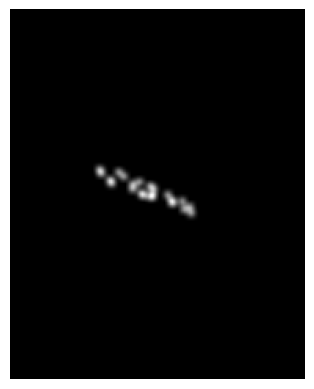

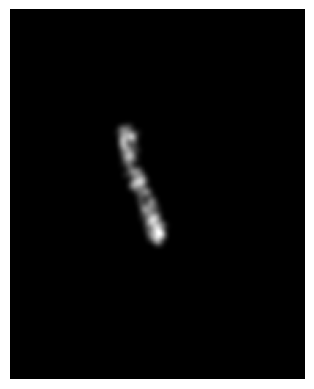

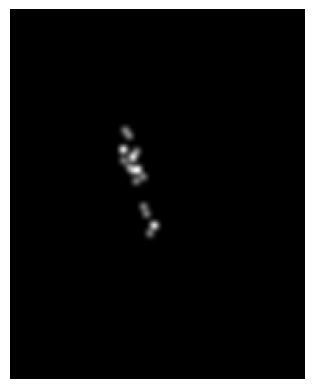

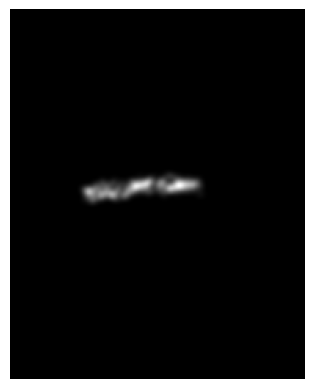

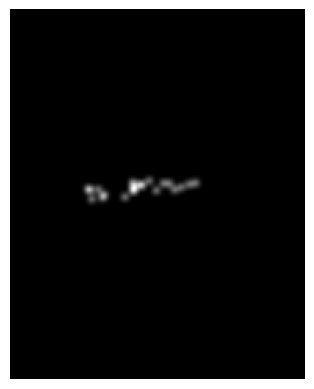

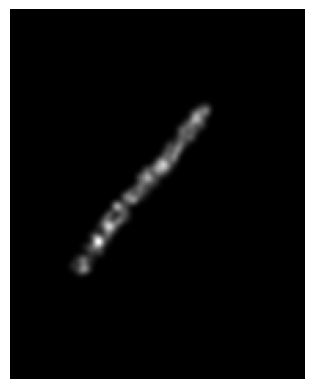

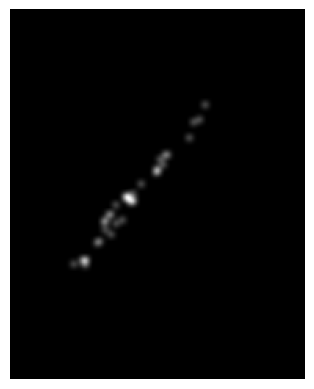

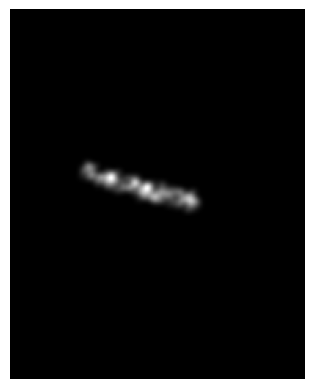

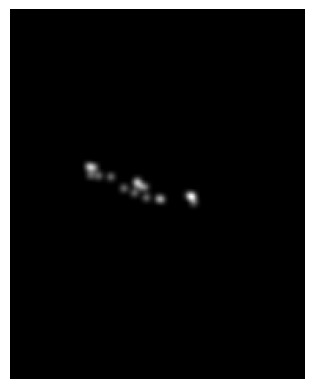

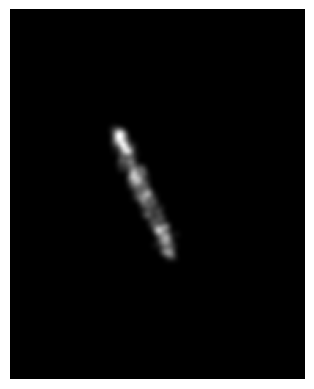

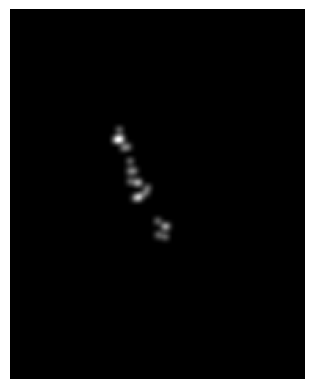

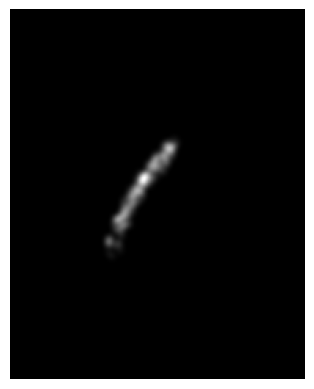

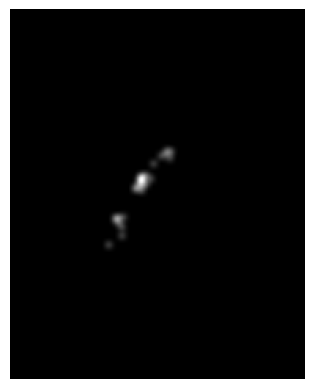

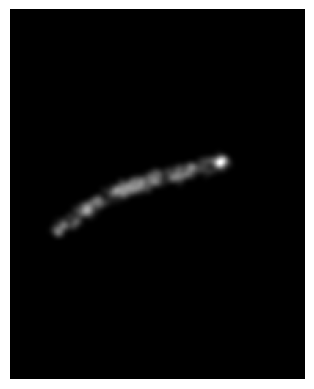

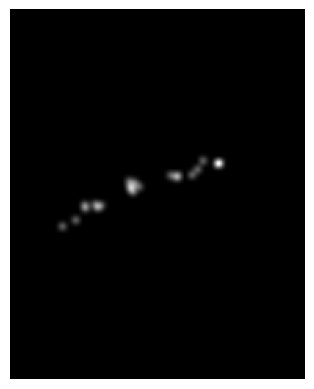

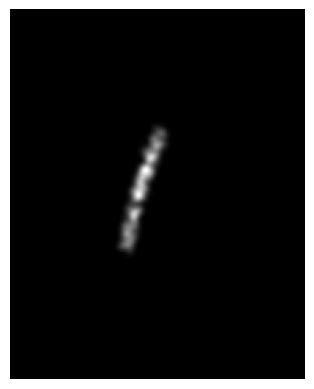

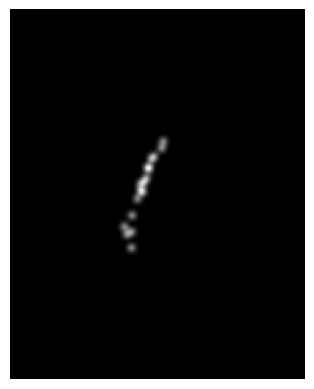

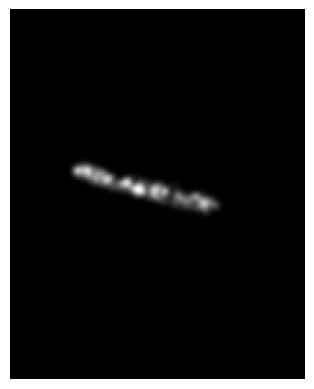

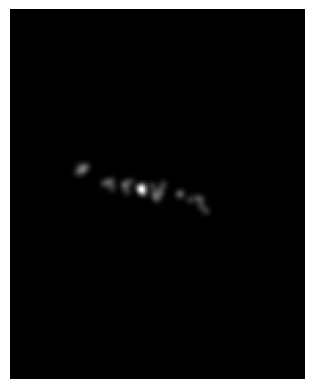

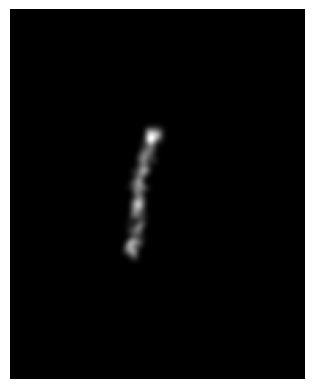

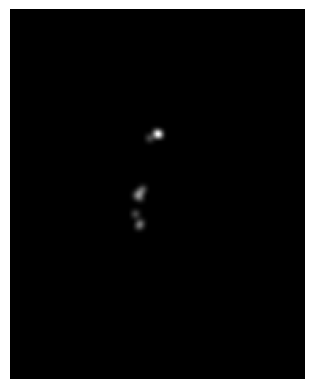

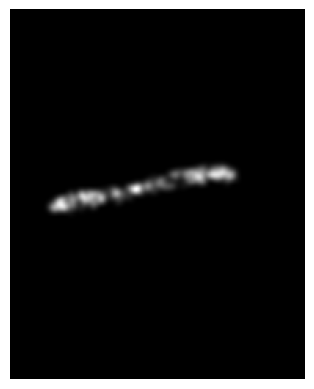

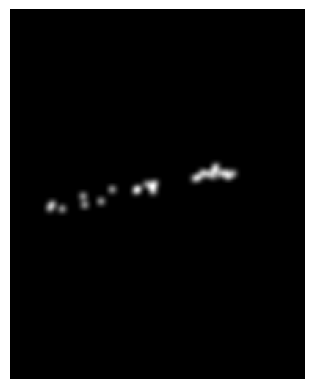

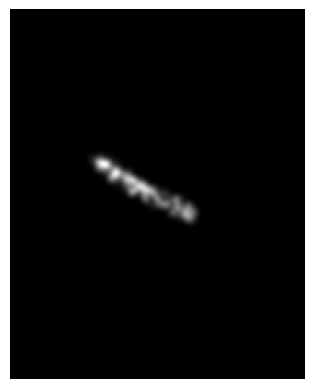

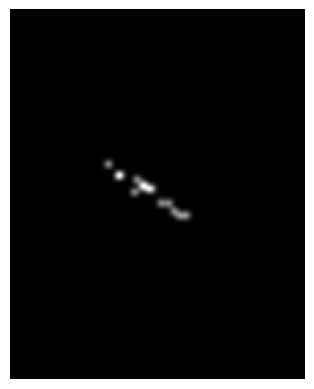

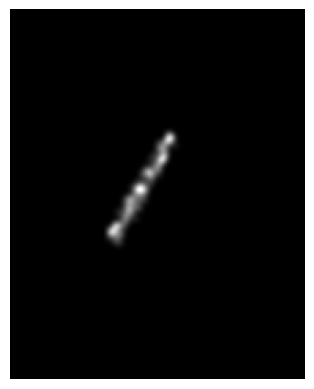

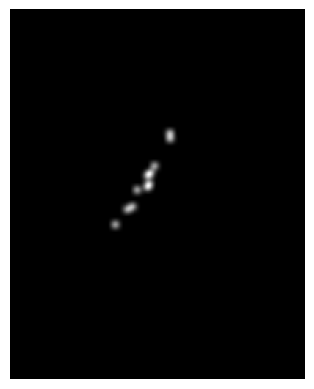

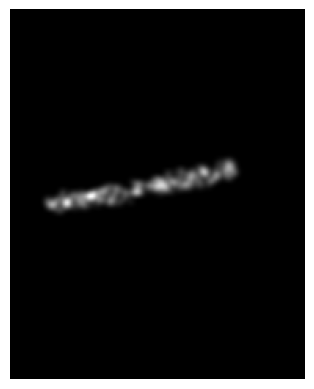

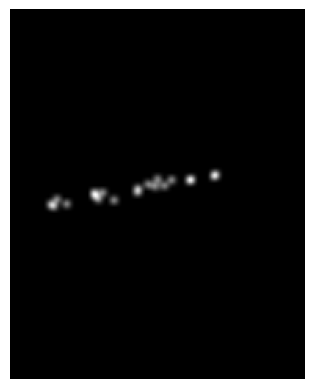

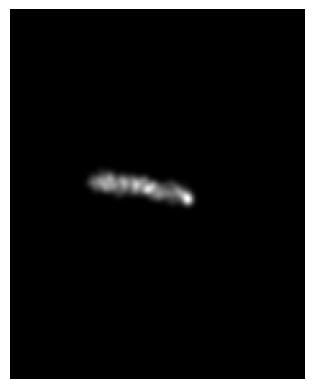

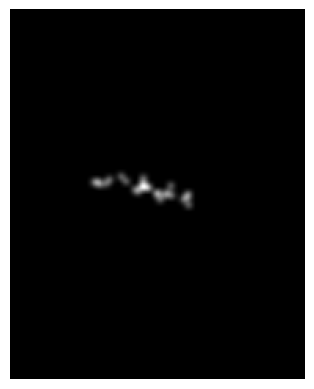

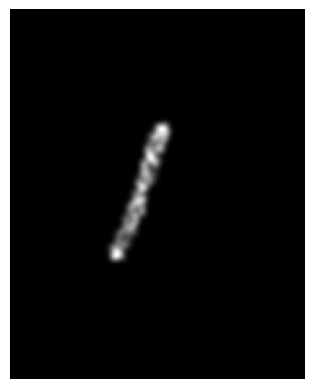

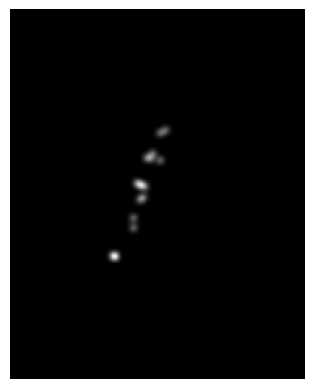

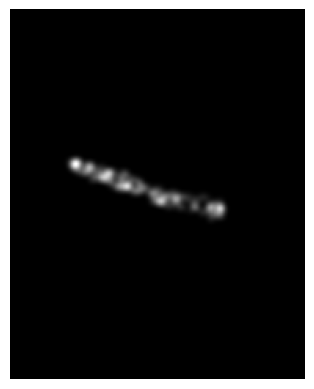

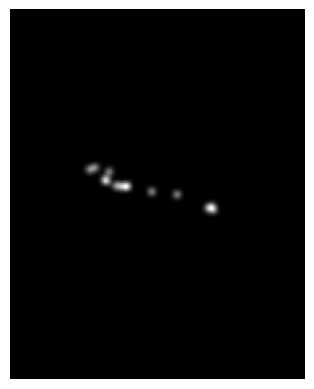

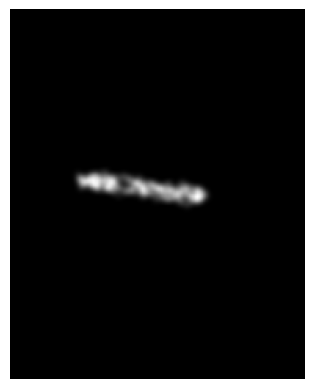

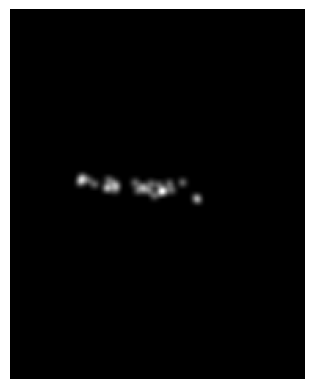

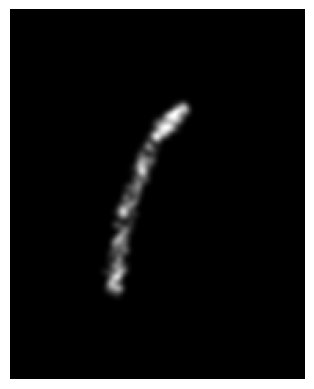

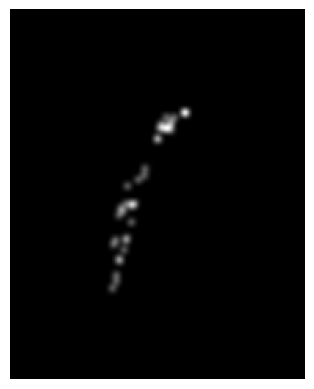

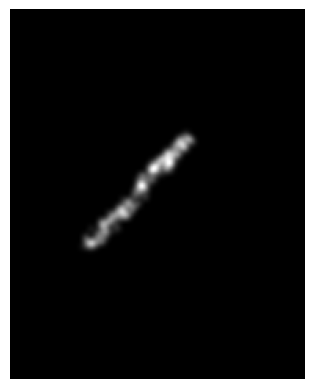

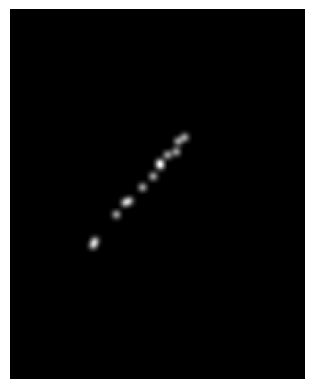

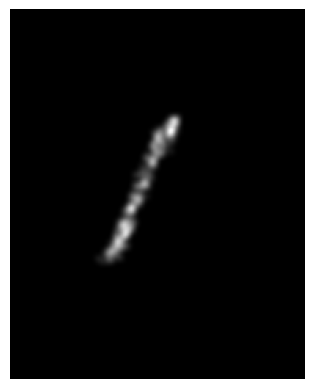

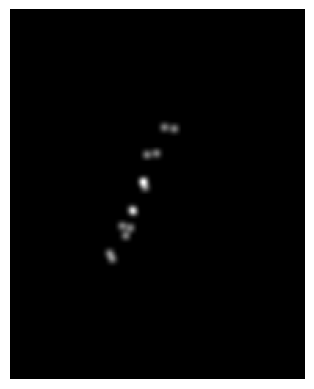

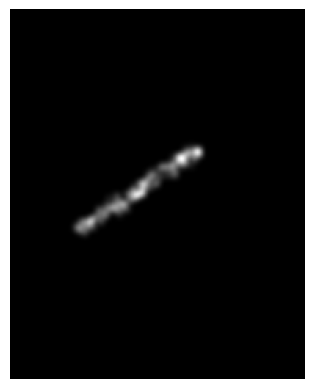

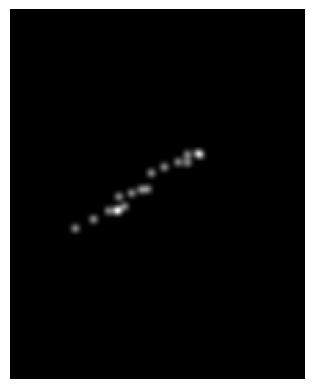

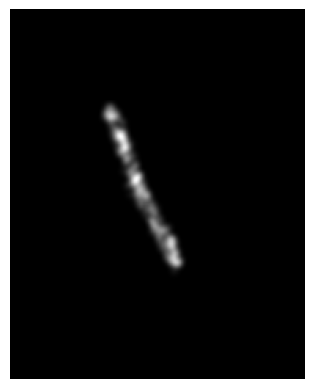

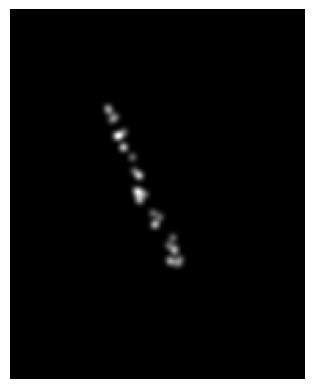

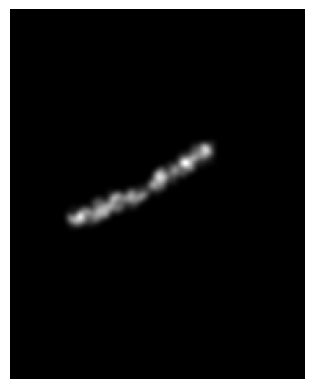

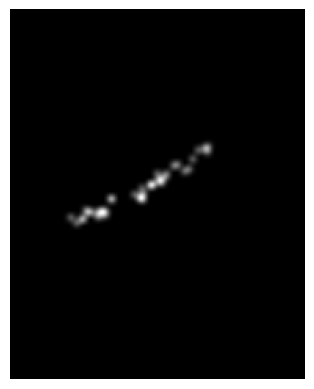

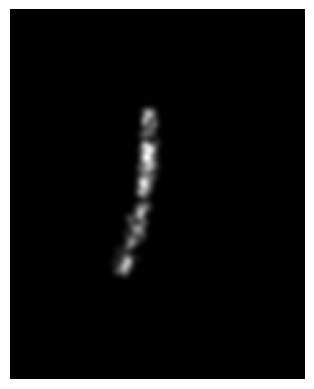

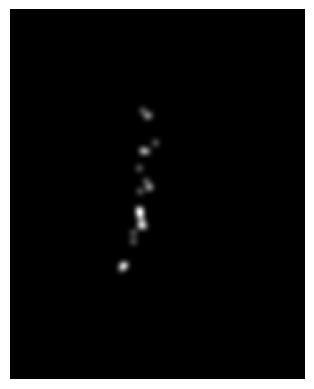

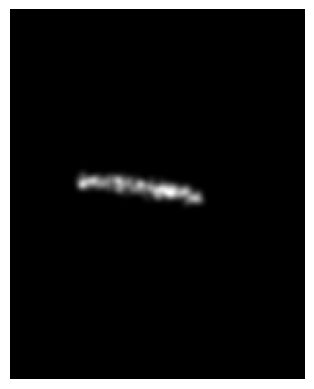

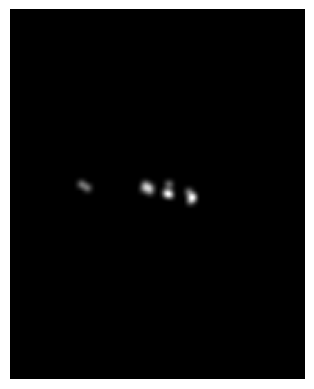

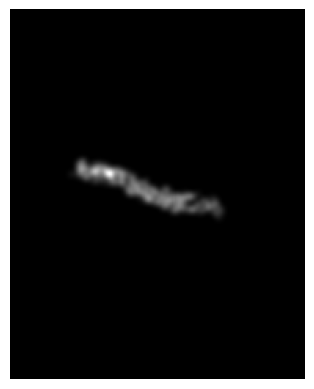

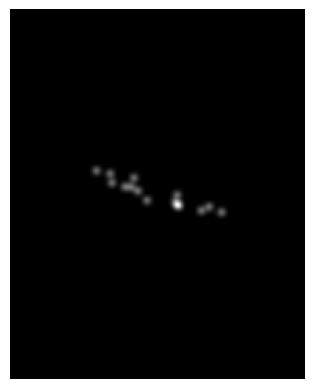

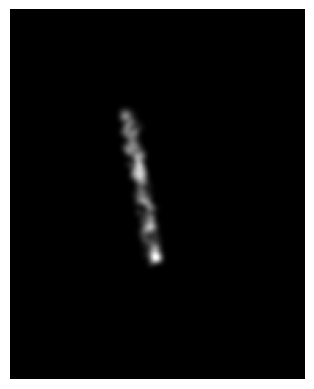

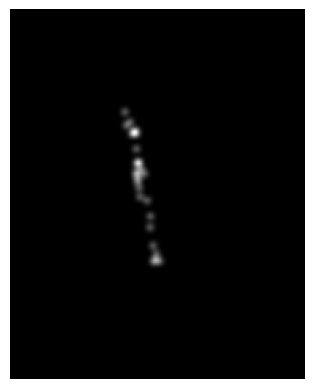

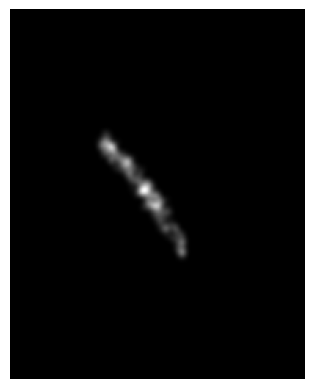

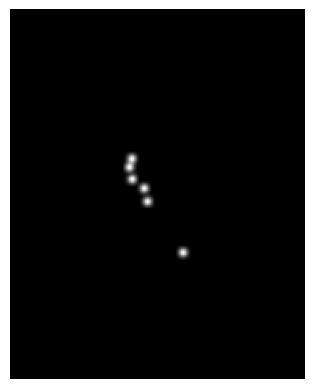

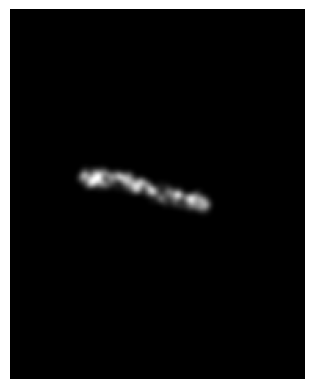

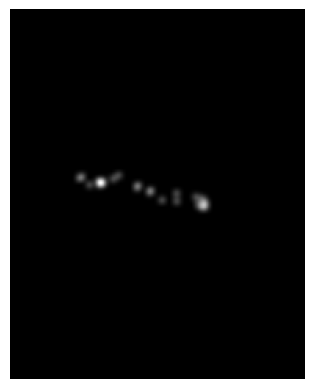

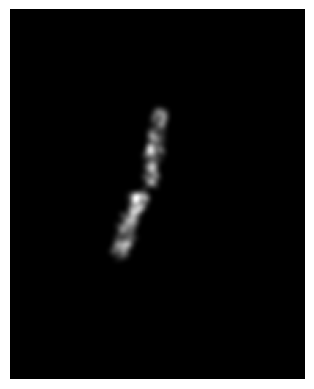

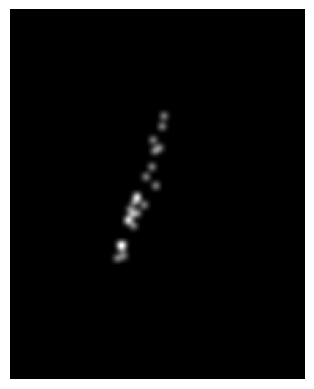

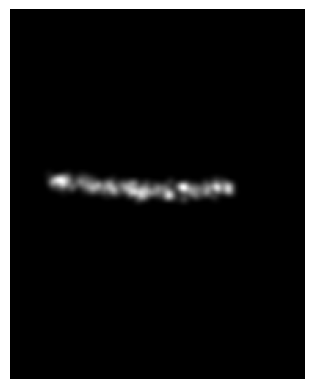

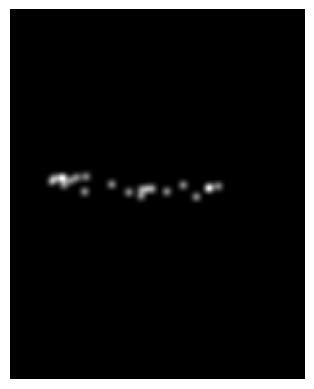

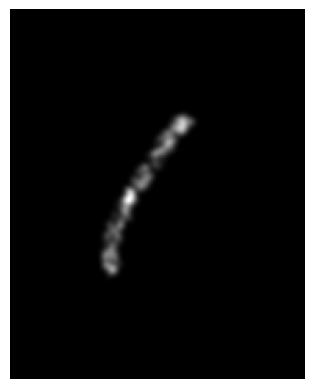

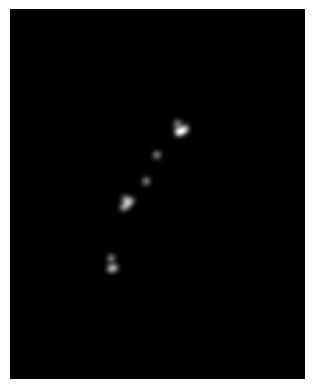

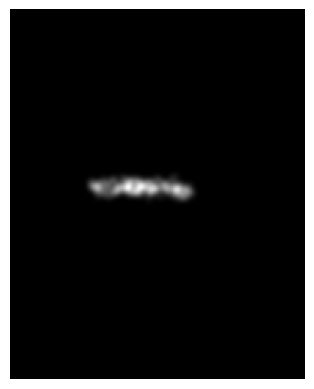

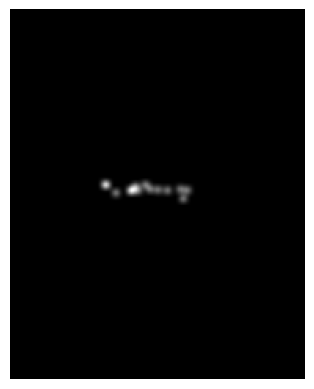

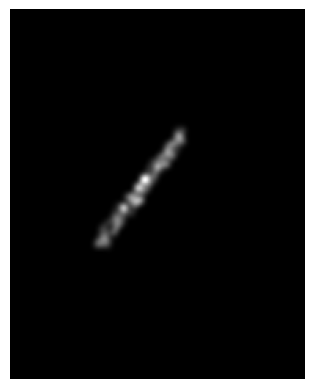

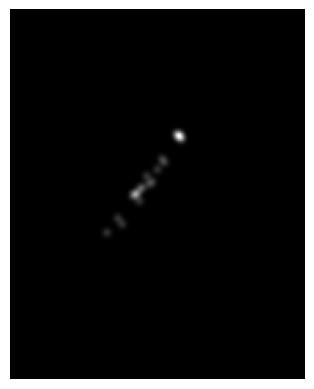

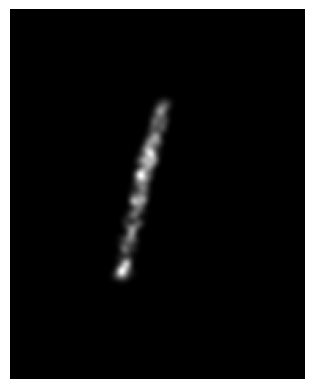

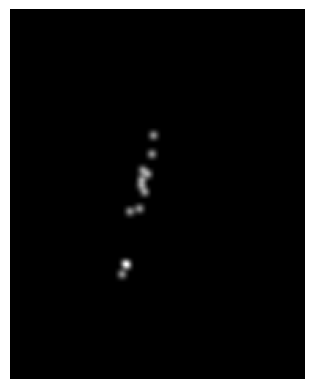

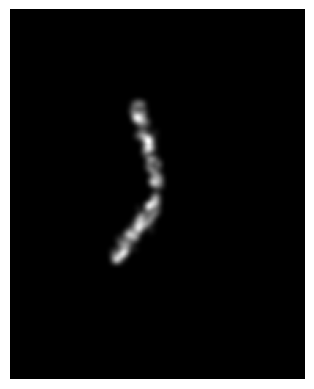

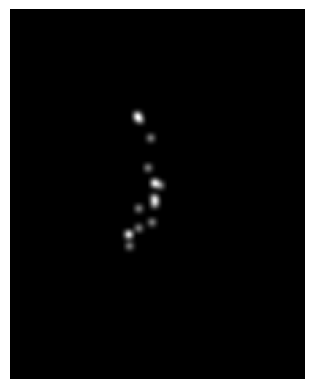

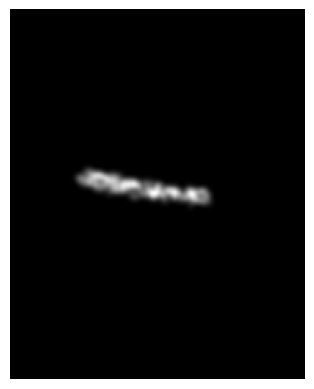

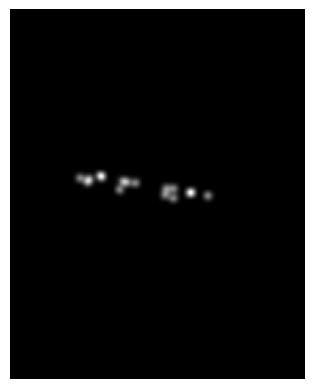

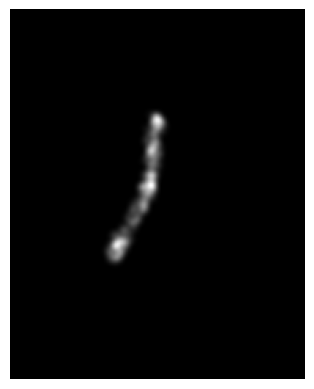

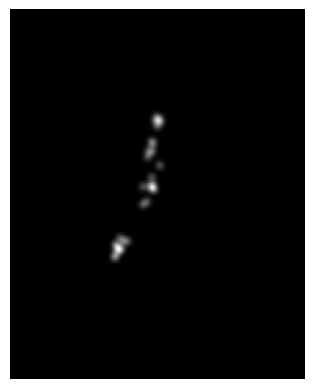

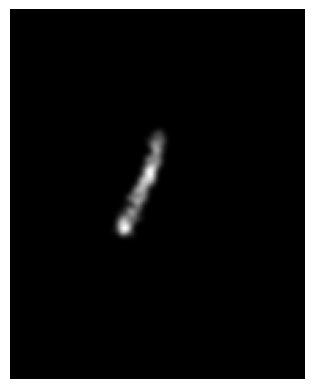

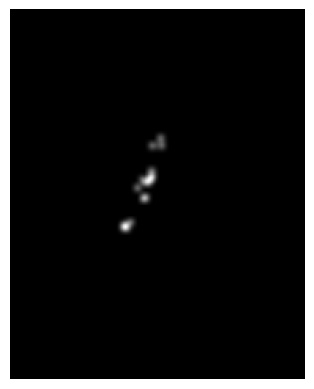

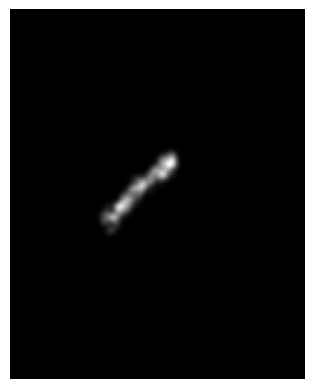

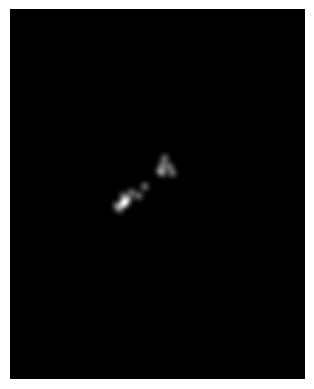

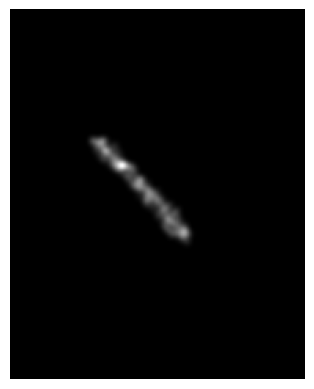

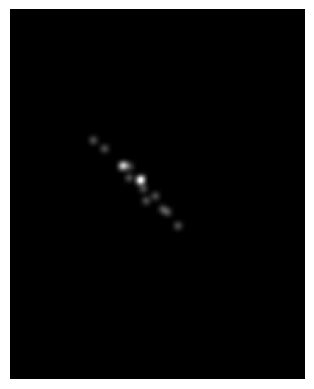

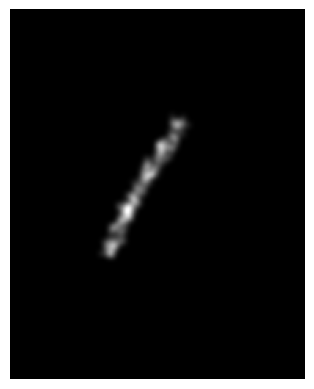

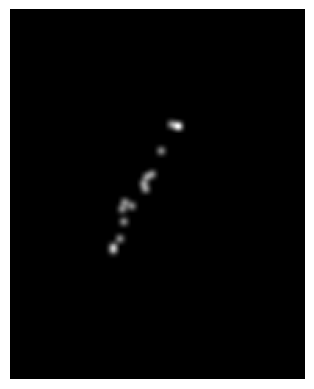

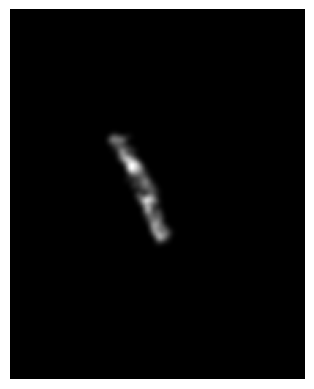

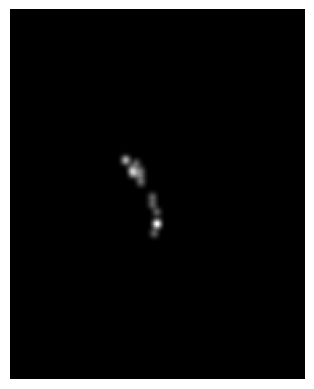

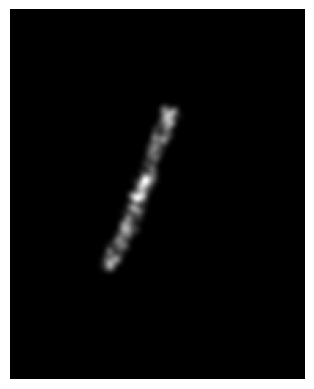

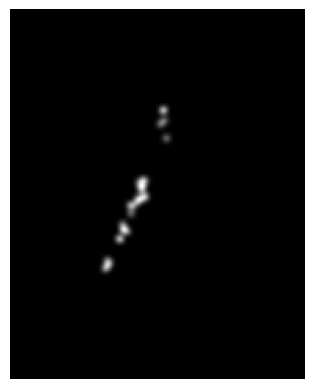

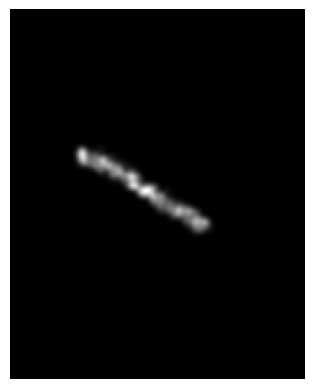

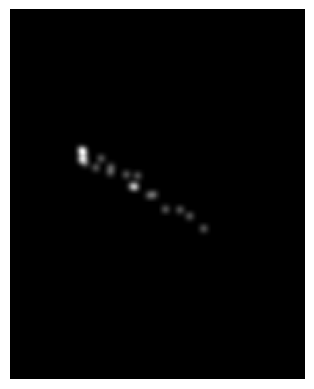

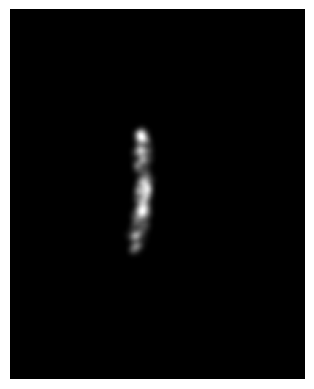

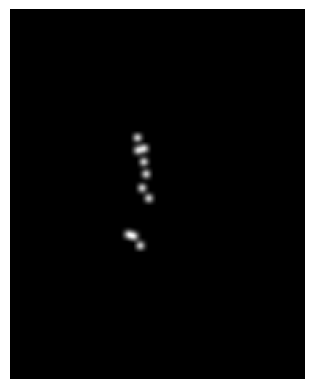

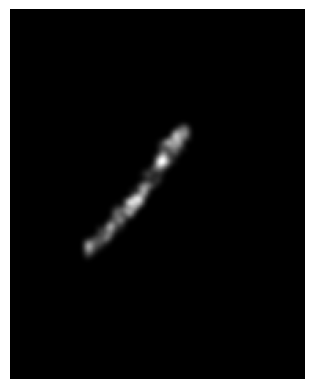

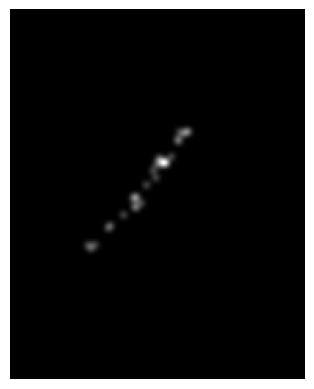

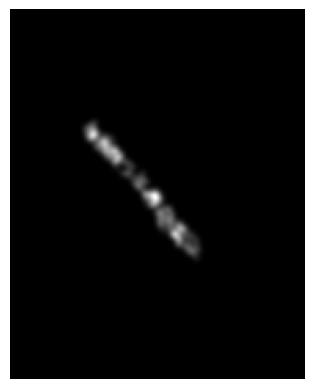

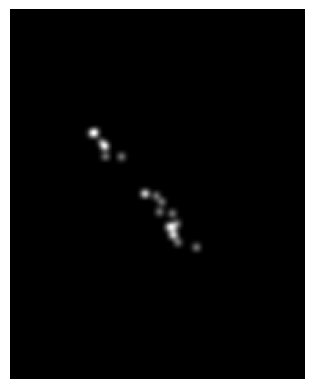

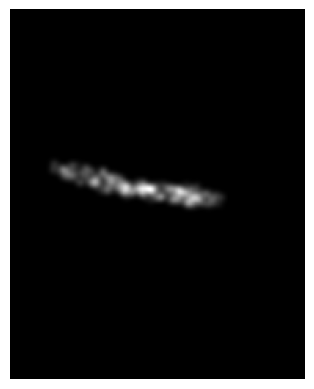

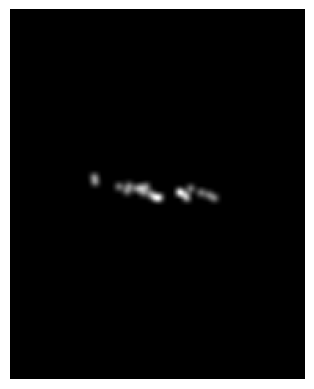

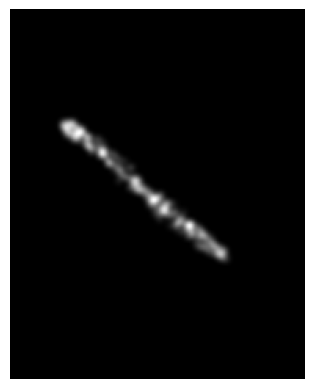

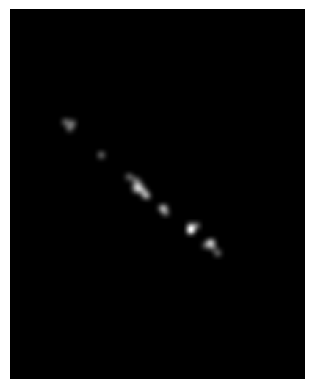

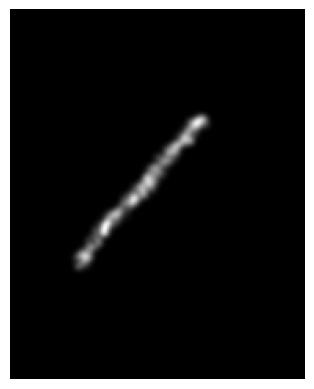

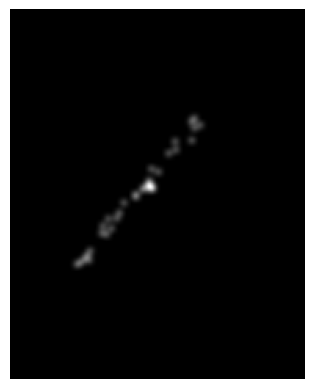

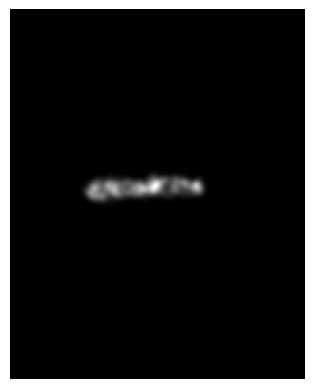

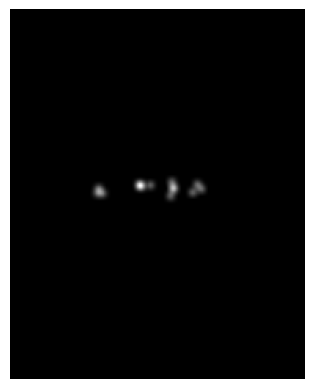

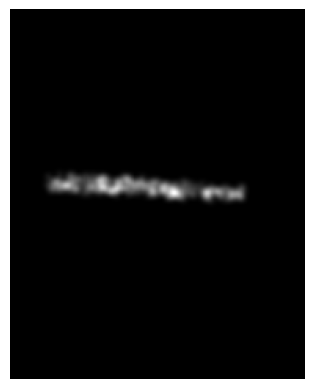

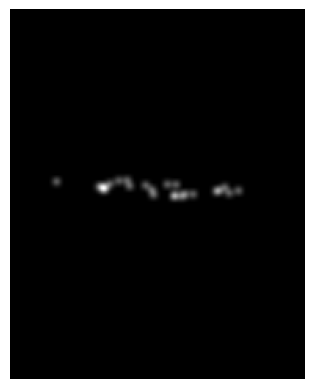

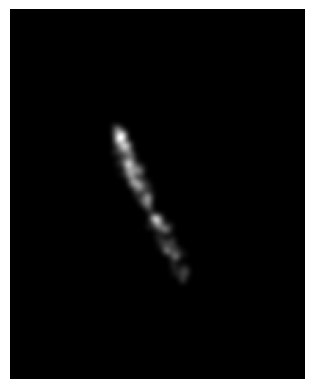

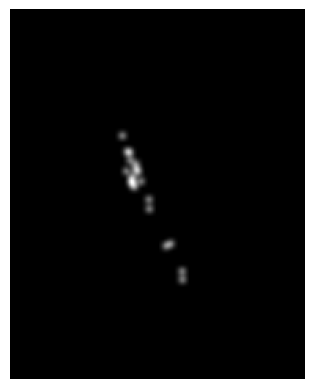

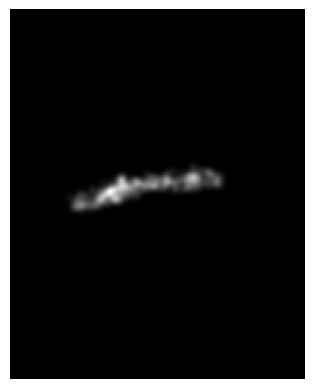

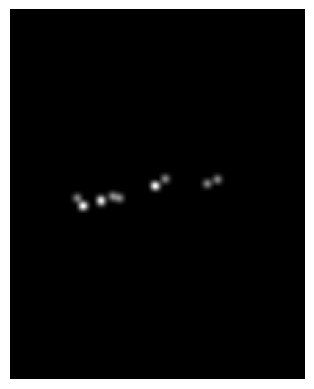

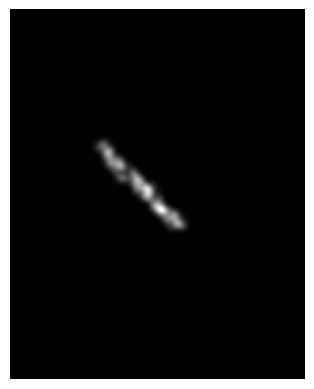

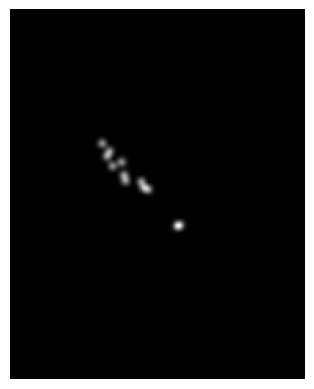

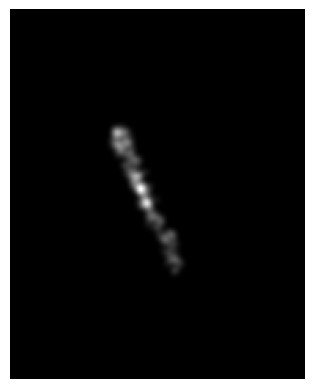

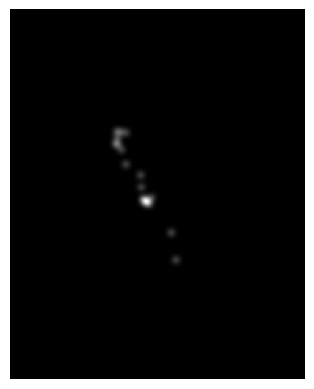

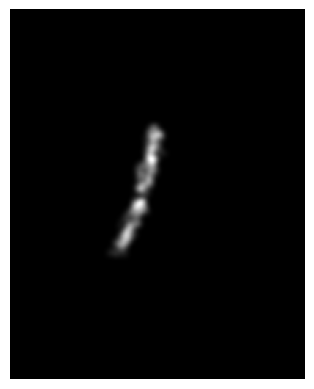

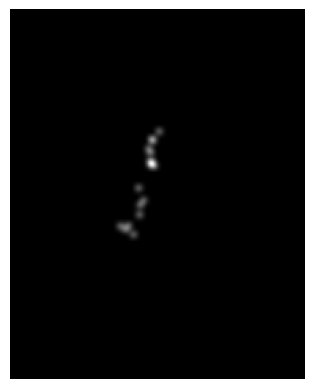

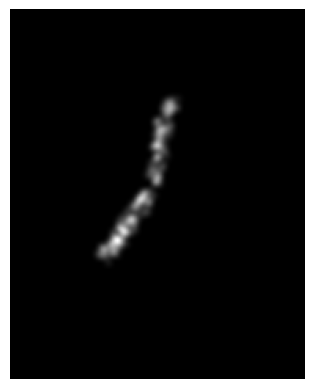

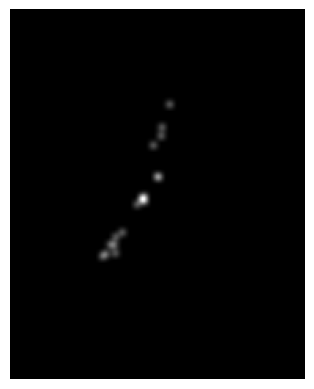

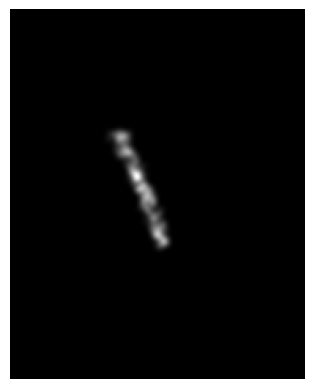

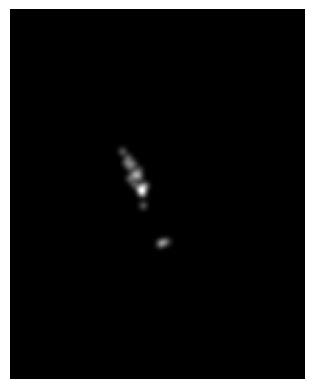

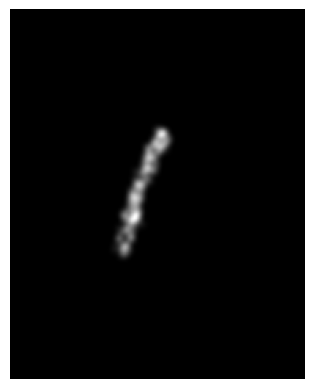

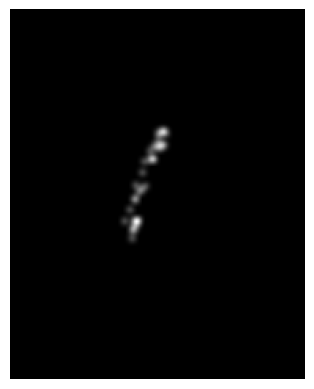

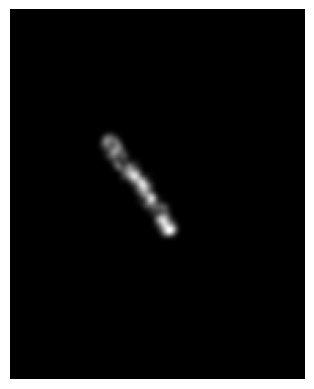

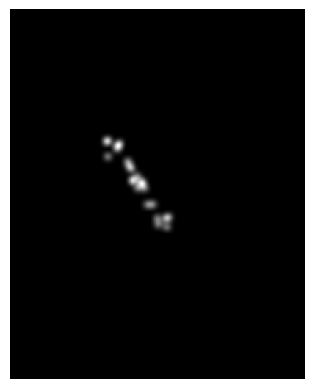

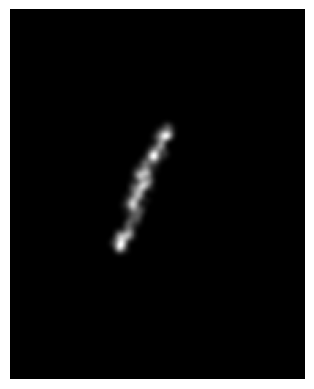

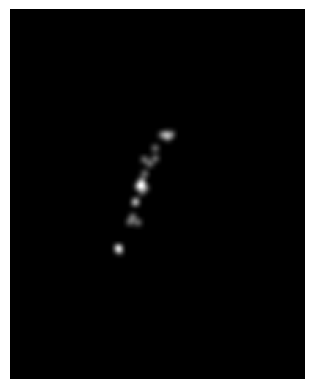

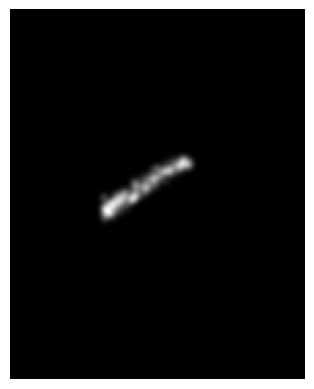

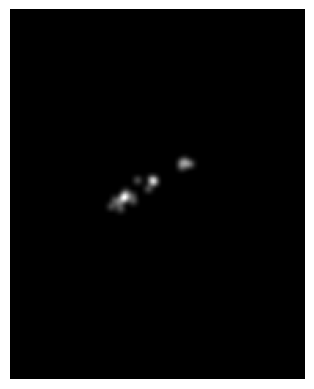

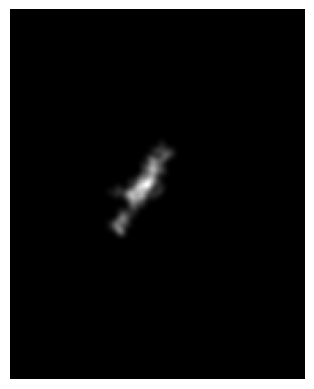

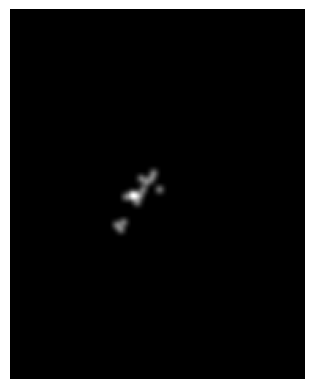

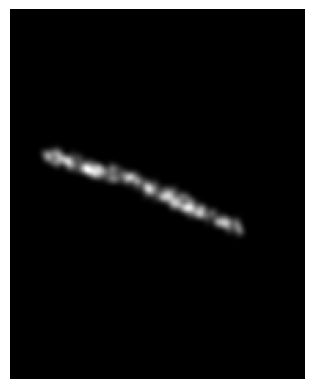

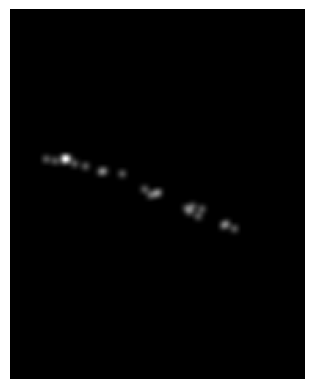

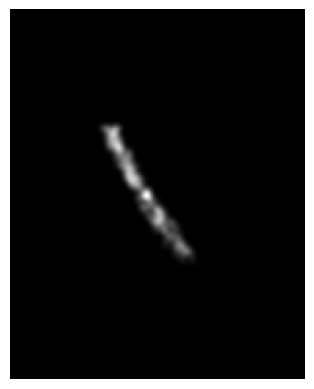

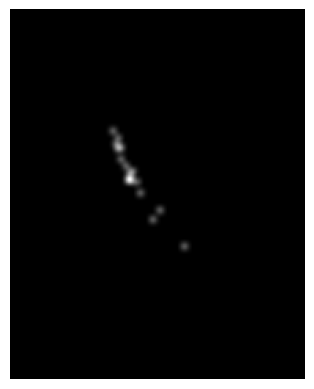

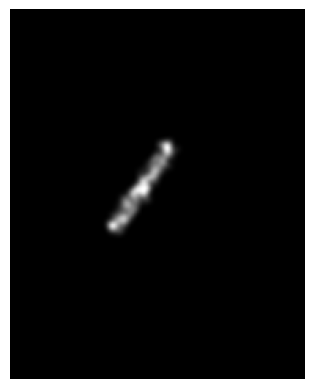

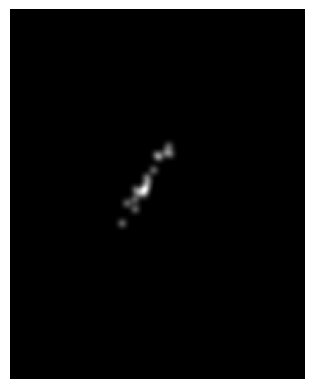

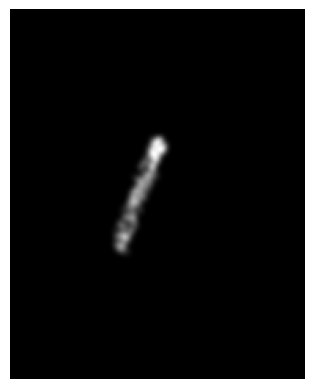

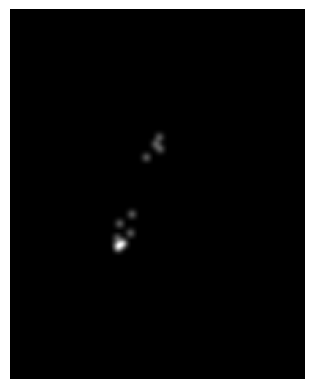

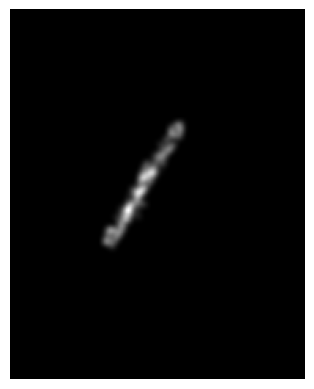

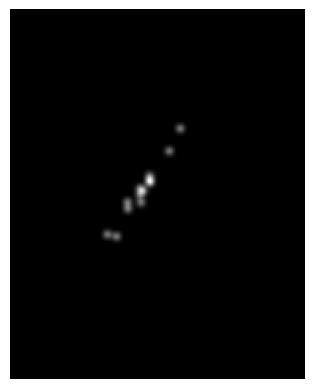

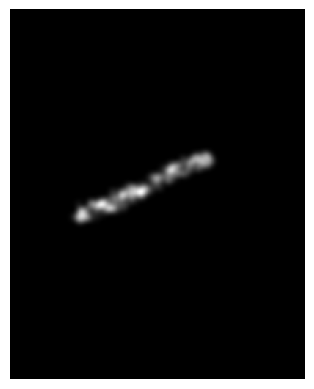

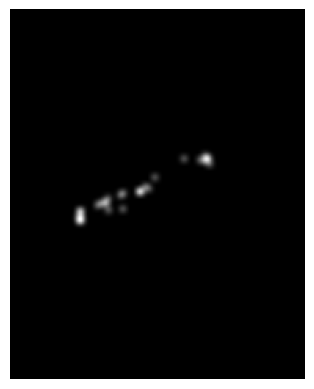

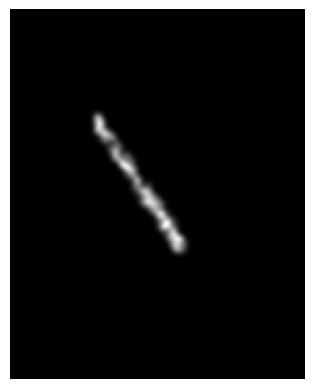

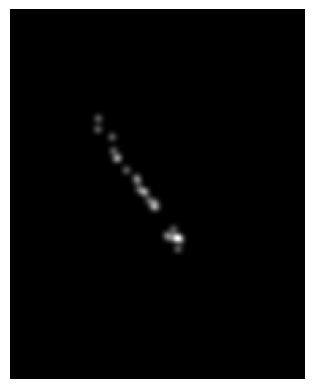

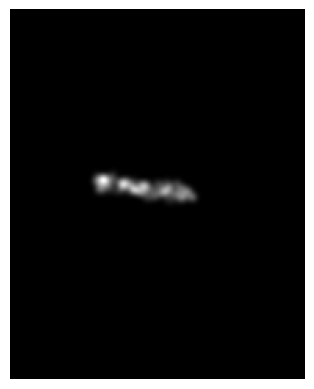

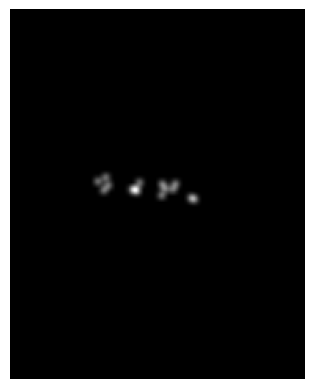

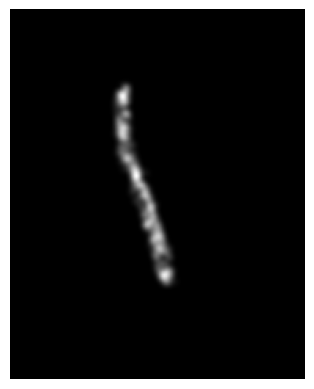

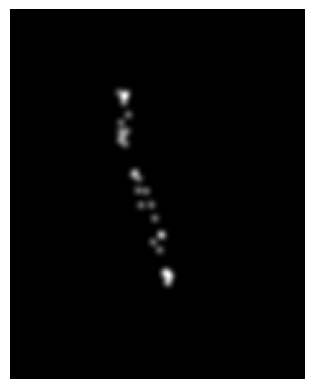

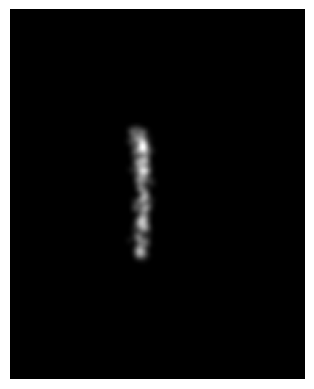

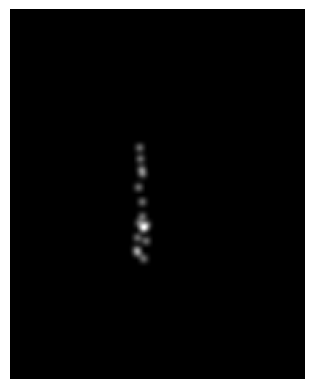

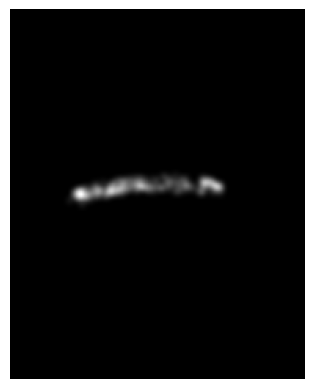

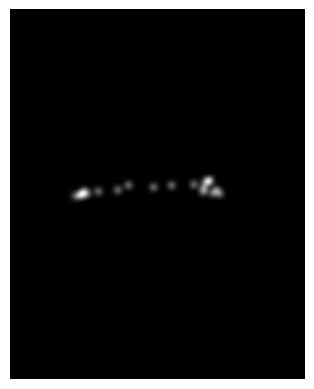

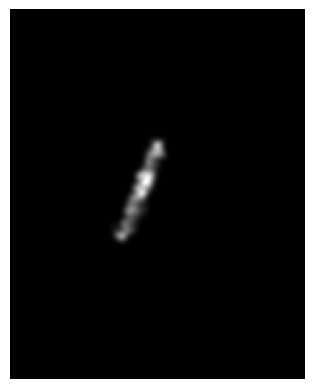

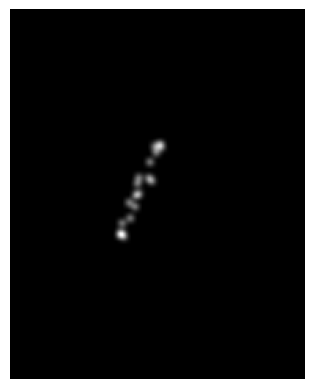

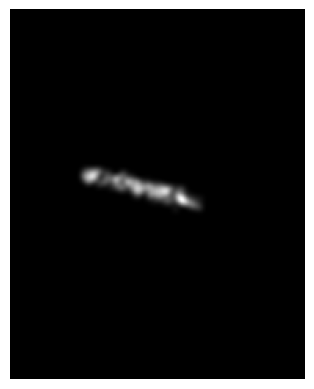

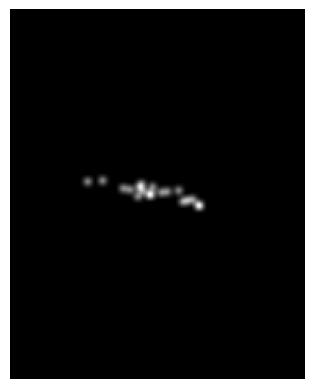

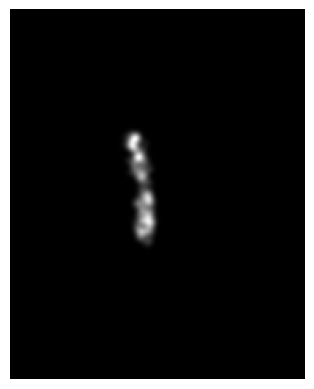

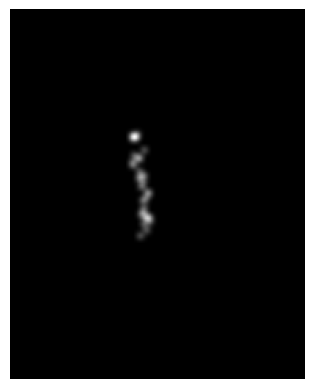

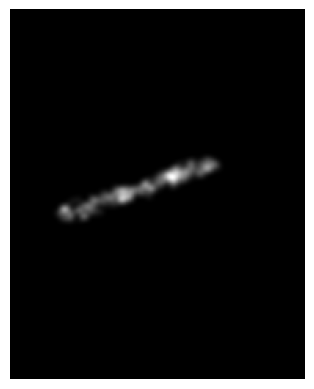

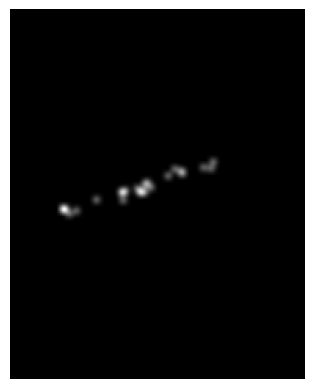

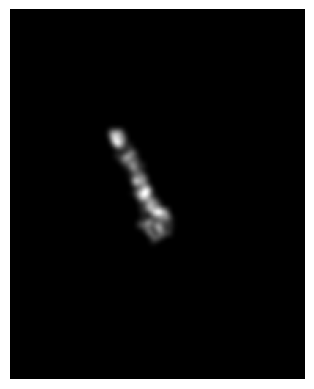

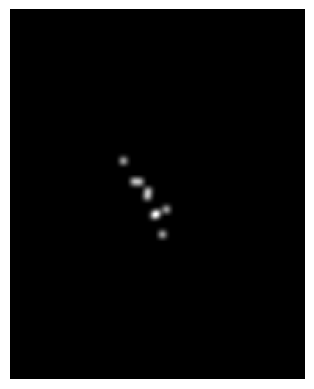

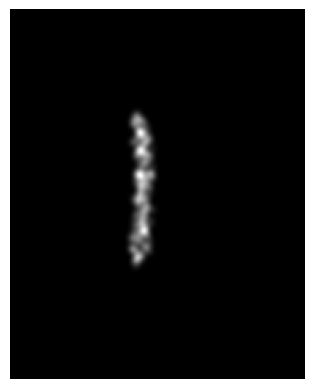

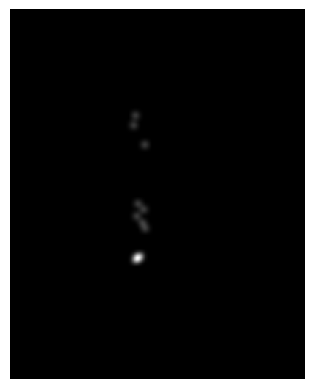

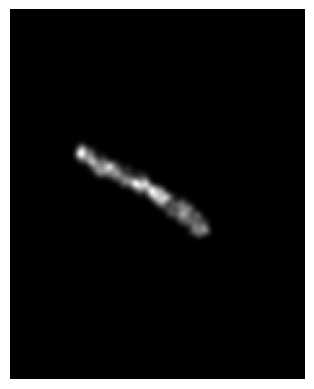

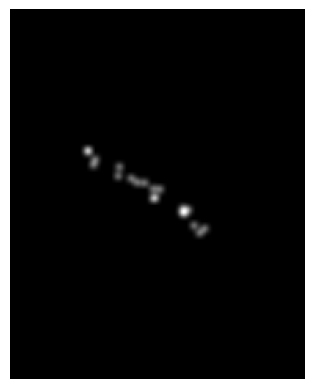

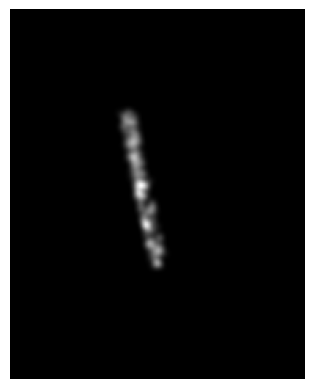

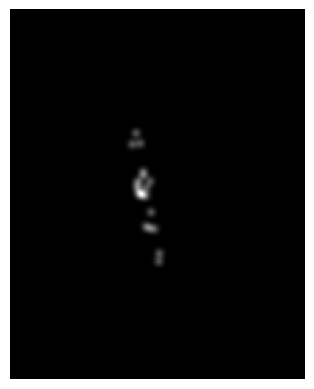

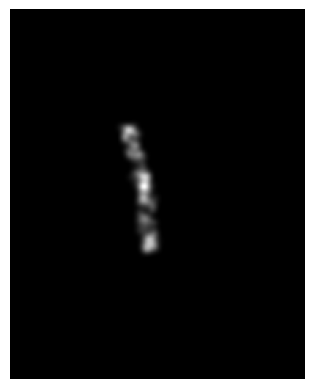

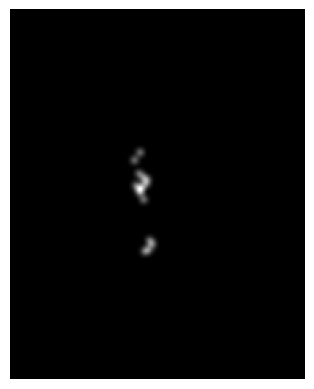

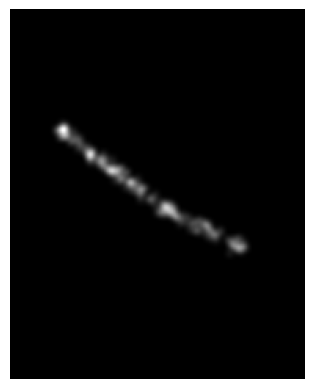

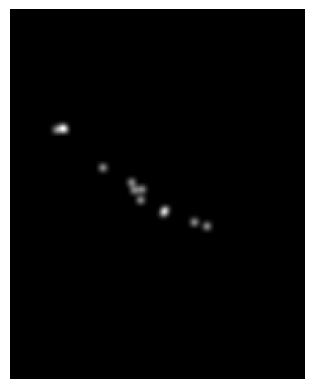

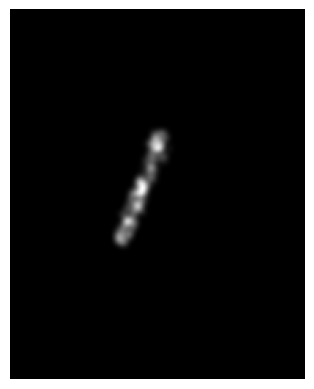

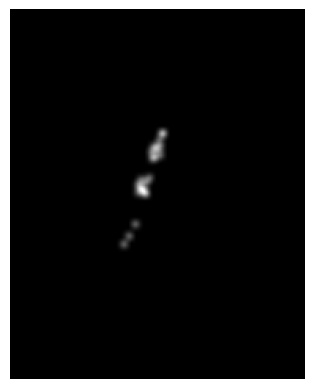

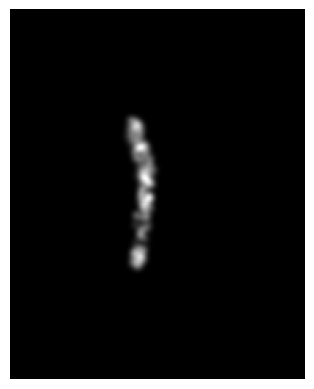

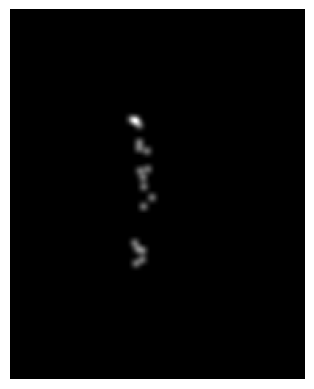

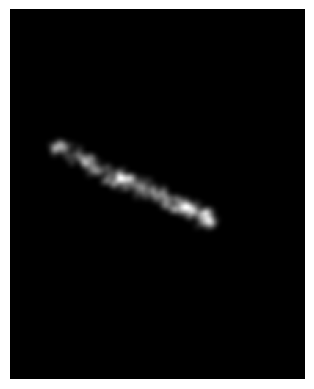

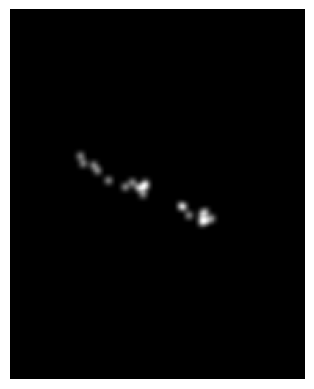

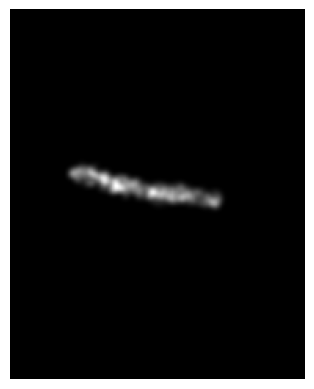

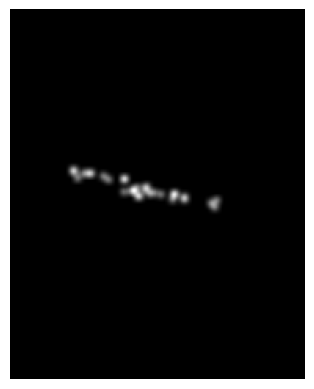

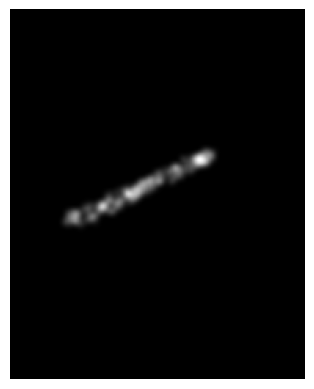

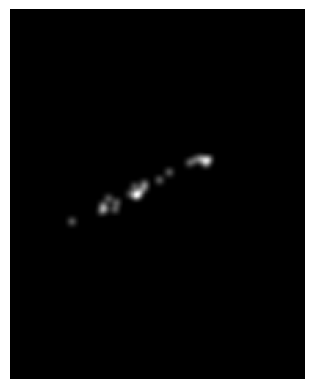

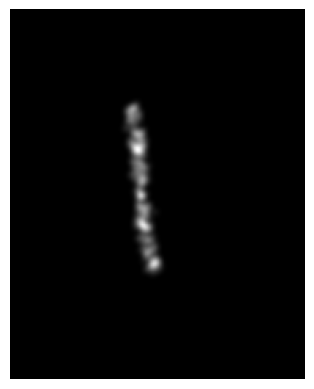

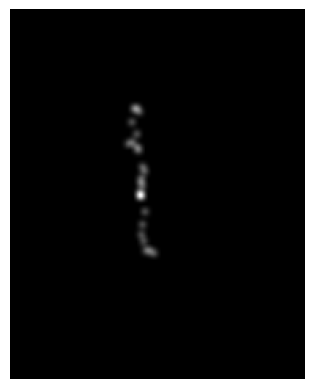

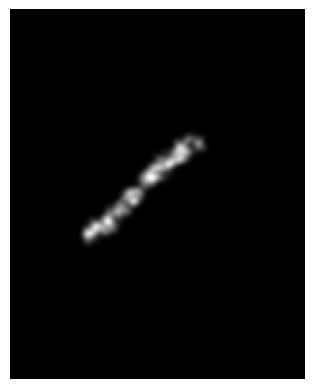

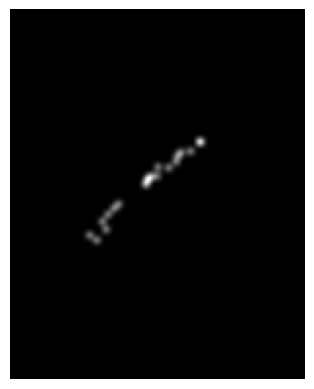

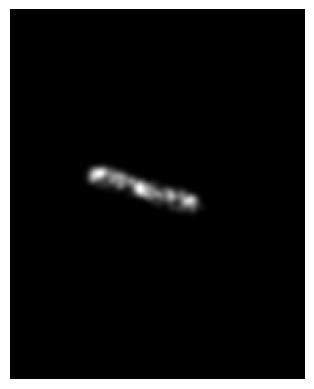

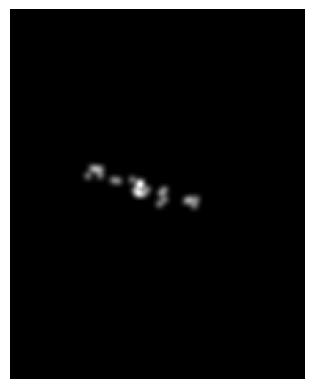

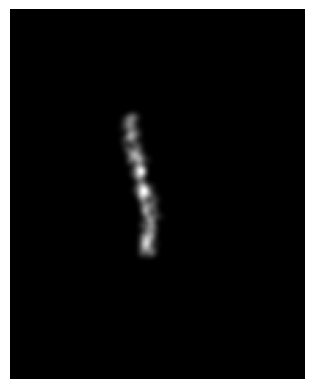

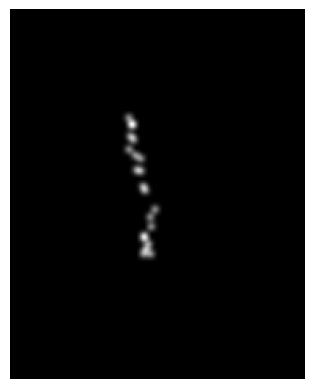

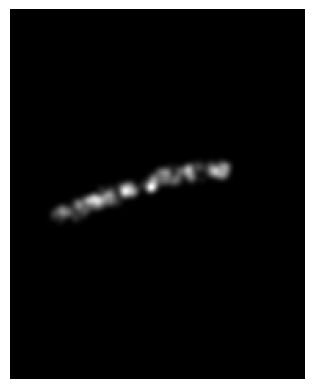

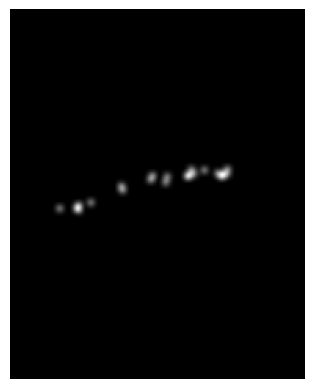

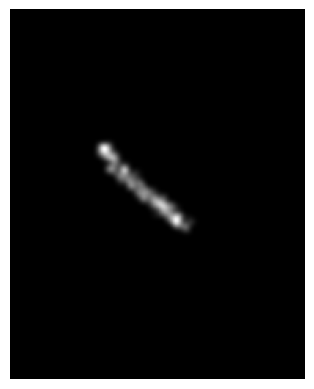

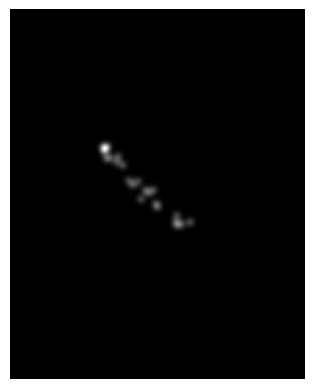

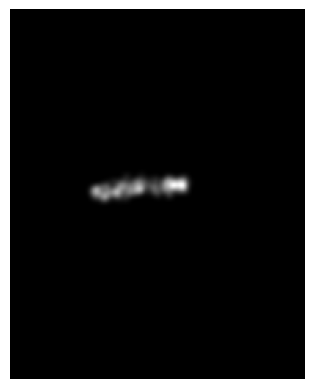

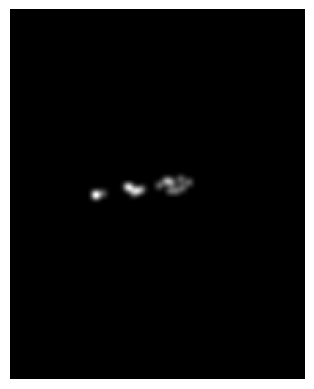

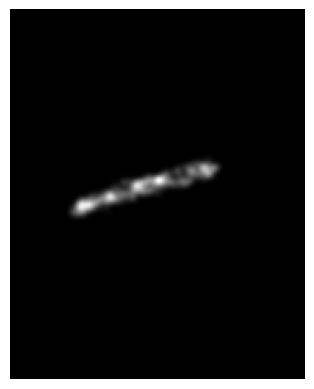

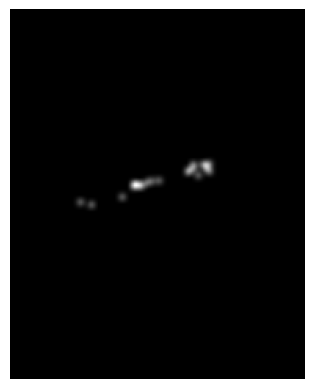

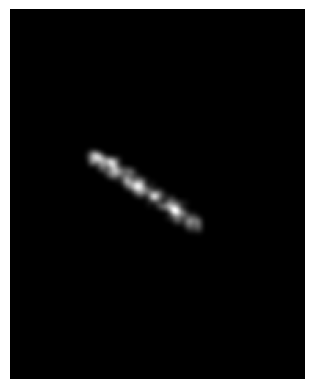

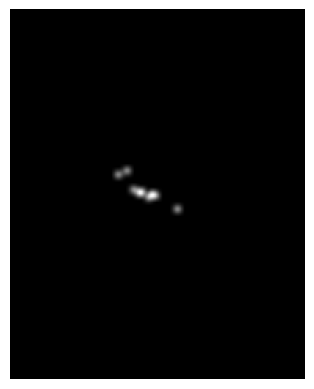

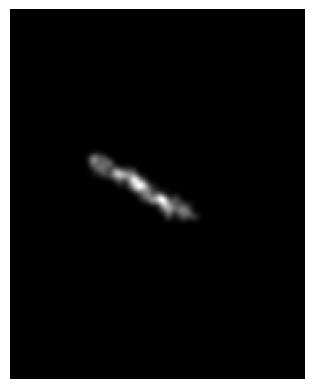

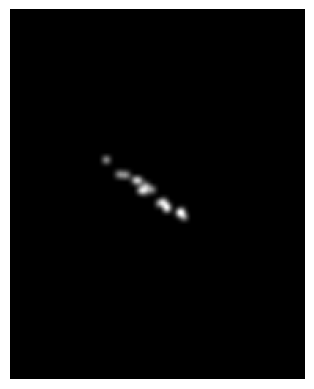

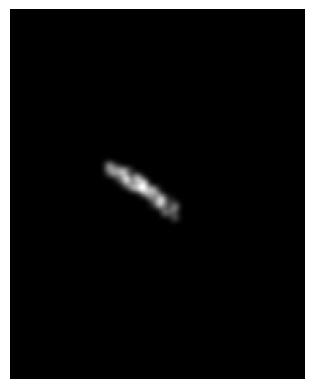

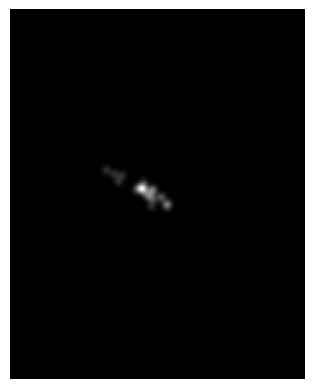

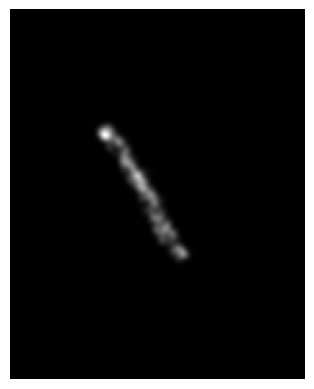

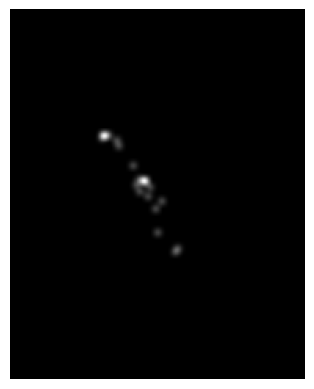

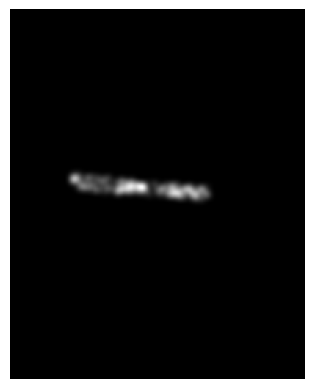

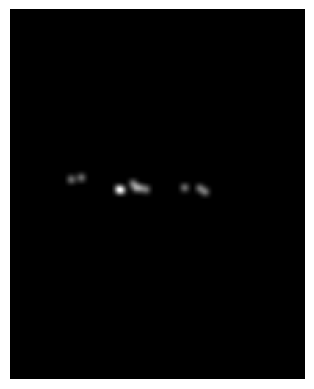

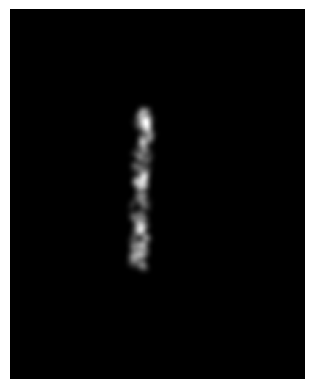

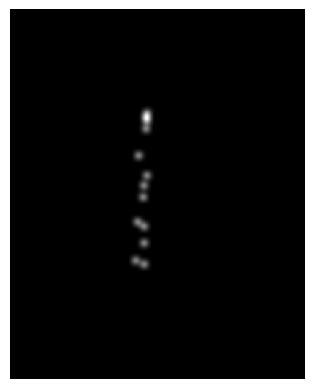

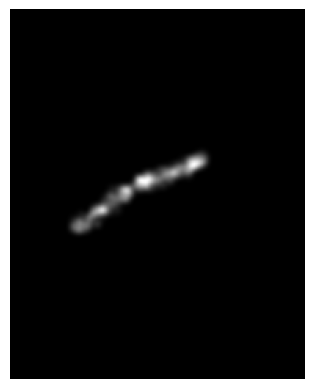

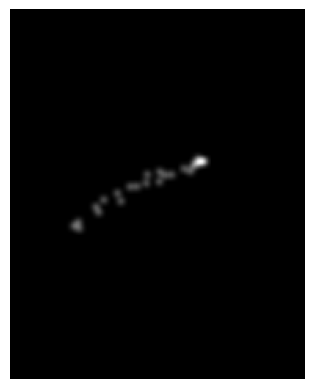

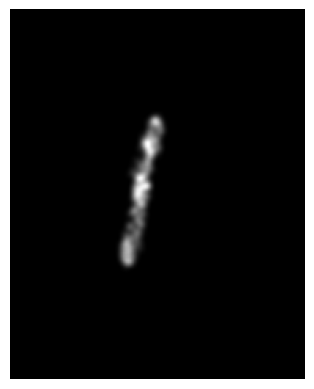

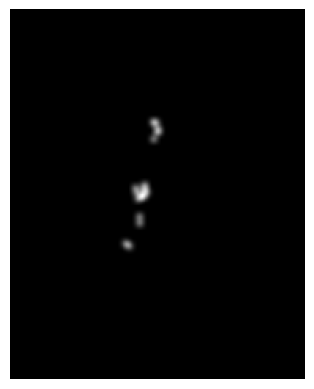

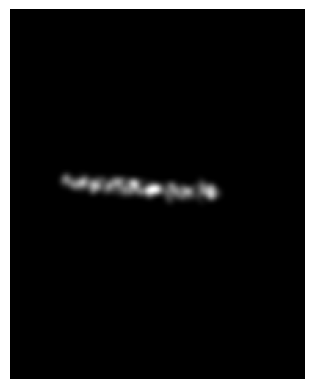

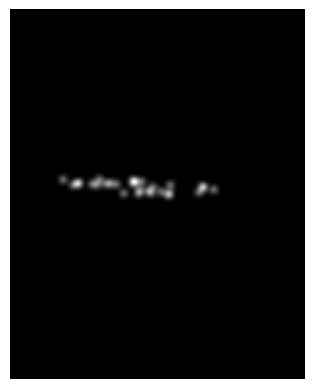

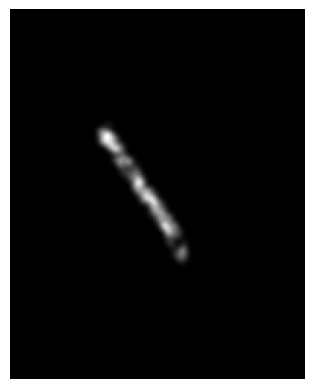

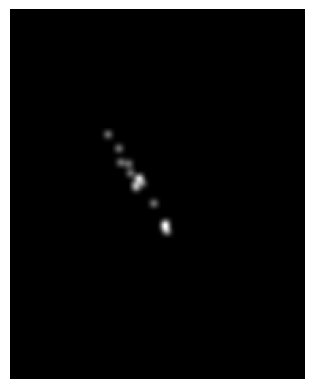

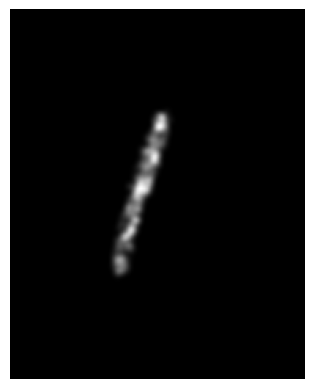

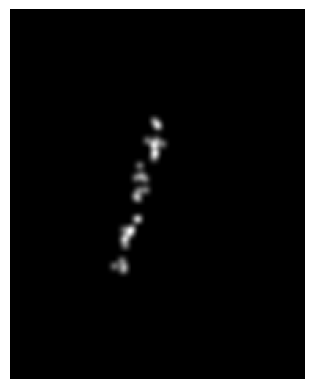

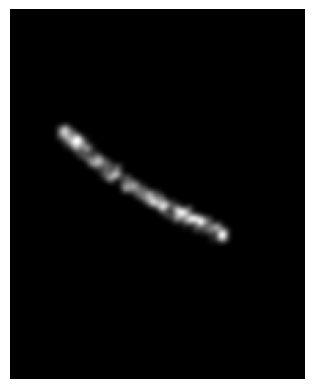

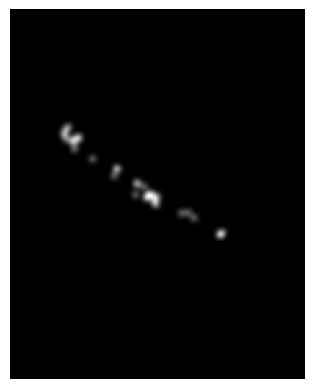

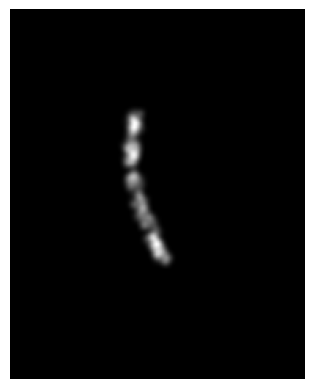

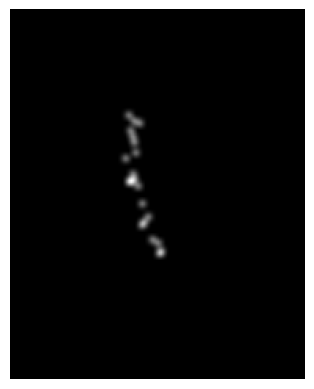

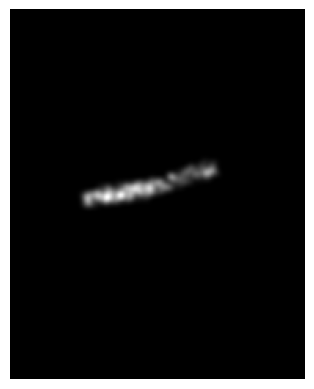

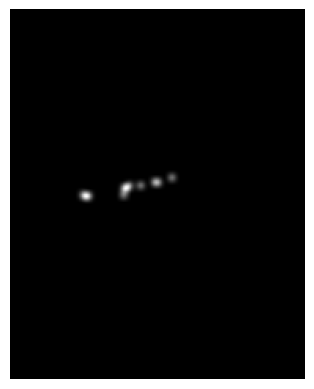

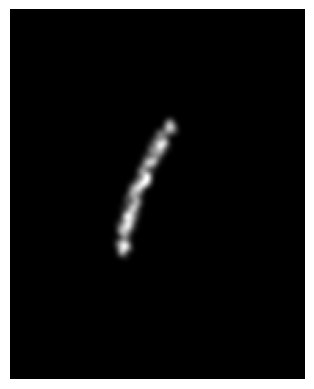

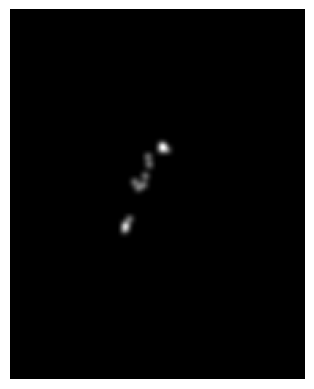

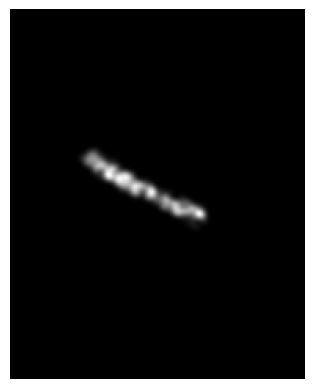

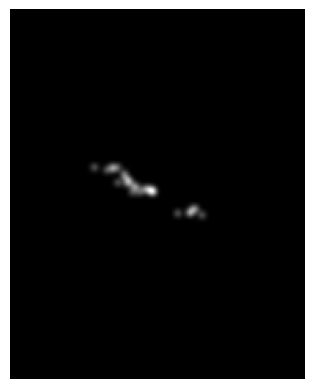

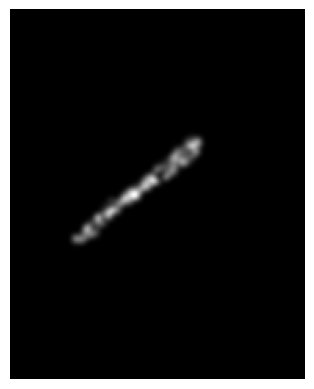

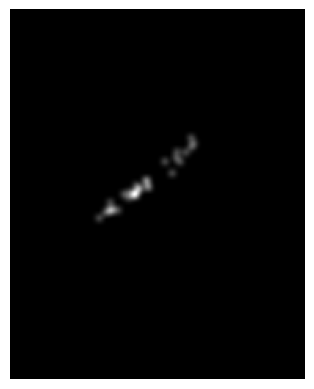

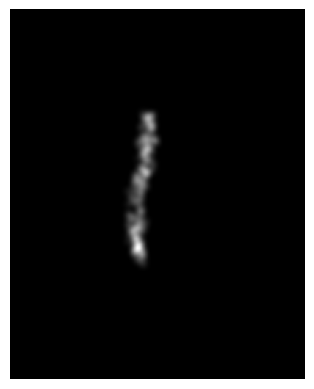

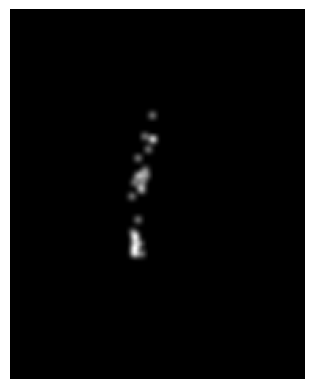

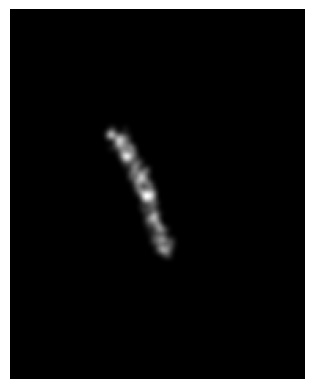

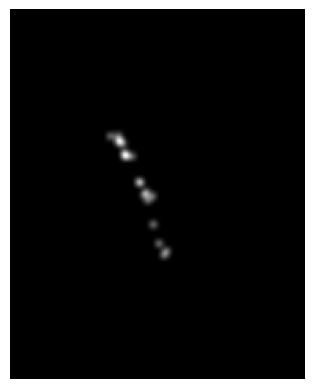

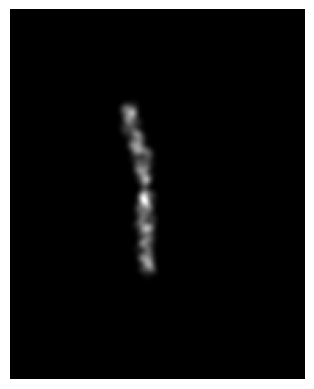

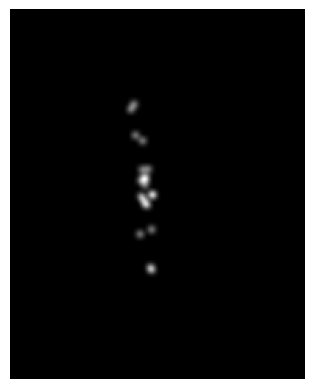

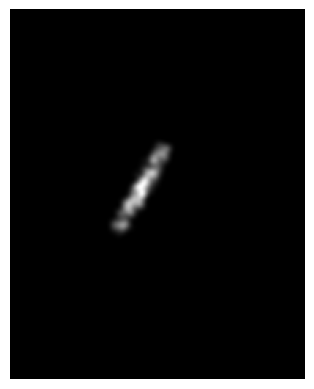

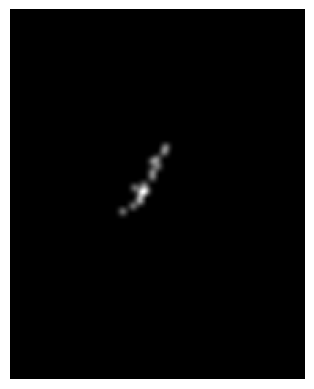

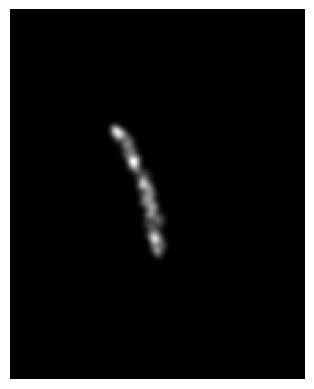

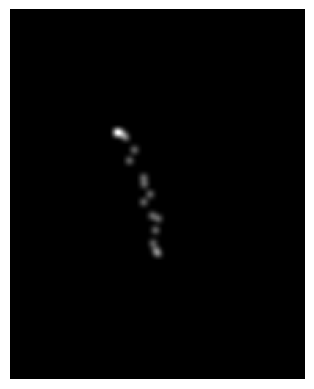

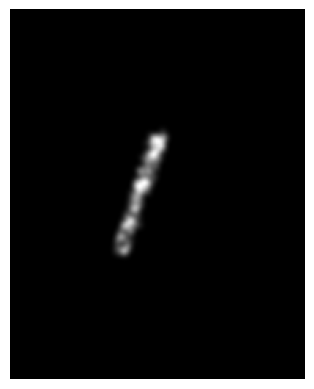

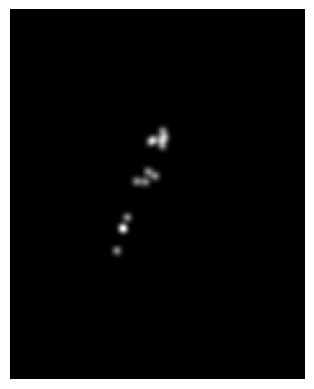

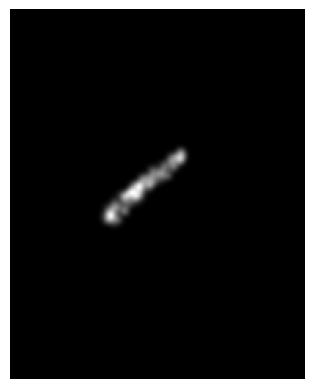

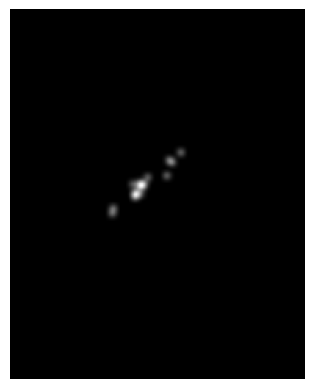

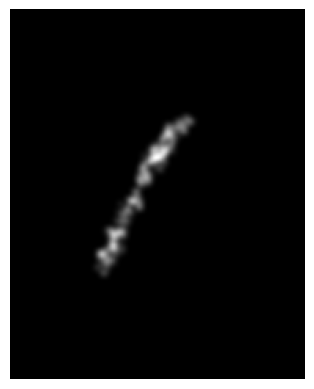

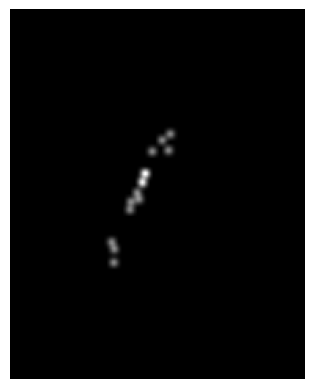

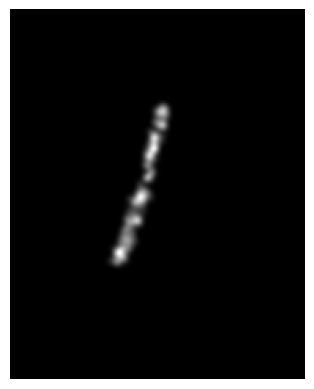

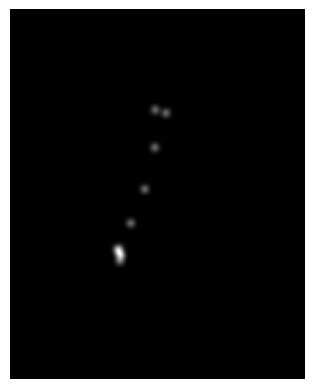

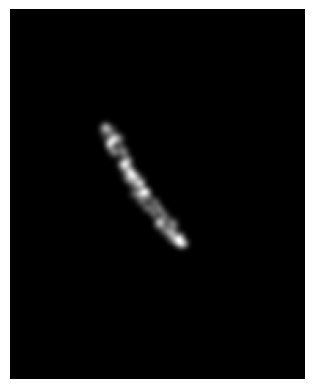

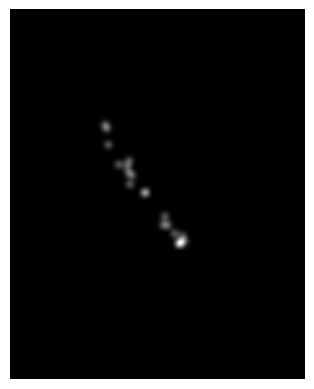

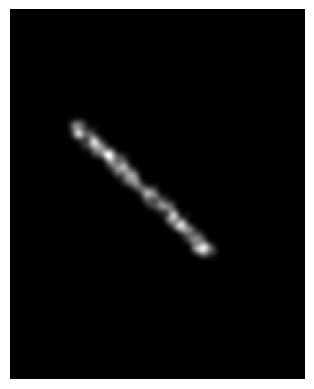

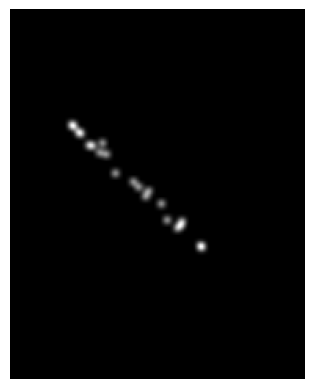

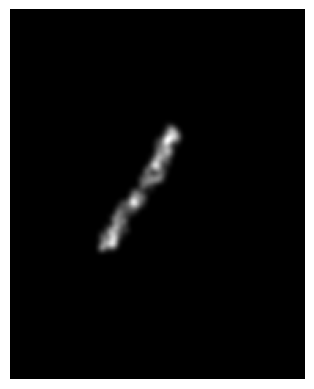

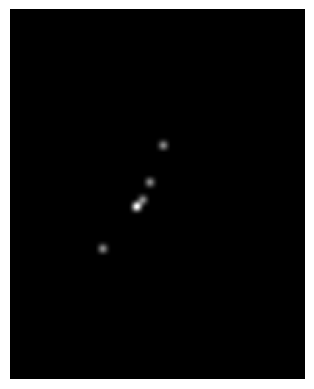

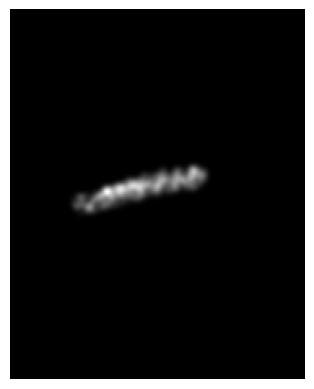

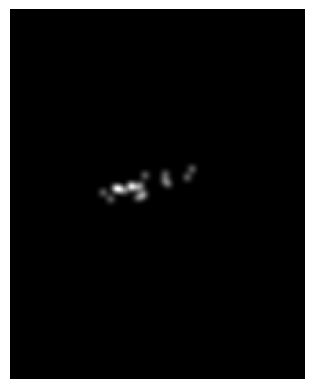

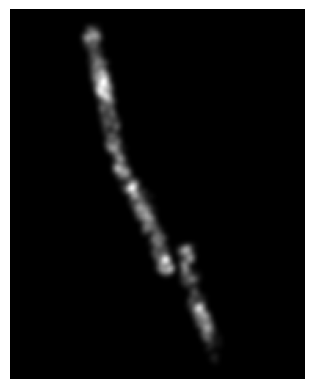

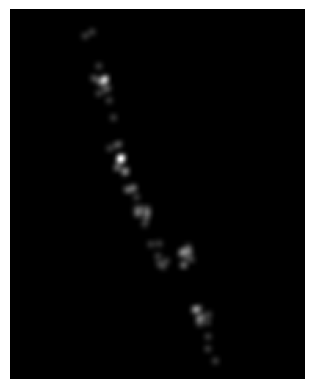

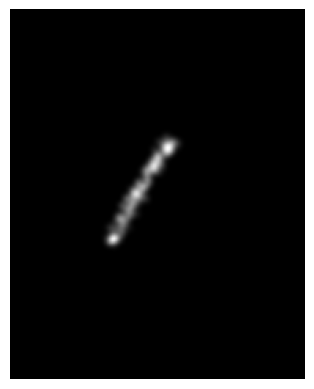

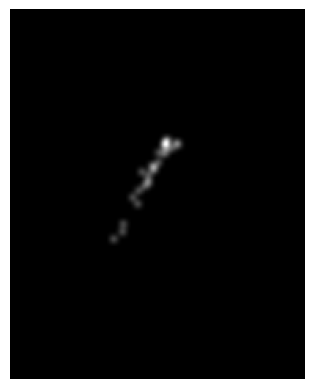

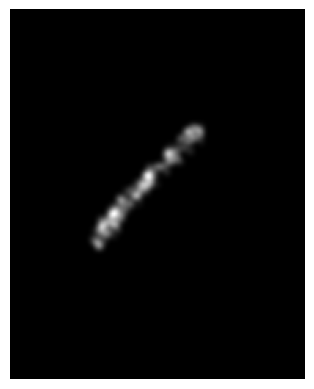

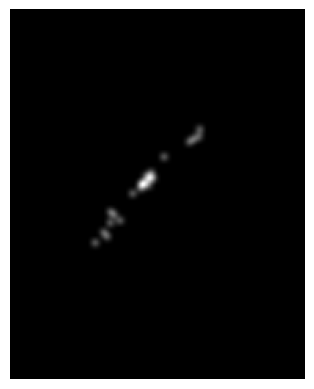

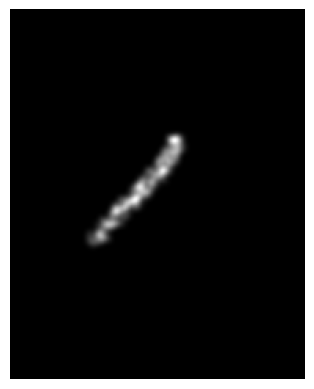

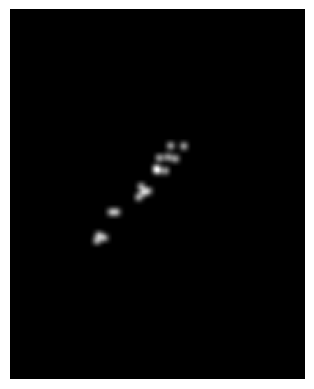

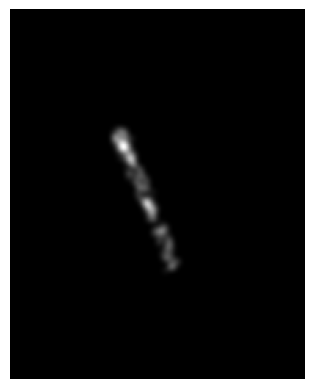

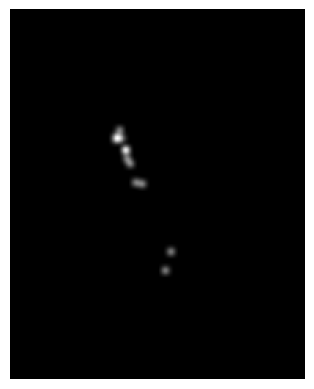

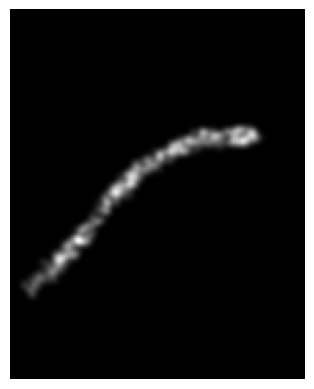

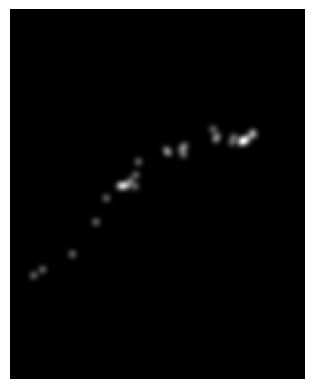

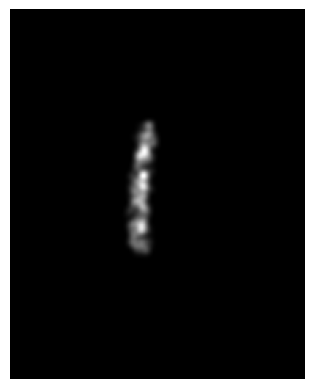

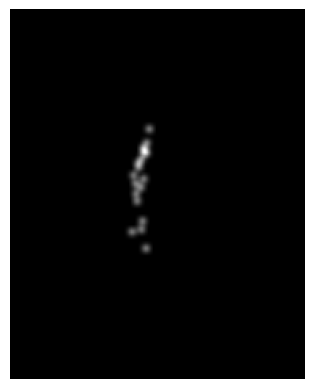

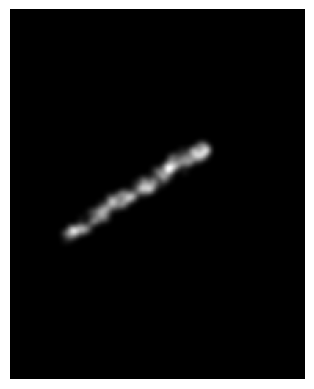

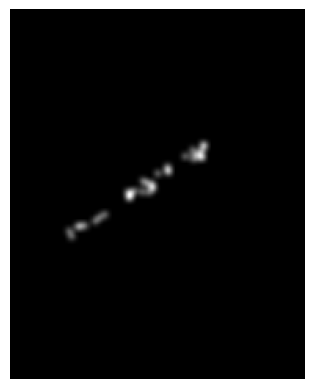

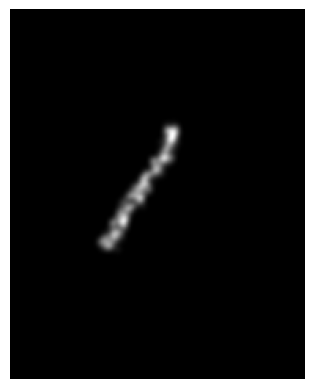

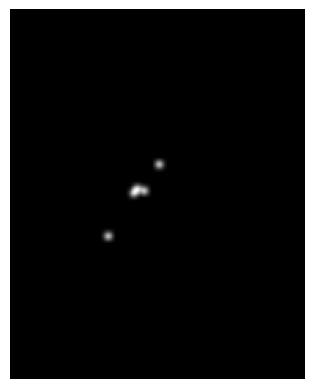

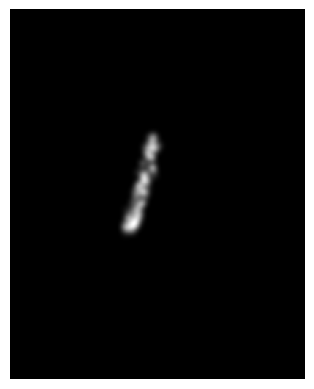

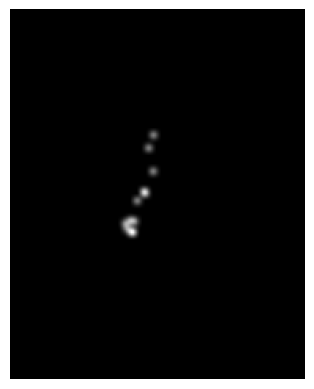

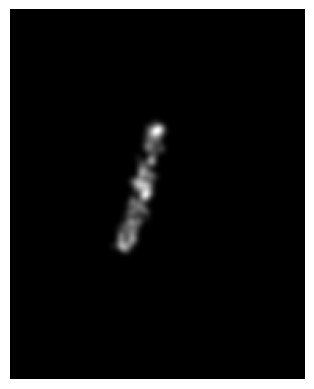

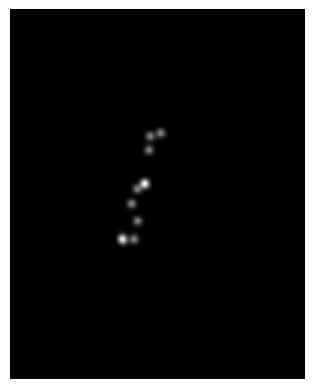

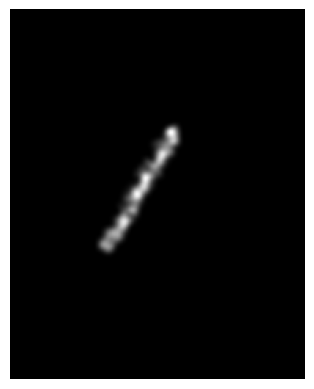

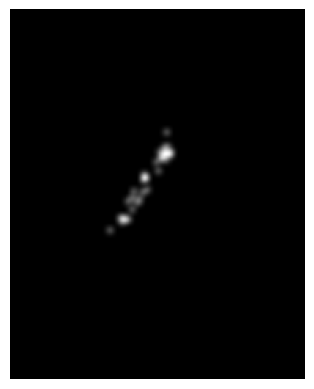

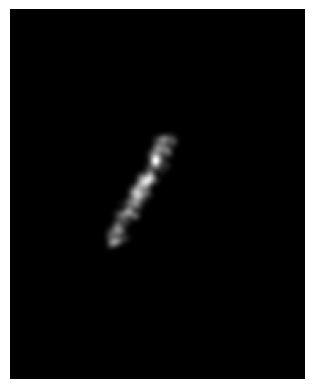

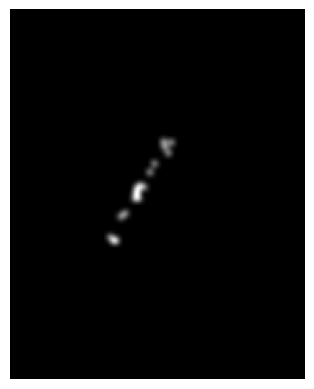

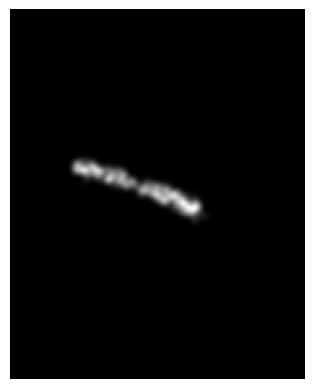

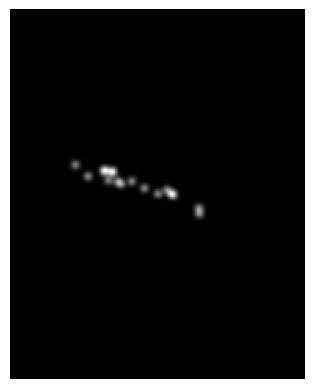

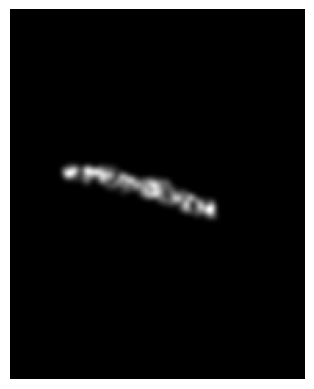

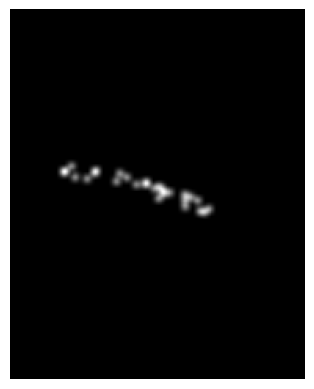

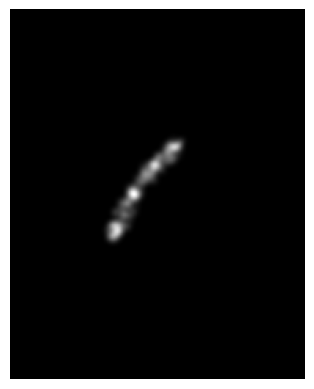

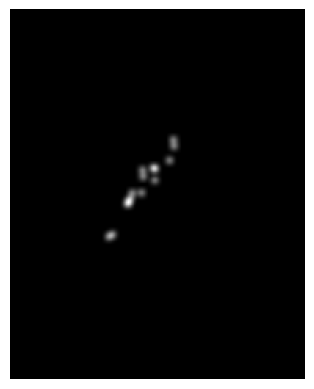

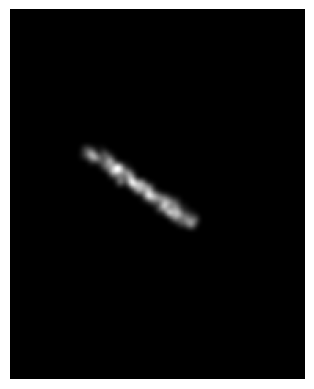

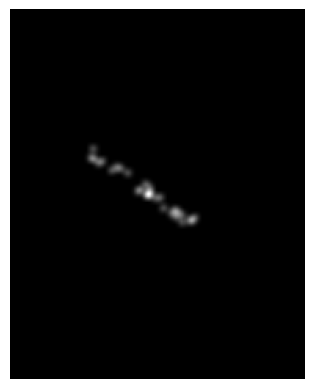

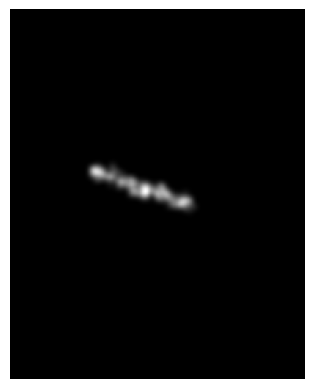

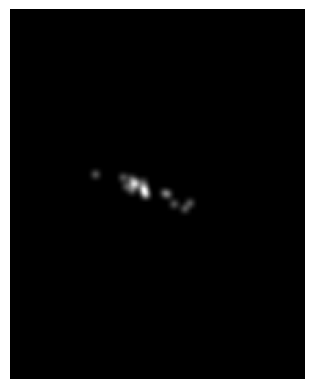

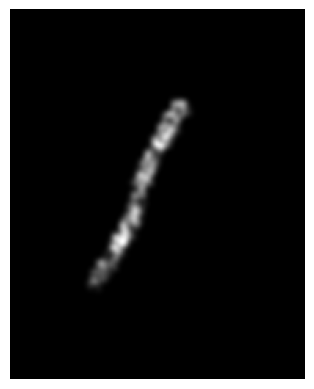

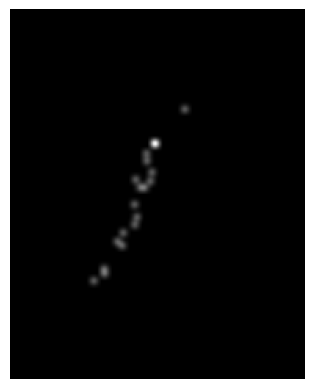

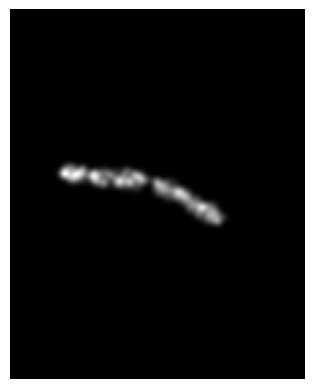

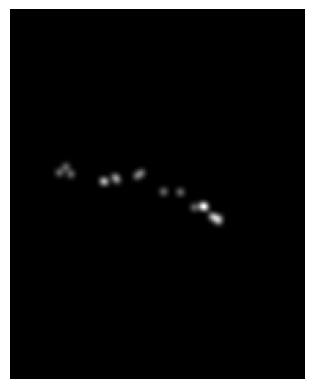

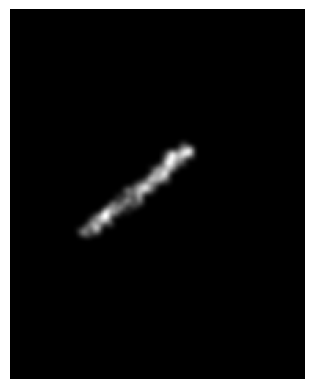

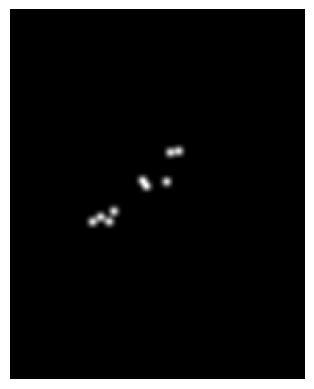

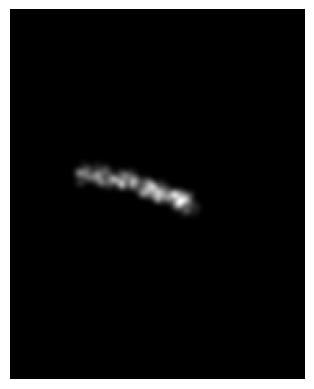

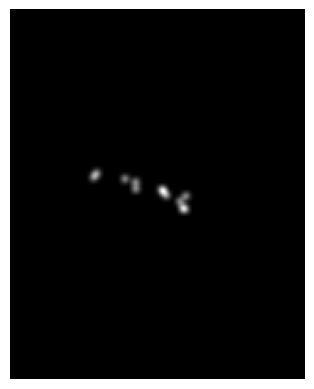

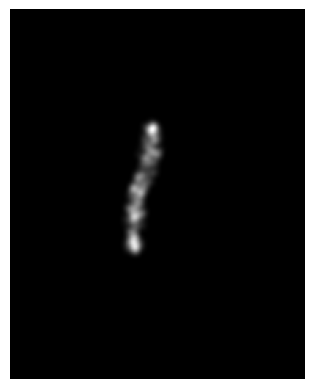

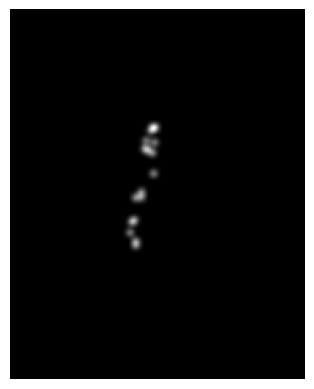

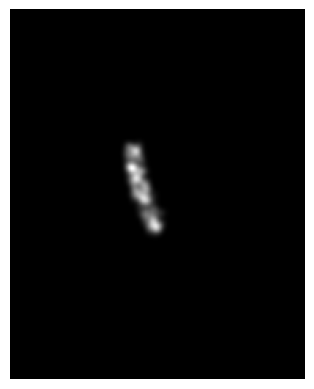

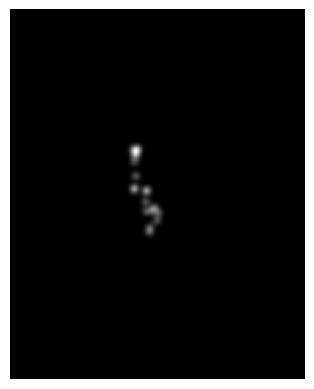

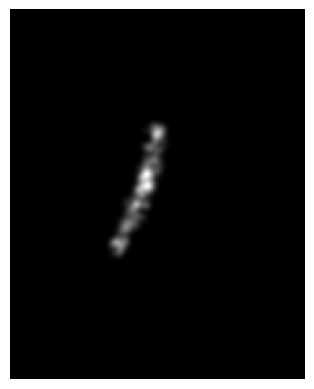

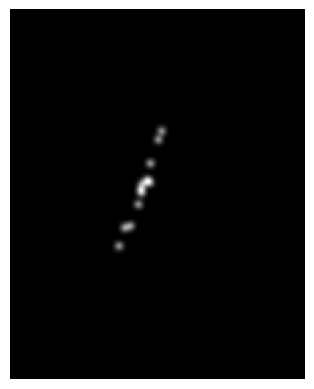

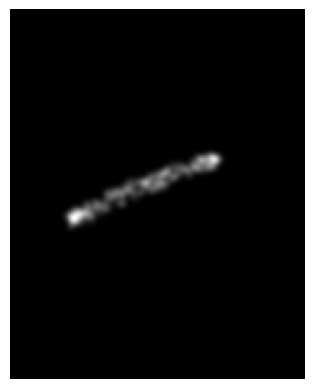

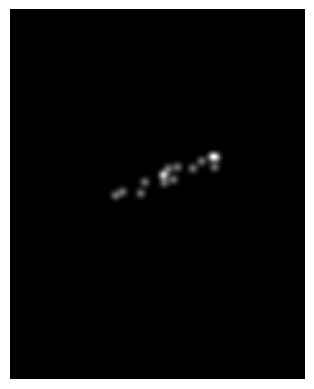

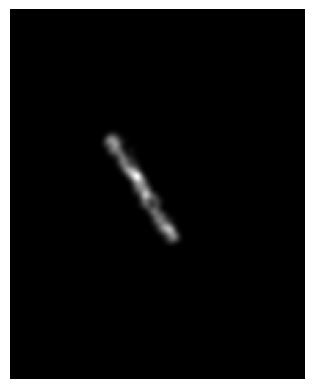

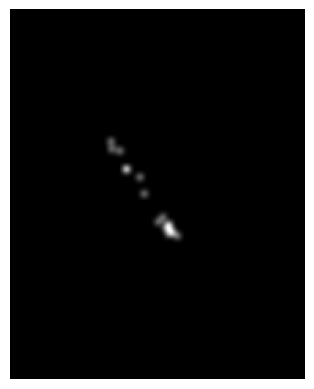

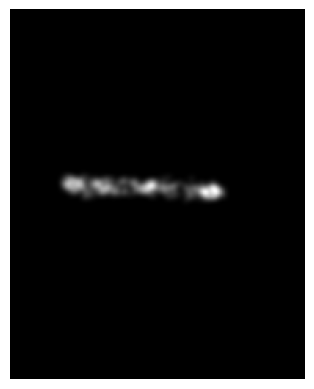

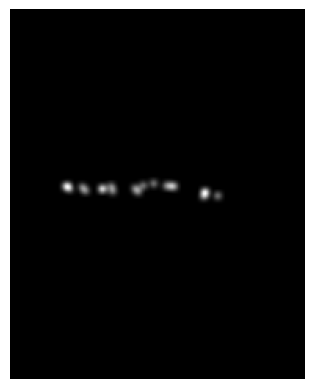

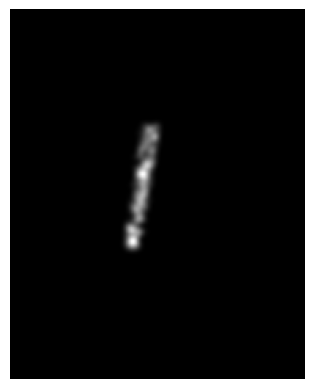

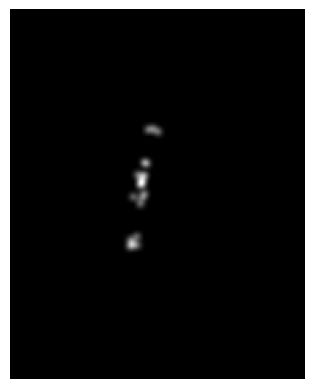

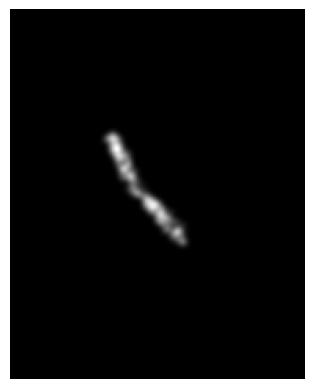

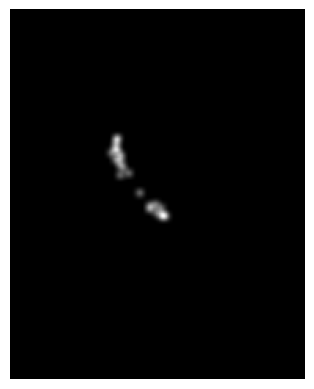

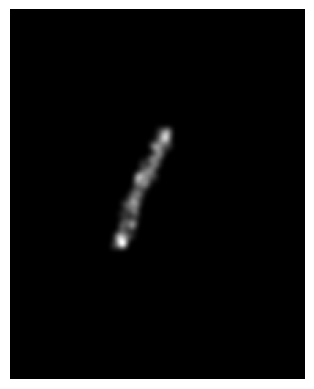

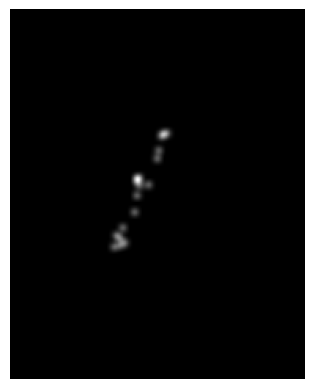

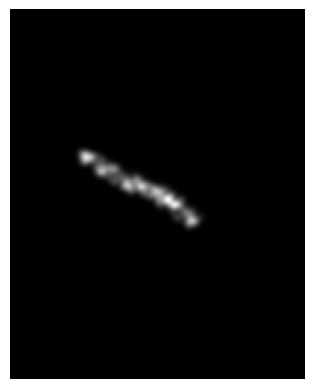

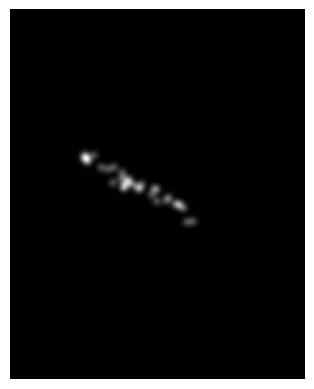

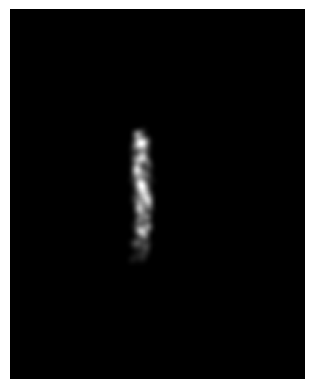

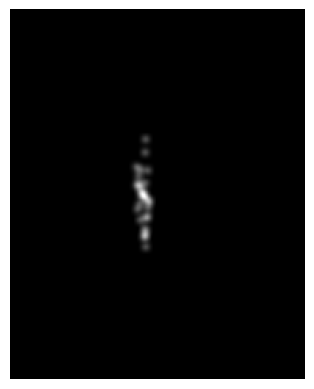

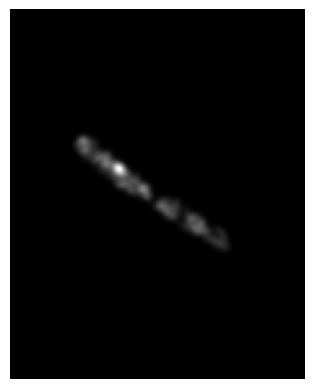

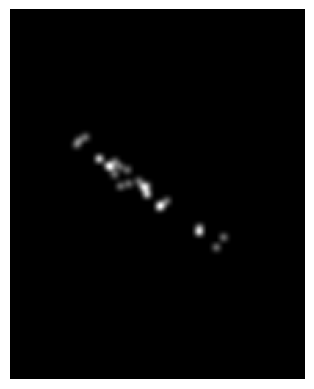

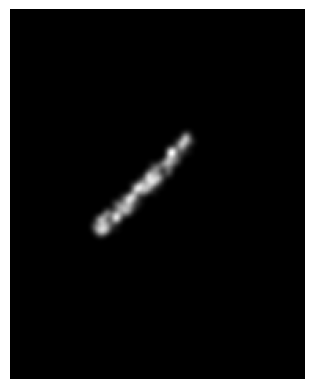

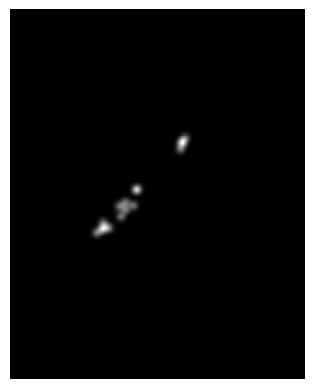

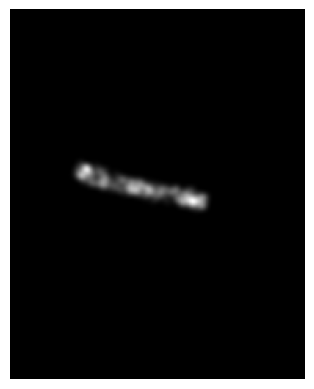

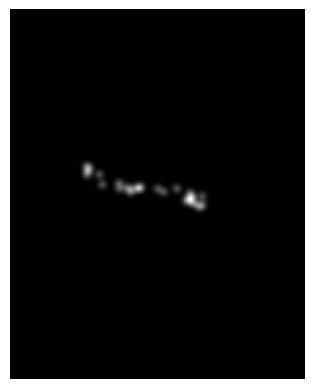

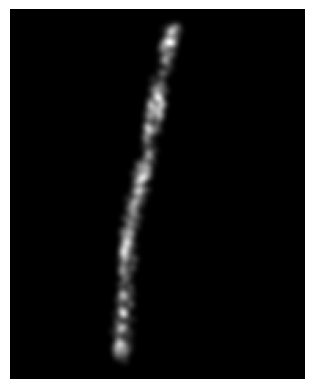

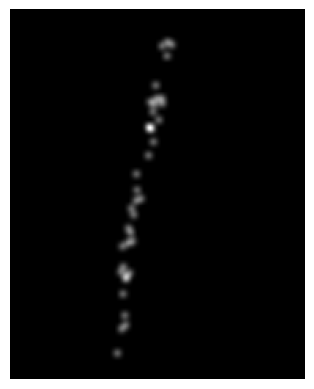

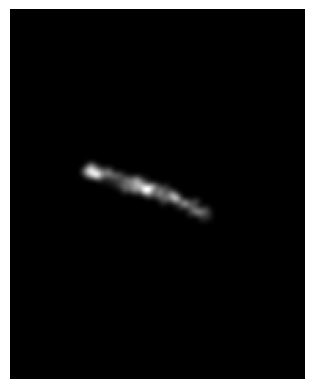

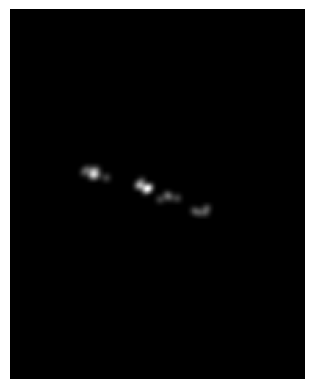

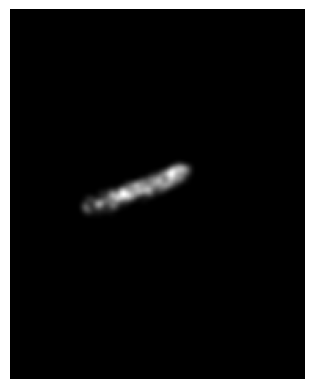

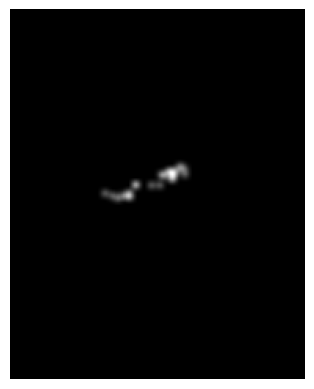

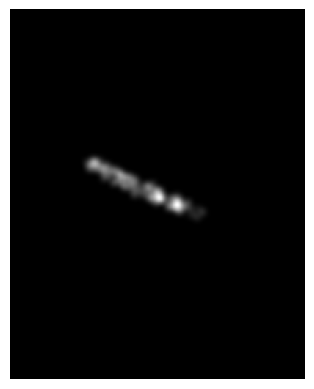

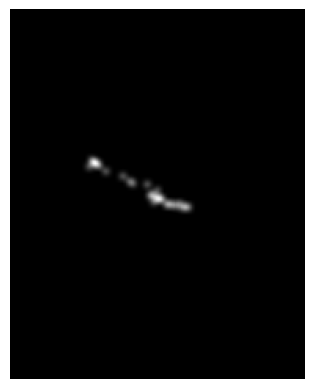

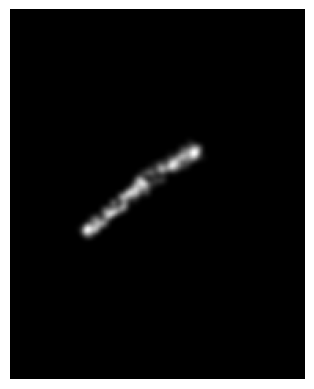

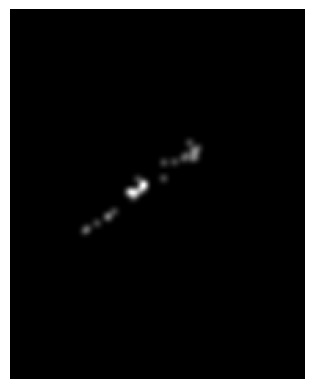

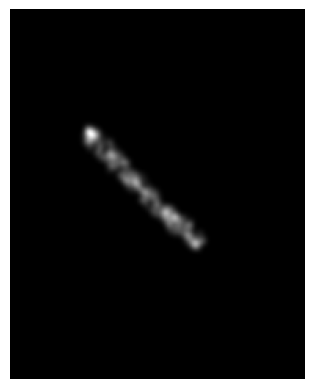

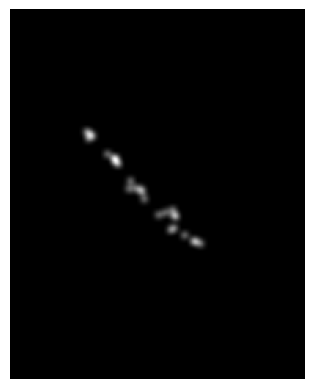

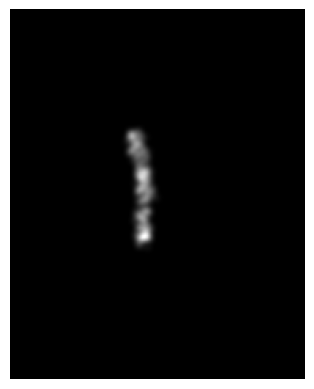

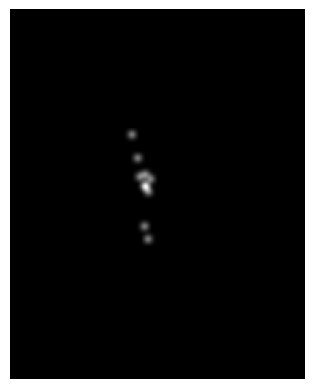

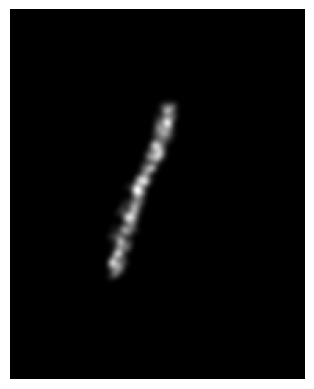

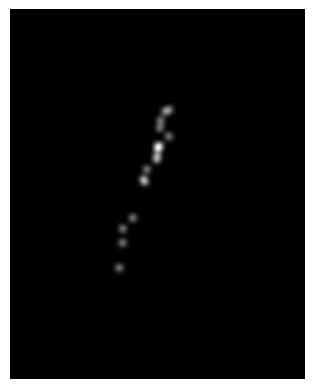

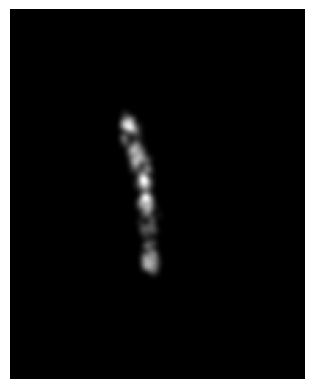

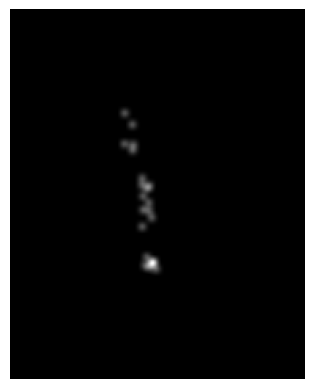

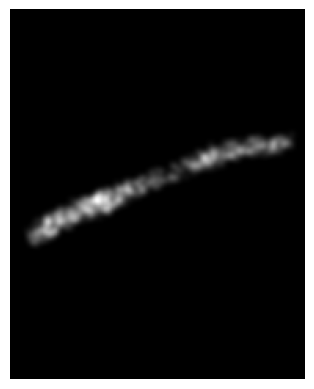

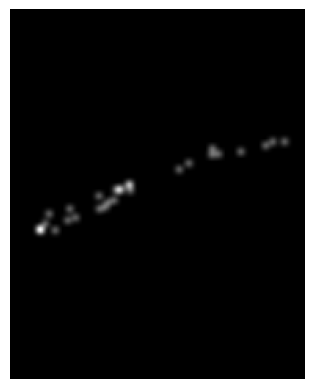

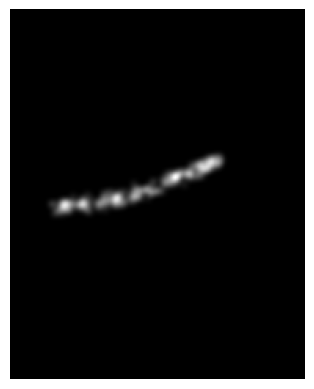

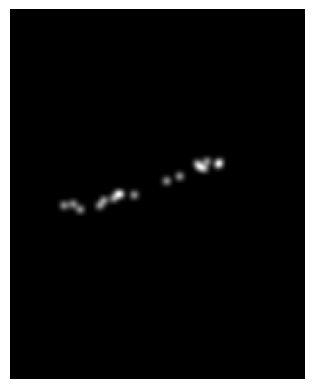

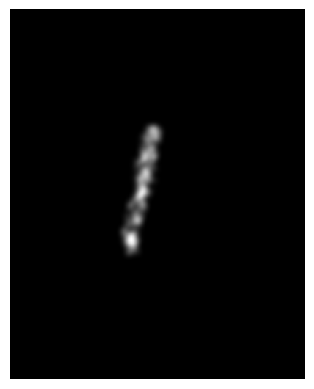

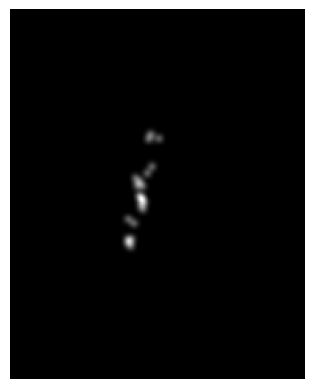

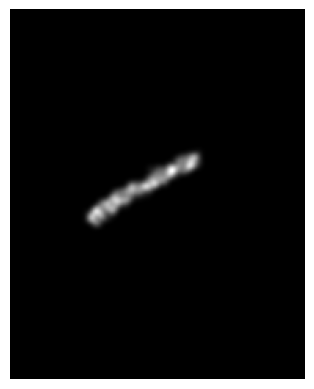

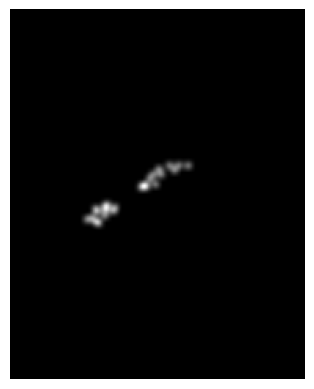

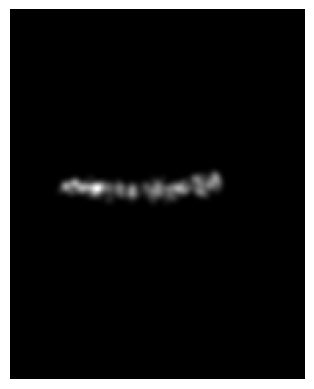

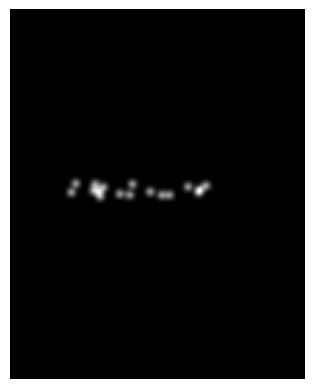

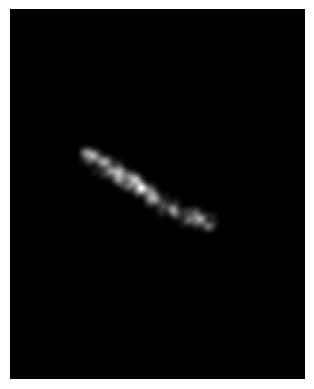

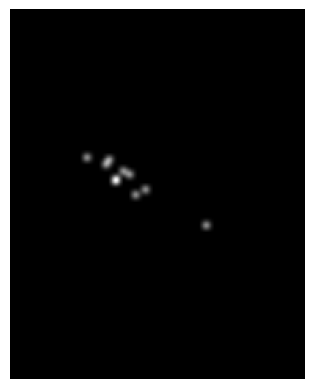

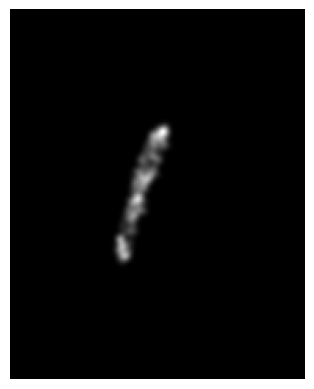

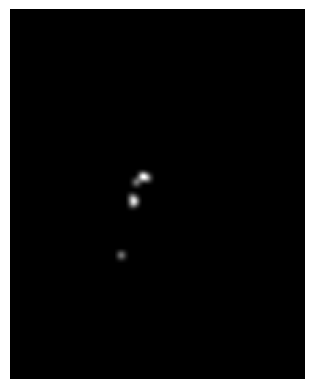

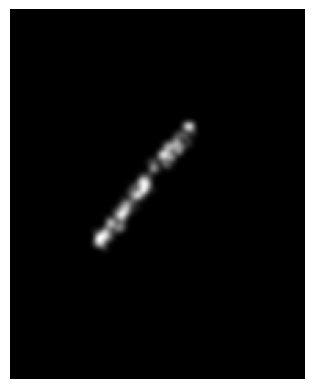

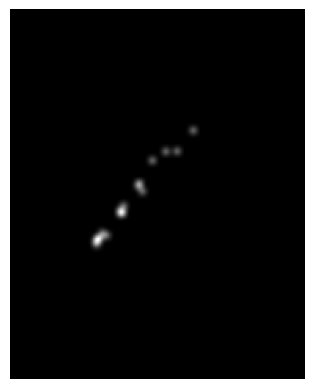

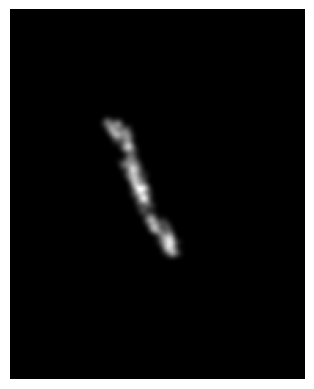

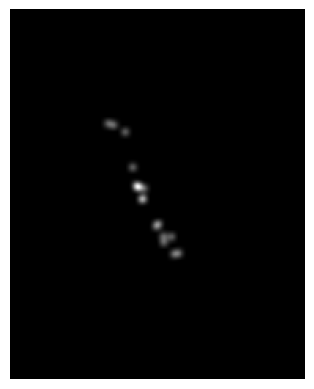

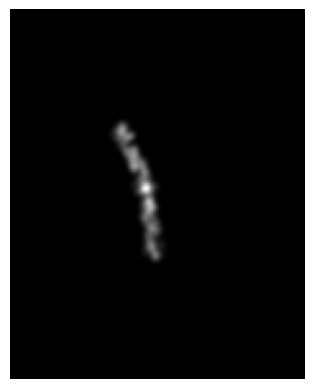

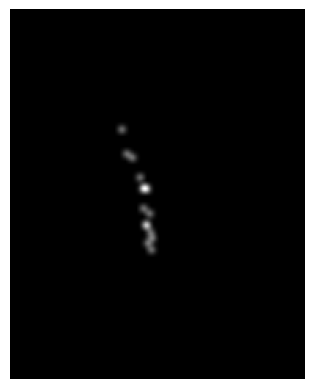

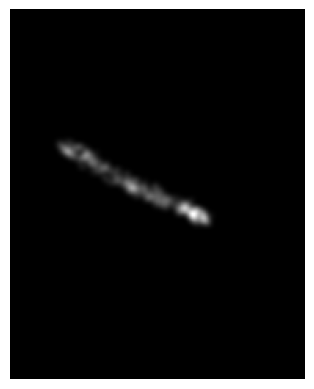

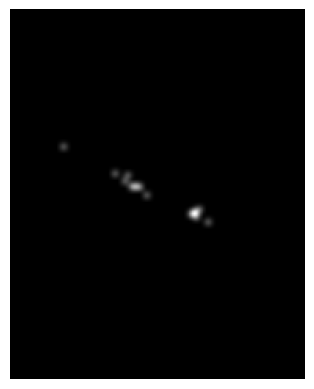

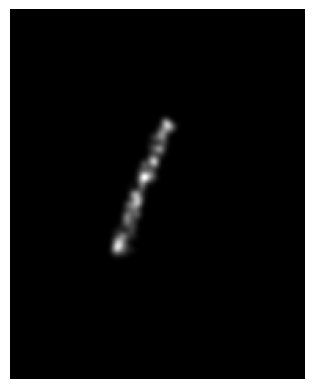

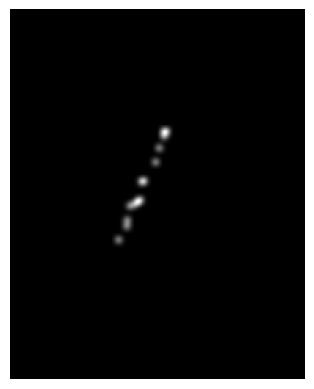

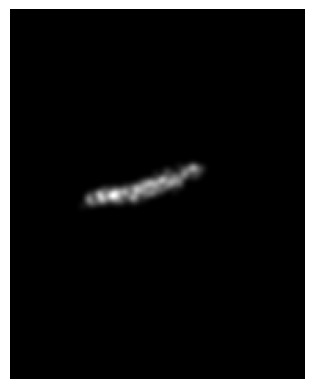

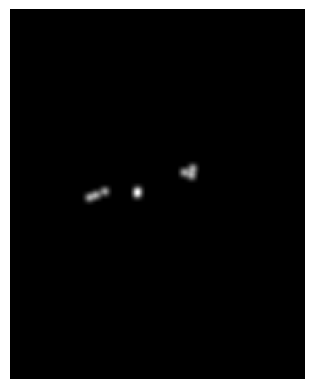

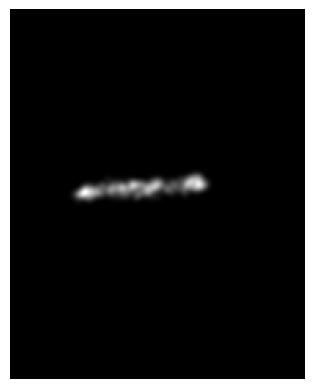

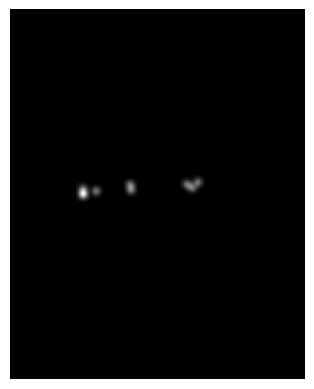

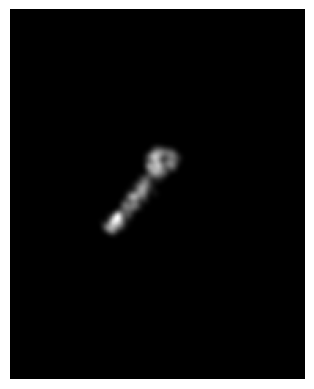

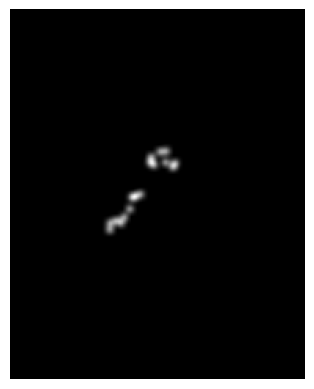

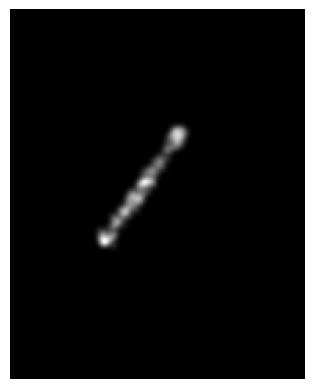

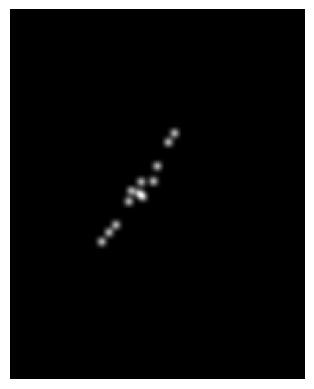

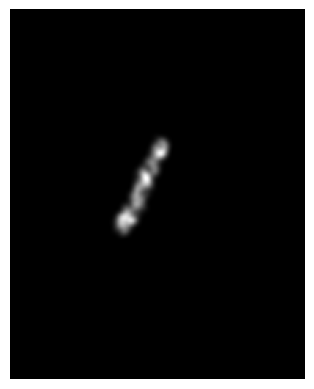

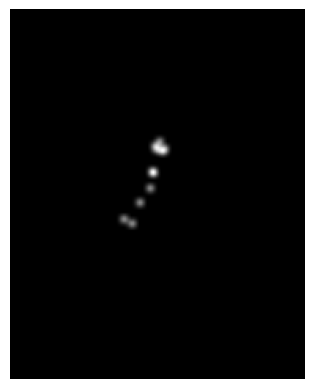

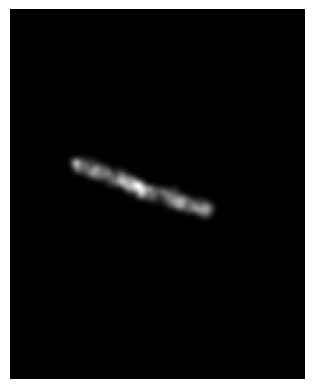

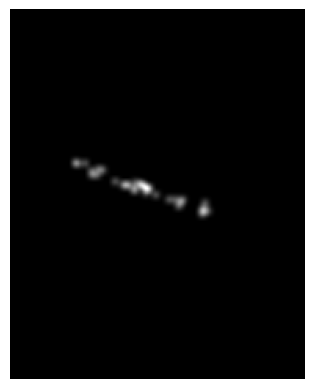

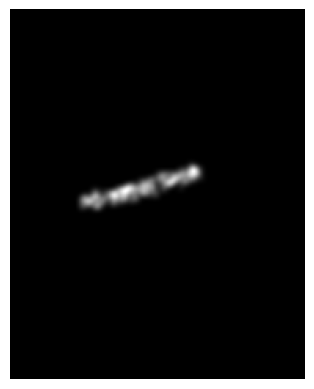

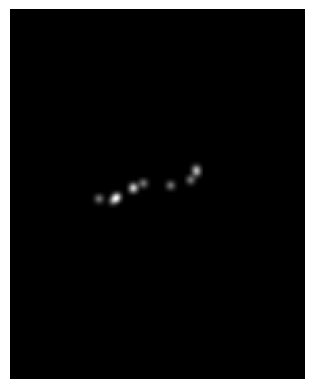

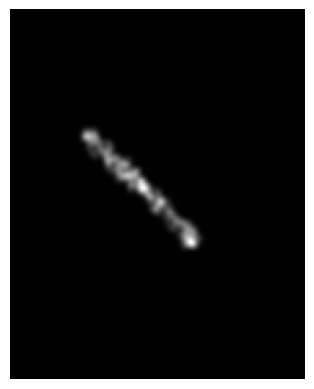

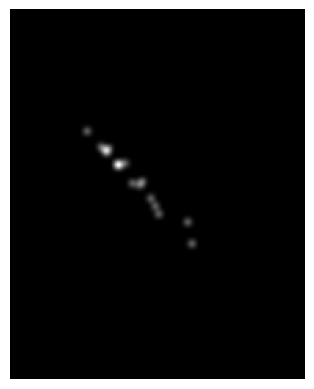

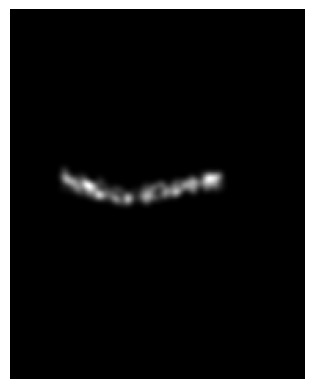

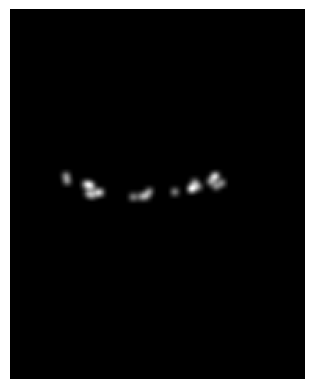

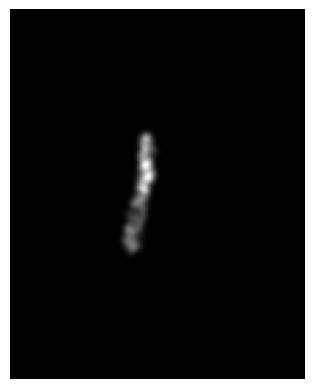

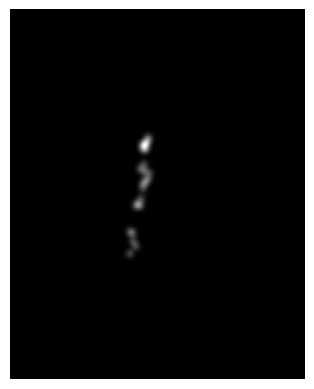

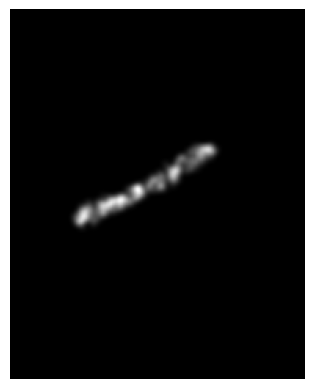

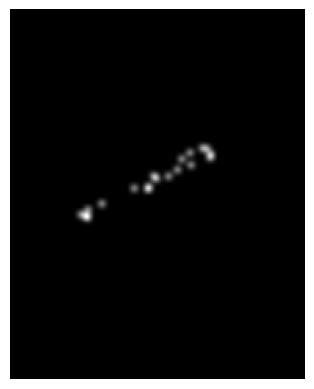

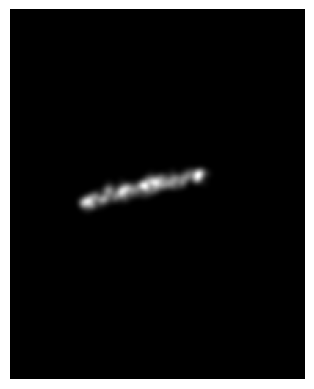

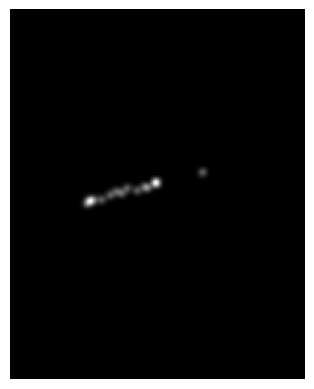

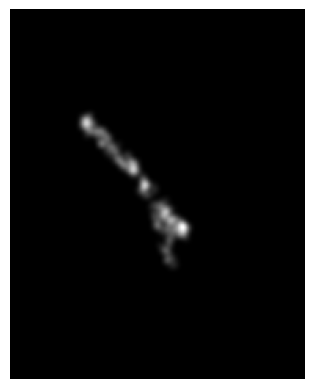

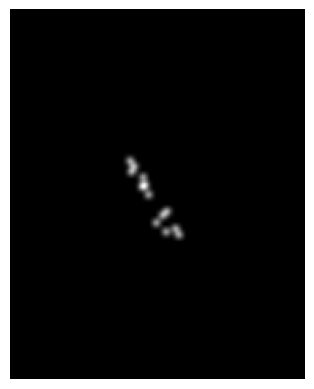

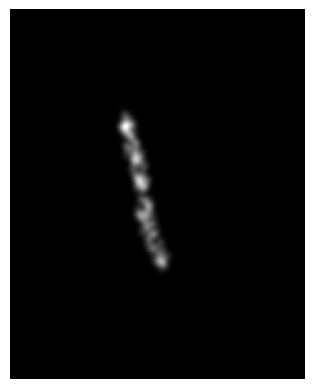

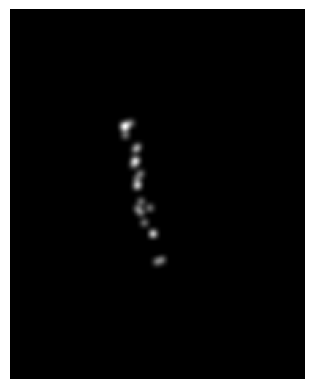

In [ ]:
## Real data generation

# Directories for input and output
input_directory = '/home/deev/t-simcne/CAP-CNN/data/MERFISH_bacteria_seg_centered/fliC-fliX' # Directory containing the cell CSV files
output_rasterized_directory = '/home/deev/t-simcne/CAP-CNN/data/MERFISH_bacteria-3/fliC-fliX' # Directory to save rasterized images
os.makedirs(output_rasterized_directory, exist_ok=True)

# Process all cells
process_all_cells(input_directory, output_rasterized_directory)